# 부산 지역 카페/음식점의 평점은 가격, 위치, 리뷰 수와 어떤 관계가 있는가?

## **연구 주제 세부화**

- 소주제 1: 가격대(저가/중가/고가)에 따라 평점에 유의한 차이가 있는가?
- 소주제 2: 리뷰 수가 많으루록 평점이 높거나 안정적인가?
- 소주제 3: 부산 내 행정구별로 평좀 분포에 차이가 있는가?
- 소주제 4: 업종(카페 vs 음식점)에 따라 평점 형성 패턴이 다른가?
- 소주제 5: 가격, 리뷰 수, 지역, 업종을 종합하면 평점을 얼마나 설명할 수 있으며, 그 한계는 무엇인가?

본 프로젝트는 부산 지역 카페와 음식점의 온라인 평점이 어떤 외부적 요인에 의해 영향을 받는지를 탐색하고 그리고 그 요인들의 설명력이 어디까지인지를 실증적으로 확인하는 것을 목적으로 한다.

이를 위해 하나의 대주제를 다섯 개의 소주제로 세분화하고 각각 서로 다른 측면에서 평점과 요인 간의 관계를 분석한다.

### 소주제 1: 가격대(저가/중가/고가)에 따라 평점에 유의한 차이가 있는가?

"비싼 곳이 맛있다!!", "음식은 가성비지~"라는 통념이 데이터로 지지되는지를 검증한다. 

Google Places API가 제공하는 가격대 등급을 저가, 중가, 고가로 범주화하여 그룹 간 평점 차이를 비모수 검정으로 분석한다.

### 소주제 2: 리뷰 수가 많을수록 평점이 높거나 안정적인가?
리뷰의 축적이 평점의 수준과 변동성에 어떤 영향을 미치는지를 분석한다. 

특히 리뷰 수가 증가할수록 평점의 분산이 감소하는지를 확인함으로써, 통계학의 대수의 법칙이 온라인 평점 데이터에서도 관찰되는지를 실증적으로 검토한다.

### 소주제 3: 부산 내 행정구별로 평점 분포에 차이가 있는가?
부산 16개 행정구군의 위치적 특성이 평점에 영향을 미치는지를 분석한다. 

특정 행정구가 맛집 천국으로 불릴 만한 통계적 근거가 있는지 아니면 부산 전체적으로 평점이 균질한지를 확인한다.

### 소주제 4: 업종(카페 vs 음식점)에 따라 평점 형성 패턴이 다른가?

카페와 음식점은 소비자가 평가하는 기준이 다를 수 있다. 

업종 간 평점 수준의 차이뿐 아니라 가격대와 리뷰 수가 평점에 미치는 영향이 업종별로 다르게 나타나는지(교호작용)를 분석한다.

### 소주제 5: 가격, 리뷰 수, 지역, 업종을 종합하면 평점을 얼마나 설명할 수 있으며, 그 한계는 무엇인가?
소주제 1~4에서 확인한 개별 요인들을 모두 투입한 다중회귀 모델을 구축하여, 이 요인들이 평점 변동의 몇 %를 설명할 수 있는지를 정량적으로 확인한다. 

설명력이 낮다면 그 자체가 "평점은 외부 관찰 가능 요인이 아닌 직접 경험적 요인에 의해 결정된다"는 의미 있는 발견이 될것이다.

## **데이터 수집**

Google Places API로 부산 16개 구 군 데이터를 수집하였다.

```python
python crawler.py
```
notebook cell에서 실행하는 것보단 `.py` 파일을 터미널에서 위의 명령어를 통해 실행하는걸 권장한다.

또한 실행 전에 `Google Places API Key`가 필요하다.


------
* **데이터 출처:** Google Places API
* **수집 URL:** https://developers.google.com/maps/documentation/places/web-service  
* **수집 날짜:** 2026-03-17  
------


In [35]:
import requests
import csv
import json
import os
import time
import re
from datetime import datetime
from typing import List, Dict, Optional

# ──────────────────────────────────────────────
# 설정
# ──────────────────────────────────────────────
OUTPUT_DIR = "output"

# 부산 행정구별 중심 좌표 (위도, 경도)
BUSAN_DISTRICT_COORDS = {
    "해운대구": (35.1631, 129.1635),
    "부산진구": (35.1631, 129.0532),
    "금정구":   (35.2437, 129.0922),
    "남구":     (35.1368, 129.0843),
    "수영구":   (35.1457, 129.1133),
    "중구":     (35.1064, 129.0324),
    "동래구":   (35.2050, 129.0858),
    "사하구":   (35.1047, 128.9748),
    "북구":     (35.1972, 129.0312),
    "사상구":   (35.1526, 128.9910),
    "연제구":   (35.1762, 129.0801),
    "영도구":   (35.0911, 129.0678),
    "강서구":   (35.1122, 128.8723),
    "동구":     (35.1295, 129.0454),
    "서구":     (35.0977, 129.0243),
    "기장군":   (35.2446, 129.2222),
}

# 검색할 장소 유형
PLACE_TYPES = {
    "음식점": ["restaurant"],
    "카페": ["cafe"],
}

# API 요청 간 딜레이 (초)
REQUEST_DELAY = 0.5


class GooglePlacesCollector:
    """Google Places API (New) 데이터 수집기"""

    def __init__(self, api_key: str):
        self.api_key = api_key
        self.crawl_date = datetime.now().strftime("%Y-%m-%d")
        self.collected_place_ids = set()
        self.all_restaurants = []
        self.request_count = 0

        os.makedirs(OUTPUT_DIR, exist_ok=True)

    # ──────────────────────────────────────────
    # Nearby Search (New)
    # ──────────────────────────────────────────
    def nearby_search(
        self,
        lat: float,
        lng: float,
        radius: float = 2000,
        place_types: List[str] = None,
        max_results: int = 20,
    ) -> List[Dict]:
        """
        좌표 기반 주변 장소 검색

        Args:
            lat, lng: 중심 좌표
            radius: 검색 반경 (미터)
            place_types: 장소 유형 (예: ["restaurant", "cafe"])
            max_results: 최대 결과 수 (1~20)
        """
        url = "https://places.googleapis.com/v1/places:searchNearby"

        # 요청할 필드 (비용 최적화)
        field_mask = ",".join([
            "places.id",
            "places.displayName",
            "places.primaryType",
            "places.primaryTypeDisplayName",
            "places.types",
            "places.rating",
            "places.userRatingCount",
            "places.priceLevel",
            "places.formattedAddress",
            "places.location",
            "places.businessStatus",
        ])

        body = {
            "maxResultCount": min(max_results, 20),
            "languageCode": "ko",
            "locationRestriction": {
                "circle": {
                    "center": {"latitude": lat, "longitude": lng},
                    "radius": radius,
                }
            },
        }

        if place_types:
            body["includedTypes"] = place_types

        headers = {
            "Content-Type": "application/json",
            "X-Goog-Api-Key": self.api_key,
            "X-Goog-FieldMask": field_mask,
        }

        try:
            resp = requests.post(url, json=body, headers=headers)
            self.request_count += 1

            if resp.status_code != 200:
                print(f"    [!] API 오류 ({resp.status_code}): {resp.text[:200]}")
                return []

            data = resp.json()
            return data.get("places", [])

        except Exception as e:
            print(f"    [!] 요청 실패: {e}")
            return []

    # ──────────────────────────────────────────
    # Text Search (New) - 키워드 기반 검색
    # ──────────────────────────────────────────
    def text_search(
        self,
        query: str,
        lat: float = None,
        lng: float = None,
        radius: float = 5000,
        max_results: int = 20,
    ) -> List[Dict]:
        """
        키워드 기반 장소 검색

        Args:
            query: 검색어 (예: "부산 해운대 맛집")
            lat, lng: 검색 중심 좌표 (선택)
            radius: 검색 반경
        """
        url = "https://places.googleapis.com/v1/places:searchText"

        field_mask = ",".join([
            "places.id",
            "places.displayName",
            "places.primaryType",
            "places.primaryTypeDisplayName",
            "places.types",
            "places.rating",
            "places.userRatingCount",
            "places.priceLevel",
            "places.formattedAddress",
            "places.location",
            "places.businessStatus",
        ])

        body = {
            "textQuery": query,
            "maxResultCount": min(max_results, 20),
            "languageCode": "ko",
        }

        if lat and lng:
            body["locationBias"] = {
                "circle": {
                    "center": {"latitude": lat, "longitude": lng},
                    "radius": radius,
                }
            }

        headers = {
            "Content-Type": "application/json",
            "X-Goog-Api-Key": self.api_key,
            "X-Goog-FieldMask": field_mask,
        }

        try:
            resp = requests.post(url, json=body, headers=headers)
            self.request_count += 1

            if resp.status_code != 200:
                print(f"    [!] API 오류 ({resp.status_code}): {resp.text[:200]}")
                return []

            data = resp.json()
            return data.get("places", [])

        except Exception as e:
            print(f"    [!] 요청 실패: {e}")
            return []

    # ──────────────────────────────────────────
    # 결과 파싱
    # ──────────────────────────────────────────
    def _parse_place(self, place: Dict, search_query: str = "") -> Optional[Dict]:
        """API 응답을 우리 데이터 형식으로 변환"""
        place_id = place.get("id", "")

        # 중복 체크
        if place_id in self.collected_place_ids:
            return None
        self.collected_place_ids.add(place_id)

        # 이름
        display_name = place.get("displayName", {})
        name = display_name.get("text", "") if isinstance(display_name, dict) else str(display_name)

        # 업종
        primary_type = place.get("primaryType", "")
        primary_type_display = place.get("primaryTypeDisplayName", {})
        category = primary_type_display.get("text", primary_type) if isinstance(primary_type_display, dict) else str(primary_type_display)

        # 평점 (1.0 ~ 5.0)
        rating = place.get("rating")

        # 리뷰 수
        review_count = place.get("userRatingCount", 0)

        # 가격대 (PRICE_LEVEL_FREE=0 ~ PRICE_LEVEL_VERY_EXPENSIVE=4)
        price_level_raw = place.get("priceLevel", "")
        price_level = self._parse_price_level(price_level_raw)

        # 주소
        address = place.get("formattedAddress", "")

        # 좌표
        location = place.get("location", {})
        lat = location.get("latitude")
        lng = location.get("longitude")

        # 영업 상태
        business_status = place.get("businessStatus", "OPERATIONAL")

        # 행정구 추출
        district = self._extract_district(address)

        # types 리스트
        types = place.get("types", [])

        # 업종 대분류
        business_type = "카페" if any(t in types for t in ["cafe", "coffee_shop"]) else "음식점"

        return {
            "place_id": place_id,
            "name": name,
            "category": category,
            "business_type": business_type,
            "rating": rating,
            "review_count": review_count,
            "price_level": price_level,
            "price_level_raw": price_level_raw,
            "address": address,
            "district": district,
            "latitude": lat,
            "longitude": lng,
            "business_status": business_status,
            "types": ",".join(types),
            "search_query": search_query,
            "crawl_date": self.crawl_date,
        }

    @staticmethod
    def _parse_price_level(raw) -> Optional[int]:
        """가격대 문자열을 숫자로 변환"""
        mapping = {
            "PRICE_LEVEL_FREE": 0,
            "PRICE_LEVEL_INEXPENSIVE": 1,
            "PRICE_LEVEL_MODERATE": 2,
            "PRICE_LEVEL_EXPENSIVE": 3,
            "PRICE_LEVEL_VERY_EXPENSIVE": 4,
        }
        if isinstance(raw, str):
            return mapping.get(raw)
        if isinstance(raw, (int, float)):
            return int(raw)
        return None

    @staticmethod
    def _extract_district(address: str) -> str:
        if not address:
            return ""
        m = re.search(r"부산\s*(광역시)?\s*(\S+[구군])", address)
        return m.group(2) if m else ""

    # ──────────────────────────────────────────
    # 수집 전략: 행정구별 격자 + Nearby Search
    # ──────────────────────────────────────────
    def collect_by_grid(
        self,
        district: str,
        center_lat: float,
        center_lng: float,
        place_types: List[str],
        type_label: str,
        radius: float = 1500,
        grid_offsets: List[tuple] = None,
    ):
        """
        한 행정구를 격자로 나눠서 Nearby Search 여러 번 호출
        → 한 번에 최대 20개만 반환하므로, 좌표를 조금씩 이동시켜 더 많이 수집
        5×5 격자 (25개 포인트) + 반경 1.5km → 행정구 대부분 커버
        """
        if grid_offsets is None:
            # 5×5 격자 (25개 포인트)
            delta = 0.012  # 약 1.2km
            offsets = [-2*delta, -delta, 0, delta, 2*delta]
            grid_offsets = [(dlat, dlng) for dlat in offsets for dlng in offsets]

        total_new = 0

        for i, (dlat, dlng) in enumerate(grid_offsets):
            search_lat = center_lat + dlat
            search_lng = center_lng + dlng

            places = self.nearby_search(
                lat=search_lat,
                lng=search_lng,
                radius=radius,
                place_types=place_types,
                max_results=20,
            )

            new_count = 0
            for place in places:
                parsed = self._parse_place(
                    place,
                    search_query=f"{district} {type_label}",
                )
                if parsed:
                    # 영업중인 곳만
                    if parsed["business_status"] == "OPERATIONAL":
                        self.all_restaurants.append(parsed)
                        new_count += 1

            total_new += new_count
            time.sleep(REQUEST_DELAY)

        return total_new

    def collect_by_text_search(
        self,
        district: str,
        center_lat: float,
        center_lng: float,
        keyword: str,
    ):
        """Text Search로 수집 (Nearby Search 보완)"""
        query = f"부산 {district} {keyword}"

        places = self.text_search(
            query=query,
            lat=center_lat,
            lng=center_lng,
            radius=5000,
            max_results=20,
        )

        new_count = 0
        for place in places:
            parsed = self._parse_place(place, search_query=query)
            if parsed and parsed["business_status"] == "OPERATIONAL":
                self.all_restaurants.append(parsed)
                new_count += 1

        time.sleep(REQUEST_DELAY)
        return new_count

    # ──────────────────────────────────────────
    # 전체 수집
    # ──────────────────────────────────────────
    def collect_all(self, districts: Dict[str, tuple] = None):
        """부산 전체 데이터 수집"""
        if districts is None:
            districts = BUSAN_DISTRICT_COORDS

        print("=" * 60)
        print("부산 카페/음식점 Google Places API 데이터 수집")
        print("=" * 60)
        print(f"대상 행정구: {len(districts)}개")
        print(f"수집 시작: {self.crawl_date}")

        total_districts = len(districts)

        for idx, (district, (lat, lng)) in enumerate(districts.items(), 1):
            print(f"\n[{idx}/{total_districts}] {district} (중심: {lat}, {lng})")

            # 1) Nearby Search: 음식점
            n1 = self.collect_by_grid(
                district, lat, lng,
                place_types=["restaurant"],
                type_label="음식점",
            )
            print(f"  음식점 (Nearby): +{n1}개")

            # 2) Nearby Search: 카페
            n2 = self.collect_by_grid(
                district, lat, lng,
                place_types=["cafe"],
                type_label="카페",
            )
            print(f"  카페 (Nearby): +{n2}개")

            # 3) Text Search 보완 (더 다양한 키워드로)
            text_new = 0
            for keyword in ["맛집", "카페", "음식점", "식당", "커피"]:
                n = self.collect_by_text_search(district, lat, lng, keyword)
                text_new += n
            print(f"  Text Search 보완: +{text_new}개")

            print(f"  → 누적: {len(self.all_restaurants)}개 (API 요청: {self.request_count}회)")

        # 저장
        self._save_results()

    # ──────────────────────────────────────────
    # 저장
    # ──────────────────────────────────────────
    def _save_results(self):
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")

        # CSV
        csv_file = os.path.join(OUTPUT_DIR, f"google_places_{ts}.csv")
        self._save_csv(self.all_restaurants, csv_file)

        # JSON
        json_file = os.path.join(OUTPUT_DIR, f"google_places_{ts}.json")
        with open(json_file, "w", encoding="utf-8") as f:
            json.dump(self.all_restaurants, f, ensure_ascii=False, indent=2)

        # 통계
        print(f"\n{'='*60}")
        print(f"수집 완료!")
        print(f"{'='*60}")
        print(f"  총 가게 수: {len(self.all_restaurants)}개")
        print(f"  고유 place_id: {len(self.collected_place_ids)}개")
        print(f"  API 요청 횟수: {self.request_count}회")

        # 기본 통계
        ratings = [r["rating"] for r in self.all_restaurants if r["rating"]]
        prices = [r["price_level"] for r in self.all_restaurants if r["price_level"] is not None]
        reviews = [r["review_count"] for r in self.all_restaurants if r["review_count"]]

        if ratings:
            print(f"  평점 있는 가게: {len(ratings)}개 (평균: {sum(ratings)/len(ratings):.2f})")
        if prices:
            print(f"  가격대 있는 가게: {len(prices)}개")
        if reviews:
            print(f"  리뷰 있는 가게: {len(reviews)}개 (평균: {sum(reviews)/len(reviews):.0f}건)")

        districts = set(r["district"] for r in self.all_restaurants if r["district"])
        print(f"  행정구: {len(districts)}개 → {', '.join(sorted(districts))}")

        print(f"\n  CSV: {csv_file}")
        print(f"  JSON: {json_file}")

    @staticmethod
    def _save_csv(data, filepath):
        if not data:
            return
        with open(filepath, "w", encoding="utf-8-sig", newline="") as f:
            w = csv.DictWriter(f, fieldnames=data[0].keys())
            w.writeheader()
            w.writerows(data)


# ──────────────────────────────────────────────
# 실행
# ──────────────────────────────────────────────
def main():
    print("=" * 60)
    print("부산 카페/음식점 Google Places API 수집기")
    print("=" * 60)

    # API 키 입력
    api_key = input("\nGoogle Places API 키를 입력하세요: ").strip()
    if not api_key:
        print("API 키가 필요합니다.")
        return

    collector = GooglePlacesCollector(api_key)

    print("\n실행 모드:")
    print("  1) 전체 수집 (16개 구·군)")
    print("  2) 특정 지역만")
    print("  3) API 테스트 (해운대구 1개만)")

    mode = input("\n선택 (1/2/3): ").strip()

    if mode == "1":
        collector.collect_all()

    elif mode == "2":
        print("\n부산 행정구:")
        districts_list = list(BUSAN_DISTRICT_COORDS.keys())
        for i, d in enumerate(districts_list, 1):
            print(f"  {i:2d}) {d}")
        sel = input("\n번호 (쉼표 구분): ").strip()
        indices = [int(x.strip()) - 1 for x in sel.split(",")]
        selected = {
            districts_list[i]: BUSAN_DISTRICT_COORDS[districts_list[i]]
            for i in indices
            if 0 <= i < len(districts_list)
        }
        print(f"\n선택: {', '.join(selected.keys())}")
        collector.collect_all(districts=selected)

    elif mode == "3":
        print("\n[API 테스트] 해운대구 음식점 20개만 검색...")
        places = collector.nearby_search(
            lat=35.1631, lng=129.1635,
            radius=2000,
            place_types=["restaurant"],
            max_results=20,
        )
        print(f"\n검색 결과: {len(places)}개")
        for i, p in enumerate(places, 1):
            name = p.get("displayName", {}).get("text", "?")
            rating = p.get("rating", "N/A")
            count = p.get("userRatingCount", 0)
            price = p.get("priceLevel", "N/A")
            addr = p.get("formattedAddress", "")[:40]
            print(f"  {i:2d}. {name} ★{rating} ({count}건) 가격:{price} | {addr}")

        print(f"\nAPI 요청 횟수: {collector.request_count}회")
        print("테스트 성공! 전체 수집은 모드 1로 실행하세요.")

    else:
        print("잘못된 입력")


if __name__ == "__main__":
    main()

부산 카페/음식점 Google Places API 수집기
API 키가 필요합니다.


## Part 1: 데이터 로드, 전처리, 탐색적 자료분석(EDA)

---

## 0. 환경 설정

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [37]:
# Windows: "Malgun Gothic"
# Mac: "AppleGothic"  
plt.rcParams["font.family"] = "AppleGothic" 
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

# 시각화 스타일
sns.set_style("whitegrid")
sns.set_palette("Set2")

print("시각화 환경 설정 완료!")

시각화 환경 설정 완료!


----

## 1. 데이터 로드

Google Places API를 통해 부산 16개 행정구의 음식점과 카페 데이터를 수집하였다.

API에서 제공하는 필드 중 평점(rating), 리뷰 수(review_count), 가격대(price_level), 업종(business_type), 주소(address) 등을 활용한다.

In [38]:
# 원본 데이터 load
df_raw = pd.read_csv("/Users/sanghyun/Desktop/code_attic/output/google_places_20260317_090717.csv") 

# 원본 데이터 size 출력
print(f"Size of Raw Data: {df_raw.shape[0]}행 x {df_raw.shape[1]}열")

# 데이터의 컬럼명과 그 타입
print(f"\nList of Columns:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:2d}. {col:<20s} (dtype: {df_raw[col].dtype})")

Size of Raw Data: 5385행 x 16열

List of Columns:
   1. place_id             (dtype: str)
   2. name                 (dtype: str)
   3. category             (dtype: str)
   4. business_type        (dtype: str)
   5. rating               (dtype: float64)
   6. review_count         (dtype: int64)
   7. price_level          (dtype: float64)
   8. price_level_raw      (dtype: str)
   9. address              (dtype: str)
  10. district             (dtype: str)
  11. latitude             (dtype: float64)
  12. longitude            (dtype: float64)
  13. business_status      (dtype: str)
  14. types                (dtype: str)
  15. search_query         (dtype: str)
  16. crawl_date           (dtype: str)


In [39]:
# top5 row print
df_raw.head(10)

,place_id,name,category,business_type,rating,review_count,price_level,price_level_raw,address,district,latitude,longitude,business_status,types,search_query,crawl_date
0,ChIJ32cgnbWSaDURRBmyaEdLiJs,수변최고돼지국밥 본점,한식당,음식점,4.4,2226,2.0,PRICE_LEVEL_MODERATE,대한민국 부산광역시 수영구 광안해변로370번길 9-32,수영구,35.156763,129.134279,OPERATIONAL,"korean_restaurant,restaurant,food,point_of_int...",해운대구 음식점,2026-03-17
1,ChIJZ74eNBLtaDUR-IqtSdDWWK4,톤쇼우 광안점,돈까스 전문식당,음식점,4.6,897,NaN,NaN,대한민국 부산광역시 수영구 광안해변로279번길 13,수영구,35.156441,129.124800,OPERATIONAL,"tonkatsu_restaurant,japanese_restaurant,restau...",해운대구 음식점,2026-03-17
2,ChIJZVGACAmTaDURV1JjJbb5hm4,83해치 광안리점,숯불구이/바베큐전문점,음식점,4.6,134,2.0,PRICE_LEVEL_MODERATE,대한민국 부산광역시 수영구 민락본동로19번길 59,수영구,35.157560,129.125811,OPERATIONAL,"barbecue_restaurant,restaurant,food,point_of_i...",해운대구 음식점,2026-03-17
3,ChIJT81C6c-SaDURtoMl6Ub3ITs,베지나랑 2호점,비건 채식 레스토랑,음식점,4.5,372,2.0,PRICE_LEVEL_MODERATE,"노블스카이, 9층, 9-32 광안해변로370번길 수영구 부산광역시 대한민국",NaN,35.156747,129.134269,OPERATIONAL,"vegan_restaurant,vegetarian_restaurant,restaur...",해운대구 음식점,2026-03-17
4,ChIJ4xbjTwOTaDURsbcaWcyeZzo,거대곰탕,한식당,음식점,4.5,447,3.0,PRICE_LEVEL_EXPENSIVE,대한민국 부산광역시 해운대구 해운대해변로 163,해운대구,35.158186,129.150533,OPERATIONAL,"korean_restaurant,restaurant,food,point_of_int...",해운대구 음식점,2026-03-17
5,ChIJq7z70p-TaDUReBDEZGF0gYU,장덕풍천장어 광안본점 Gwangalli Restaurant 광안리 맛집 釜山美食 広...,일본 음식점,음식점,4.6,573,NaN,NaN,대한민국 부산광역시 수영구 민락동 민락수변로 147 장덕풍천장어 광안본점 1층,수영구,35.156819,129.134493,OPERATIONAL,"barbecue_restaurant,korean_restaurant,japanese...",해운대구 음식점,2026-03-17
6,ChIJs1LIVmGTaDUR04qBDgC1G3E,타케리아 뺀데호,멕시코 음식점,음식점,4.8,347,NaN,NaN,대한민국 부산광역시 수영구 민락본동로19번길 68,수영구,35.157652,129.125202,OPERATIONAL,"mexican_restaurant,restaurant,food,point_of_in...",해운대구 음식점,2026-03-17
7,ChIJLa1vfTTtaDURmV1ZuPHc-3I,민락어민활어직판장,시장,음식점,4.2,3882,NaN,NaN,대한민국 부산광역시 수영구 광안해변로312번길 60,수영구,35.154220,129.127885,OPERATIONAL,"market,restaurant,food,point_of_interest,estab...",해운대구 음식점,2026-03-17
8,ChIJfd-4PbKSaDUR8xjfXgzEZRQ,풍원장 꼬막정찬,한식당,음식점,4.2,1662,2.0,PRICE_LEVEL_MODERATE,대한민국 부산광역시 해운대구 마린시티2로 38,해운대구,35.154990,129.142555,OPERATIONAL,"korean_restaurant,restaurant,food,point_of_int...",해운대구 음식점,2026-03-17
9,ChIJcVUxmZ-TaDURc2gXKoaOnOE,이태리상점,이탈리아 음식점,음식점,4.7,134,NaN,NaN,대한민국 부산광역시 해운대구 동백로 29,해운대구,35.158934,129.151692,OPERATIONAL,"italian_restaurant,restaurant,food,point_of_in...",해운대구 음식점,2026-03-17


----

## 2. 전처리

### 2.1 분석 대상 선정 기준

본 연구에서는 `**가격대(price_level)**` 정보가 존재하는 가게만을 분석 대상으로 선정하였다.

그 이유는 다음과 같다.

1. 가격은 본 연구의 핵심 독립변수 중 하나이므로, 가격 정보가 없으면 소주제 1(가격대별 평점)과 소주제5 (통합 모델)에서 해당 관측를 활용할 수 없다.

2. 분석 전체에서 동일한 데이터셋을 사용함으로써 소주제 간 일관성을 확보한다.

또한 부산광역시의 공식 16개 행정구군에 해당하지 않는 관측치는 제외하였다.

In [40]:
# 부산 16개 행정구·군
valid_districts = [
    "해운대구", "부산진구", "금정구", "남구", "수영구",
    "중구", "동래구", "사하구", "북구", "사상구",
    "연제구", "영도구", "강서구", "동구", "서구", "기장군"
]

In [41]:
# 조건: (1) price_level 존재 (2) rating 존재 (3) 유효 행정구
df = df_raw[
    df_raw["price_level"].notna() &
    df_raw["rating"].notna() &
    df_raw["district"].isin(valid_districts)
].copy()
 
print(f"Filtering Results:")
print(f"  Raw data: {len(df_raw)}개")
print(f"  -> price_level o + rating o + 유효 행정구: {len(df)}개")
print(f"  removed raws: {len(df_raw) - len(df)}개")

Filtering Results:
  Raw data: 5385개
  -> price_level o + rating o + 유효 행정구: 1365개
  removed raws: 4020개


### 2.2 변수 확인 및 정리

In [42]:
# 결측치 확인
print("Missing Data After Filtering")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "  -> 주요 분석 변수에 결측치 없음!!")

Missing Data After Filtering
  -> 주요 분석 변수에 결측치 없음!!


In [43]:
print(f"\n각 변수별 유효 데이터 수:")
print(f"  rating:       {df['rating'].notna().sum()}")
print(f"  review_count: {df['review_count'].notna().sum()}")
print(f"  price_level:  {df['price_level'].notna().sum()}")
print(f"  district:     {df['district'].notna().sum()}")
print(f"  business_type:{df['business_type'].notna().sum()}")


각 변수별 유효 데이터 수:
  rating:       1365
  review_count: 1365
  price_level:  1365
  district:     1365
  business_type:1365


### 2.3 변수 변환이 필요한 이유 탐색

변수를 변환하기 전에 현재 데이터가 어떤 상태인지 먼저 시각적으로 확인한다.

----

#### 2.3-1a. Price_level 분포

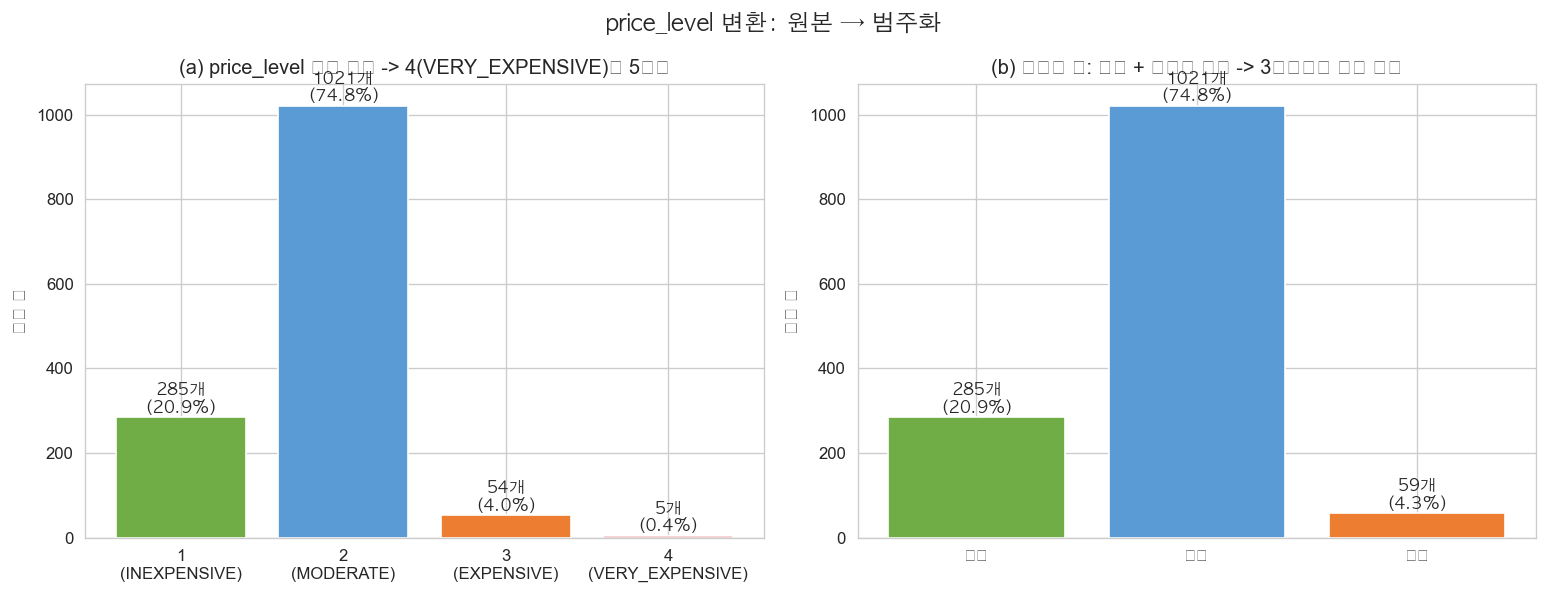

결정: VERY_EXPENSIVE(4)가 5개뿐이므로 EXPENSIVE(3)와 합쳐 '고가'로 범주화
  저가 (1): 285개
  중가 (2): 1021개
  고가 (3+4): 59개


In [44]:
# ── 2.3-1 price_level 원본 상태 확인 ──
# "왜 범주화가 필요한가?"를 데이터로 보여주기

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plt.rcParams["font.family"] = "AppleGothic" 

# (좌) price_level 원본 분포 — 문제점이 보인다
price_raw_counts = df["price_level"].value_counts().sort_index()
labels_raw = {1.0: "1\n(INEXPENSIVE)", 2.0: "2\n(MODERATE)", 3.0: "3\n(EXPENSIVE)", 4.0: "4\n(VERY_EXPENSIVE)"}
colors_raw = ["#70AD47", "#5B9BD5", "#ED7D31", "#C00000"]
bars = axes[0].bar([labels_raw[k] for k in price_raw_counts.index], price_raw_counts.values, color=colors_raw, edgecolor="white")
for bar, val in zip(bars, price_raw_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 10, f"{val}개\n({val/len(df)*100:.1f}%)", ha="center", fontsize=10, fontweight="bold")
    axes[0].set_ylabel("가게 수", fontsize=11) 
    axes[0].set_title("(a) price_level 원본 분포 -> 4(VERY_EXPENSIVE)가 5개뿐", fontsize=12)
plt.rcParams["font.family"] = "AppleGothic" 
# (우) 범주화 후 — 고가(3) + 최고가(4)를 합침
# 먼저 범주화 수행
def categorize_price(level):
    if level == 1:
        return "저가"
    elif level == 2:
        return "중가"
    else:  # 3, 4
        return "고가"
plt.rcParams["font.family"] = "AppleGothic" 
df["price_category"] = df["price_level"].apply(categorize_price)
price_cat_counts = df["price_category"].value_counts().reindex(["저가", "중가", "고가"])
colors_cat = ["#70AD47", "#5B9BD5", "#ED7D31"]
bars = axes[1].bar(price_cat_counts.index, price_cat_counts.values, color=colors_cat, edgecolor="white")
for bar, val in zip(bars, price_cat_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 10, f"{val}개\n({val/len(df)*100:.1f}%)", 
                 ha="center", fontsize=10, fontweight="bold")
axes[1].set_ylabel("가게 수", fontsize=11)
axes[1].set_title("(b) 범주화 후: 고가 + 최고가 합침 -> 3그룹으로 비교 가능", fontsize=12)
 
plt.suptitle("price_level 변환: 원본 → 범주화", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.rcParams["font.family"] = "AppleGothic" 
plt.show()
 
print("결정: VERY_EXPENSIVE(4)가 5개뿐이므로 EXPENSIVE(3)와 합쳐 '고가'로 범주화")
print(f"  저가 (1): {(df['price_category']=='저가').sum()}개")
print(f"  중가 (2): {(df['price_category']=='중가').sum()}개")
print(f"  고가 (3+4): {(df['price_category']=='고가').sum()}개")


#### 2.3-1b. Class Imbalance 수치 비교

Class Imbalance 비교 (합치기 전 vs 후)
─────────────────────────────────────────────────────────────────
지표                             합치기 전(4cls)        합친 후(3cls)     
─────────────────────────────────────────────────────────────────
클래스 수                          4                  3              
최소 클래스 크기                      5                  59             
최대/최소 비율 (IR)                  204.2              17.3           
Balance Ratio (0~1)            0.4996             0.6190         
─────────────────────────────────────────────────────────────────
  IR: 204:1 -> 17:1 (개선)
  Balance Ratio: 0.500 -> 0.619 (개선)


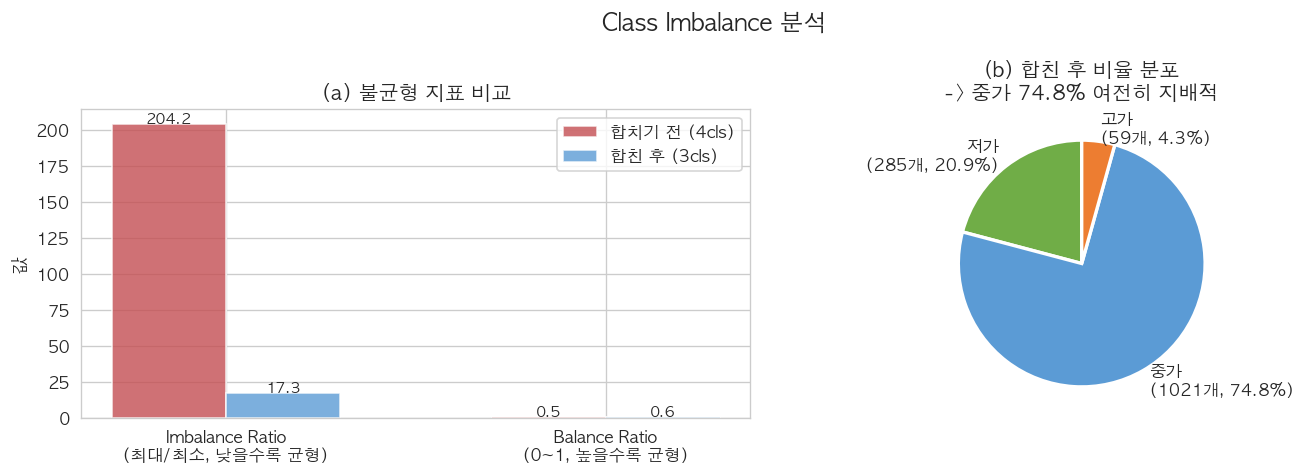


※ 합친 후에도 중가(74.8%)가 지배적인 class imbalance가 존재함
  -> 소주제 1 분석 시 비모수 검정(Kruskal-Wallis) 사용 및 해석에 주의 필요

결정: VERY_EXPENSIVE(4)가 5개뿐이므로 EXPENSIVE(3)와 합쳐 '고가'로 범주화
  저가 (1): 285개
  중가 (2): 1021개
  고가 (3+4): 59개


In [45]:
# 합치기 전후로 클래스 불균형이 얼마나 개선되었는지 정량적으로 확인
 
n = len(df)
 
# 합치기 전 (4 클래스)
before_counts = df["price_level"].value_counts().sort_index()
props_before = before_counts / n
ir_before = before_counts.max() / before_counts.min()  # Imbalance Ratio
entropy_before = -np.sum(props_before * np.log(props_before))
balance_before = entropy_before / np.log(len(before_counts))  # 1이면 완전 균형
 
# 합친 후 (3 클래스)
after_counts = df["price_category"].value_counts().reindex(["저가", "중가", "고가"])
props_after = after_counts / n
ir_after = after_counts.max() / after_counts.min()
entropy_after = -np.sum(props_after * np.log(props_after))
balance_after = entropy_after / np.log(len(after_counts))
 
# 비교 테이블
print("Class Imbalance 비교 (합치기 전 vs 후)")
print(f"{'─'*65}")
print(f"{'지표':<30} {'합치기 전(4cls)':<18} {'합친 후(3cls)':<15}")
print(f"{'─'*65}")
print(f"{'클래스 수':<30} {len(before_counts):<18} {len(after_counts):<15}")
print(f"{'최소 클래스 크기':<30} {before_counts.min():<18} {after_counts.min():<15}")
print(f"{'최대/최소 비율 (IR)':<30} {ir_before:<18.1f} {ir_after:<15.1f}")
print(f"{'Balance Ratio (0~1)':<30} {balance_before:<18.4f} {balance_after:<15.4f}")
print(f"{'─'*65}")
print(f"  IR: {ir_before:.0f}:1 -> {ir_after:.0f}:1 (개선)")
print(f"  Balance Ratio: {balance_before:.3f} -> {balance_after:.3f} (개선)")
 
# 시각화: 비교 막대그래프
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plt.rcParams["font.family"] = "AppleGothic" 
 
metrics = ["Imbalance Ratio\n(최대/최소, 낮을수록 균형)", "Balance Ratio\n(0~1, 높을수록 균형)"]
before_vals = [ir_before, balance_before]
after_vals = [ir_after, balance_after]
 
x = np.arange(len(metrics))
w = 0.3
bars1 = axes[0].bar(x - w/2, before_vals, w, label="합치기 전 (4cls)", color="#C44E52", alpha=0.8)
bars2 = axes[0].bar(x + w/2, after_vals, w, label="합친 후 (3cls)", color="#5B9BD5", alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, fontsize=10)
axes[0].set_ylabel("값", fontsize=11)
axes[0].set_title("(a) 불균형 지표 비교", fontsize=12)
axes[0].legend()
# 값 표시
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 f"{bar.get_height():.1f}", ha="center", fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 f"{bar.get_height():.1f}", ha="center", fontsize=9)
 
# 비율 파이차트 (합친 후)
axes[1].pie(after_counts.values, labels=[f"{k}\n({v}개, {v/n*100:.1f}%)" for k, v in after_counts.items()],
            colors=["#70AD47", "#5B9BD5", "#ED7D31"], autopct="", startangle=90, 
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("(b) 합친 후 비율 분포\n-> 중가 74.8% 여전히 지배적", fontsize=12)
 
plt.suptitle("Class Imbalance 분석", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
 
print(f"\n※ 합친 후에도 중가(74.8%)가 지배적인 class imbalance가 존재함")
print(f"  -> 소주제 1 분석 시 비모수 검정(Kruskal-Wallis) 사용 및 해석에 주의 필요")
 
print(f"\n결정: VERY_EXPENSIVE(4)가 5개뿐이므로 EXPENSIVE(3)와 합쳐 '고가'로 범주화")
print(f"  저가 (1): {(df['price_category']=='저가').sum()}개")
print(f"  중가 (2): {(df['price_category']=='중가').sum()}개")
print(f"  고가 (3+4): {(df['price_category']=='고가').sum()}개")

### 2.3-1 가격대(price_level) 범주화
Google Places API는 가격대를 1(INEXPENSIVE), 2(MODERATE), 3(EXPENSIVE), 4(VERY_EXPENSIVE)의 4단계로 제공한다. 

그러나 원본 분포를 확인한 결과, VERY_EXPENSIVE에 해당하는 가게가 5개(0.4%)에 불과하여 독립적인 그룹으로 분석하기에 표본이 부족하다. 

이처럼 극소수 범주가 존재하면 그룹 간 비교 검정의 검정력이 저하되고, 해당 그룹의 통계량이 불안정해지는 문제가 발생한다. 따라서 EXPENSIVE(3)와 VERY_EXPENSIVE(4)를 합쳐 "고가"로 범주화하고, 최종적으로 저가/중가/고가의 3개 그룹으로 분석한다.


### 2.3-1b 클래스 불균형(Class Imbalance) 진단

범주를 합친 후에도 클래스 간 불균형이 존재하는지를 정량적으로 확인한다. 

불균형의 정도를 측정하기 위해 두 가지 지표를 사용한다.

Imbalance Ratio(IR) 는 가장 큰 클래스의 크기를 가장 작은 클래스의 크기로 나눈 값으로, 1에 가까울수록 균형을 의미한다. 합치기 전에는 IR이 204.2:1(1,021개 vs 5개)로 극심한 불균형이었으나, 합친 후에는 17.3:1(1,021개 vs 59개)로 크게 개선되었다.

Balance Ratio(정규화 엔트로피) 는 Shannon Entropy를 최대 엔트로피로 나눈 값으로, 0이면 완전 불균형, 1이면 완전 균형을 의미한다. 합치기 전 0.500에서 합친 후 0.619로 개선되었다.

**다만, 합친 후에도 중가가 1,021개(74.8%)로 전체의 약 3/4을 차지하는 불균형이 여전히 존재한다. 이 점을 고려하여 소주제 1의 분석에서는 정규성 가정에 민감한 ANOVA 대신 비모수 검정인 Kruskal-Wallis를 주 검정으로 사용하며, 결과 해석 시에도 표본 크기의 비대칭성을 감안한다.**

----

### 2.3-2 review_count 원본 상태 확인 + 로그변환

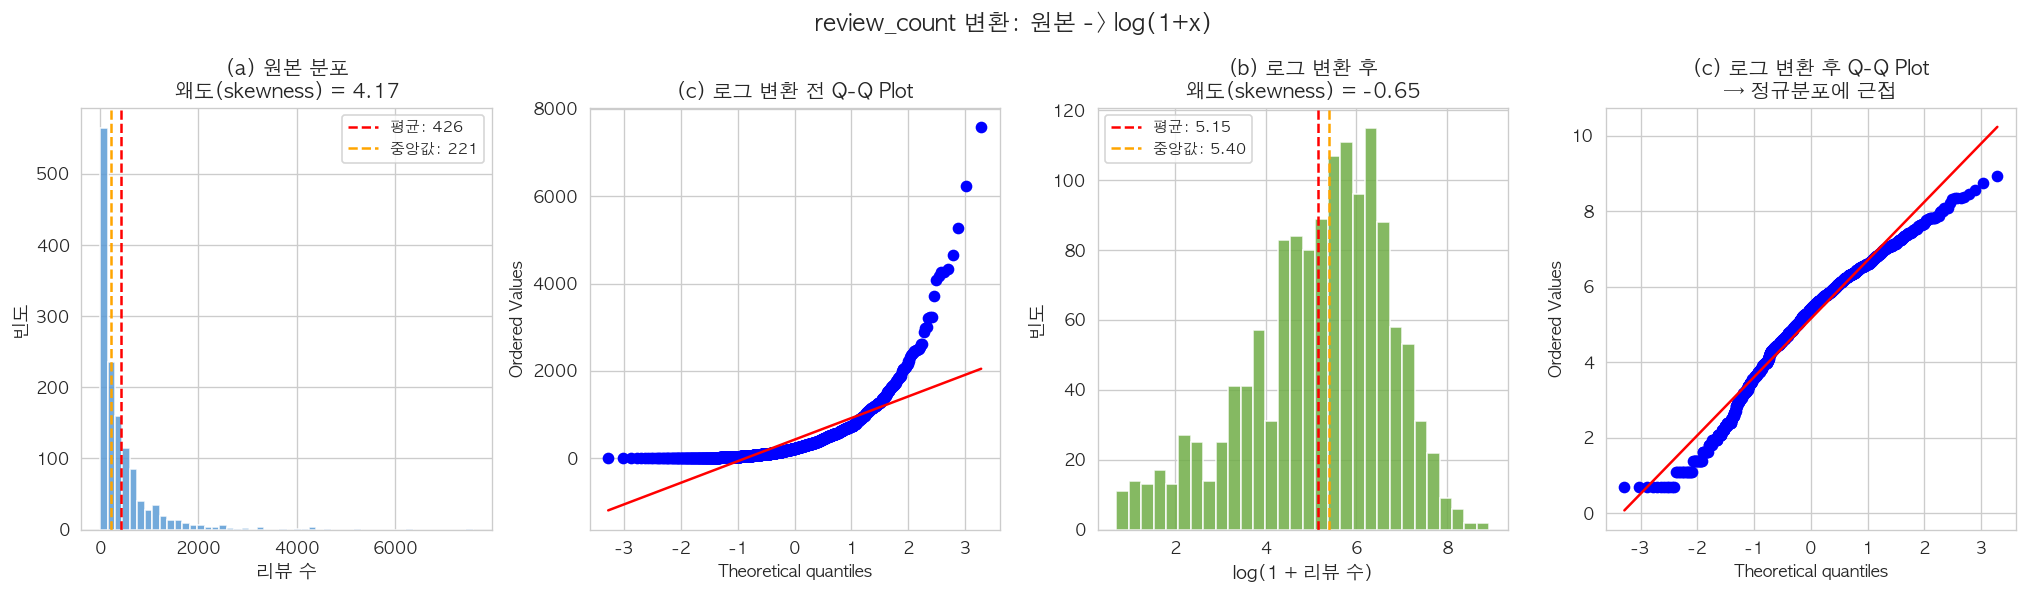

변환 전: 왜도 = 4.17 (심한 right-skew)
변환 후: 왜도 = -0.65 (대칭에 가까움)
-> 회귀분석 등에서 log_review_count를 사용하면 모델 가정에 더 적합


In [46]:
from scipy.stats import probplot
fig, axes = plt.subplots(1, 4, figsize=(17, 5))

# (좌) 원본 분포 — 극단적 right-skewed
axes[0].hist(df["review_count"], bins=50, color="#5B9BD5", edgecolor="white", alpha=0.85)
axes[0].axvline(df["review_count"].mean(), color="red", linestyle="--", 
                label=f'평균: {df["review_count"].mean():.0f}')
axes[0].axvline(df["review_count"].median(), color="orange", linestyle="--", 
                label=f'중앙값: {df["review_count"].median():.0f}')
axes[0].set_xlabel("리뷰 수", fontsize=11)
axes[0].set_ylabel("빈도", fontsize=11)
axes[0].set_title(f"(a) 원본 분포\n왜도(skewness) = {df['review_count'].skew():.2f}", fontsize=12)
axes[0].legend(fontsize=9)

#
probplot(df["review_count"], dist='norm', plot=axes[1])
axes[1].set_title("(c) 로그 변환 전 Q-Q Plot", fontsize=12)
 
# 로그 변환 후 — 훨씬 대칭적
df["log_review_count"] = np.log1p(df["review_count"])
axes[2].hist(df["log_review_count"], bins=30, color="#70AD47", edgecolor="white", alpha=0.85)
axes[2].axvline(df["log_review_count"].mean(), color="red", linestyle="--", 
                label=f'평균: {df["log_review_count"].mean():.2f}')
axes[2].axvline(df["log_review_count"].median(), color="orange", linestyle="--", 
                label=f'중앙값: {df["log_review_count"].median():.2f}')
axes[2].set_xlabel("log(1 + 리뷰 수)", fontsize=11)
axes[2].set_ylabel("빈도", fontsize=11)
axes[2].set_title(f"(b) 로그 변환 후\n왜도(skewness) = {df['log_review_count'].skew():.2f}", fontsize=12)
axes[2].legend(fontsize=9)
 
# Q-Q plot으로 정규성 비교
probplot(df["log_review_count"], dist="norm", plot=axes[3])
axes[3].set_title("(c) 로그 변환 후 Q-Q Plot\n→ 정규분포에 근접", fontsize=12)
 
plt.suptitle("review_count 변환: 원본 -> log(1+x)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
 
print(f"변환 전: 왜도 = {df['review_count'].skew():.2f} (심한 right-skew)")
print(f"변환 후: 왜도 = {df['log_review_count'].skew():.2f} (대칭에 가까움)")
print(f"-> 회귀분석 등에서 log_review_count를 사용하면 모델 가정에 더 적합")

### 2.3-2 리뷰 수(review_count) 로그 변환
리뷰 수의 원본 분포를 확인한 결과를 보면 최솟값 1건에서 최댓값 7,590건까지 극단적으로 넓은 범위를 보이고 왜도(skewness)가 4.17로 오른쪽으로 심하게 치우친(right-skewed) 분포를 나타냈다. 

평균(426건)과 중앙값(221건)의 괴리가 크다는 점에서도 이를 확인할 수 있다. 이러한 분포를 그대로 회귀분석에 투입하면 극단적으로 리뷰가 많은 소수의 가게가 모델 적합에 과도한 영향을 미치게 되고 잔차의 등분산성 가정도 위배될 가능성이 높다.

이를 해결하기 위해 $log(1+x)$ 변환을 적용하였다. 

1을 더한 이유는 리뷰 수가 0인 관측치가 존재할 경우 $log(0)$ 이 정의되지 않는 문제를 방지하기 위해서다. 

변환 후 왜도는 -0.65로, 원본 대비 대칭 분포에 가까워졌음을 확인하였다. Q-Q Plot에서도 변환 후 데이터가 정규분포의 이론적 분위수 선에 상당히 가깝게 분포하는 것을 확인할 수 있다.

소주제 5의 다중회귀 모델에서는 원본 `review_count` 대신 이 $log$ 변환된 값 `log_review_count`을 독립변수로 사용한다.

##### 여기서 잠깐!! rating을 변환하지 않은 이유

* 왜도가 -0.73으로 심하지 않았다.

    일반적으로 $|\text{왜도}| > 2$ 정도면 변환을 고려하는데, -0.73은 약한 좌편향일 뿐.

* 해석이 어려워진다..

    "평균 평점 4.2 vs 4.0" 은 바로 이해되지만, "로그 평점 1.435 vs 1.386" 은 직관적이지 않다.


* 우리 분석 방법과 안 맞지않다.

    소주제 1~4에서 그룹 비교(ANOVA, Kruskal-Wallis)를 하는데, 이런 검정은 원본 값으로 하는 게 자연스럽고, Kruskal-Wallis는 어차피 비모수라 정규성 가정이 필요 없다.

* review_count와 상황이 다름. 

    review_count는 왜도 4.17에 범위가 7,590배 차이라서 변환이 필수였지만, rating은 그렇지 않다!

----

### 2.3-3 리뷰 수 구간 변수 생성

* 소주제 2에서 구간별 비교에 사용하기 위해서 파생변수를 생성하였다.

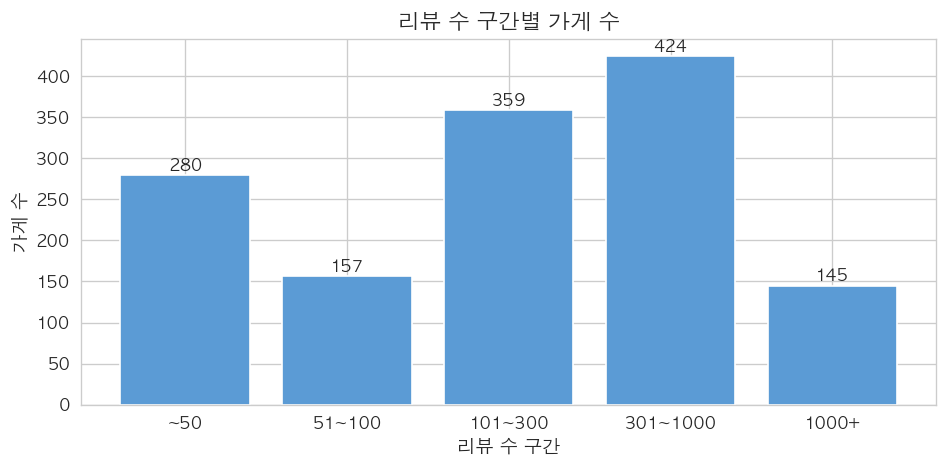

리뷰 수 구간별 분포:
review_group
~50         280
51~100      157
101~300     359
301~1000    424
1000+       145


In [47]:
df["review_group"] = pd.cut(
    df["review_count"],
    bins=[0, 50, 100, 300, 1000, np.inf],
    labels=["~50", "51~100", "101~300", "301~1000", "1000+"],
    include_lowest=True,
)
 
fig, ax = plt.subplots(figsize=(8, 4))
rg_counts = df["review_group"].value_counts().sort_index()
bars = ax.bar(rg_counts.index, rg_counts.values, color="#5B9BD5", edgecolor="white")
for bar, val in zip(bars, rg_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 5, str(val), ha="center", fontweight="bold")
ax.set_xlabel("리뷰 수 구간", fontsize=11)
ax.set_ylabel("가게 수", fontsize=11)
ax.set_title("리뷰 수 구간별 가게 수", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
 
print("리뷰 수 구간별 분포:")
print(rg_counts.to_string())

---

### 2.4 독립변수 간 다중공선성 사전 확인

* 소주제 5에서 다중회귀 모델을 적합하기 전에, 독립변수 간 강한 상관이 있는지 사전에 확인한다.

* 강한 상관 $|r| > 0.7$ 이 있으면 회귀계수의 추정이 불안정해질 수 있다.


In [48]:
# 수치형 독립변수 간 상관계수
indep_vars = ["price_level", "review_count", "log_review_count"]
indep_corr = df[indep_vars].corr()

print("독립변수 간 Pearson 상관계수:")
print(indep_corr.round(3).to_string())

print(f"\n주요 쌍별 상관:")
print(f"  price_level <-> review_count:     r = {df['price_level'].corr(df['review_count']):.3f}")
print(f"  price_level <-> log_review_count: r = {df['price_level'].corr(df['log_review_count']):.3f}")

# review_count와 log_review_count는 변환 관계이므로 당연히 높음 → 둘 중 하나만 모델에 사용
print(f"  review_count <-> log_review_count: r = {df['review_count'].corr(df['log_review_count']):.3f} (변환 관계, 둘 중 하나만 사용)")

print(f"\n판단:")
print(f"  price_level ↔ log_review_count: |r| = {abs(df['price_level'].corr(df['log_review_count'])):.3f} < 0.3")
print(f"  -> 독립변수 간 심각한 다중공선성 없음")
print(f"  -> 소주제 5에서 VIF로 정식 진단 예정")

독립변수 간 Pearson 상관계수:
                  price_level  review_count  log_review_count
price_level             1.000         0.183             0.319
review_count            0.183         1.000             0.685
log_review_count        0.319         0.685             1.000

주요 쌍별 상관:
  price_level <-> review_count:     r = 0.183
  price_level <-> log_review_count: r = 0.319
  review_count <-> log_review_count: r = 0.685 (변환 관계, 둘 중 하나만 사용)

판단:
  price_level ↔ log_review_count: |r| = 0.319 < 0.3
  -> 독립변수 간 심각한 다중공선성 없음
  -> 소주제 5에서 VIF로 정식 진단 예정


----

### 2.5 전처리 완료 요약

In [49]:
# ── 최종 데이터 요약 ──
print("=" * 55)
print("전처리 완료 데이터 요약")
print("=" * 55)
print(f"  총 관측치:     {len(df)}개")
print(f"  행정구:        {df['district'].nunique()}개")
print(f"  업종:          음식점 {(df['business_type']=='음식점').sum()}개 / 카페 {(df['business_type']=='카페').sum()}개")
print(f"")
print(f"  [종속변수]")
print(f"  rating:        {df['rating'].min()} ~ {df['rating'].max()} (평균: {df['rating'].mean():.3f}, 중앙값: {df['rating'].median()})")
print(f"")
print(f"  [독립변수]")
print(f"  price_category: 저가 {(df['price_category']=='저가').sum()} / 중가 {(df['price_category']=='중가').sum()} / 고가 {(df['price_category']=='고가').sum()}")
print(f"  review_count:   {df['review_count'].min()} ~ {df['review_count'].max()} (중앙값: {df['review_count'].median():.0f})")
print(f"  district:       {df['district'].nunique()}개 행정구 (최소 {df['district'].value_counts().min()}개 ~ 최대 {df['district'].value_counts().max()}개)")
print(f"  business_type:  음식점 / 카페")
 
# ── 분석에 사용할 변수 정리 ──
print(f"\n분석에 사용할 변수:")
print(f"  종속변수: rating (평점, 1.0~5.0)")
print(f"  독립변수: price_category, log_review_count, district, business_type")
print(f"  파생변수: price_category, log_review_count, review_group")

전처리 완료 데이터 요약
  총 관측치:     1365개
  행정구:        16개
  업종:          음식점 851개 / 카페 514개

  [종속변수]
  rating:        2.3 ~ 5.0 (평균: 4.142, 중앙값: 4.2)

  [독립변수]
  price_category: 저가 285 / 중가 1021 / 고가 59
  review_count:   1 ~ 7590 (중앙값: 221)
  district:       16개 행정구 (최소 51개 ~ 최대 171개)
  business_type:  음식점 / 카페

분석에 사용할 변수:
  종속변수: rating (평점, 1.0~5.0)
  독립변수: price_category, log_review_count, district, business_type
  파생변수: price_category, log_review_count, review_group


-----

## 3. EDA(탐색적 자료분석)

* 본격적인 소주제 분석에 앞서 데이터의 전반적인 구조와 분포를 탐색한다.

### 3.1 종속변수: 평점(rating) 분포

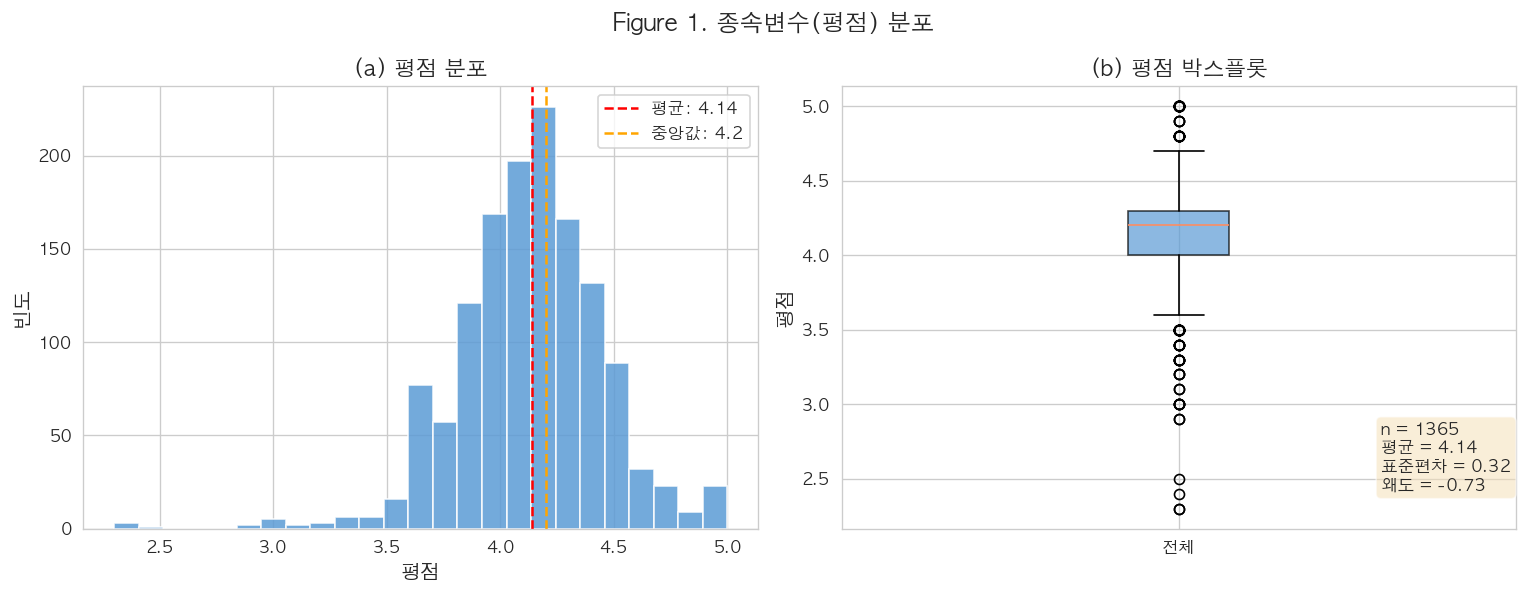

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (좌) 히스토그램
axes[0].hist(df["rating"], bins=25, color="#5B9BD5", edgecolor="white", alpha=0.85)
axes[0].axvline(df["rating"].mean(), color="red", linestyle="--", linewidth=1.5, 
                label=f'평균: {df["rating"].mean():.2f}')
axes[0].axvline(df["rating"].median(), color="orange", linestyle="--", linewidth=1.5, 
                label=f'중앙값: {df["rating"].median():.1f}')
axes[0].set_xlabel("평점", fontsize=12)
axes[0].set_ylabel("빈도", fontsize=12)
axes[0].set_title("(a) 평점 분포", fontsize=13)
axes[0].legend(fontsize=10)

# (우) 박스플롯
bp = axes[1].boxplot(df["rating"], vert=True, patch_artist=True, 
                      boxprops=dict(facecolor="#5B9BD5", alpha=0.7))
axes[1].set_ylabel("평점", fontsize=12)
axes[1].set_title("(b) 평점 박스플롯", fontsize=13)
axes[1].set_xticklabels(["전체"])

# 통계량 텍스트
stats_text = (f'n = {len(df)}\n'
              f'평균 = {df["rating"].mean():.2f}\n'
              f'표준편차 = {df["rating"].std():.2f}\n'
              f'왜도 = {df["rating"].skew():.2f}')
axes[1].text(1.3, df["rating"].min() + 0.1, stats_text, fontsize=10, 
             verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle("Figure 1. 종속변수(평점) 분포", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


- 평점은 평균 4.14, 중앙값 4.2로 **좌편향(left-skewed)** 분포를 보인다.
- 대부분의 가게가 3.5~4.5 사이에 밀집되어 있으며, 2점대 이하는 극소수이다.
- 이는 온라인 평점의 일반적 특성(긍정 편향)과 일치한다고 생각할 수 있다.

### 3.2 독립변수 분포

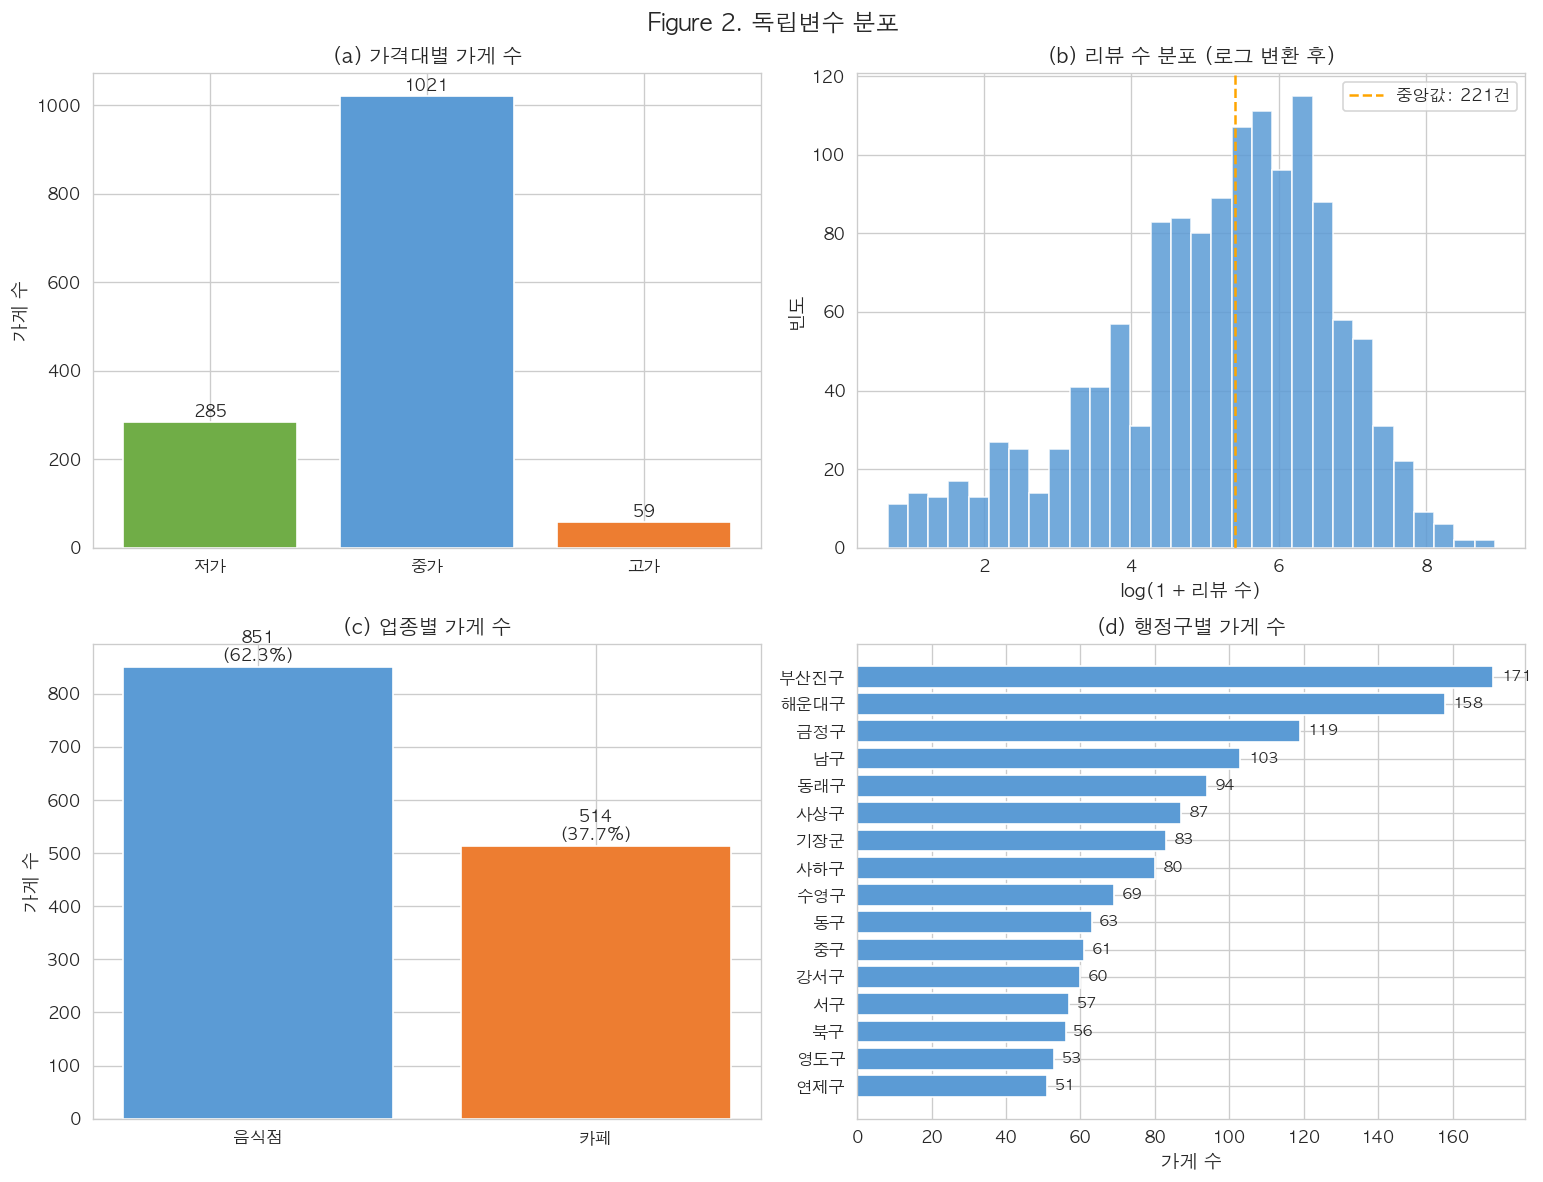

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
# (a) 가격대 분포
price_counts = df["price_category"].value_counts().reindex(["저가", "중가", "고가"])
colors_price = ["#70AD47", "#5B9BD5", "#ED7D31"]
bars = axes[0, 0].bar(price_counts.index, price_counts.values, color=colors_price, edgecolor="white")
for bar, val in zip(bars, price_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, val + 10, str(val), ha="center", fontweight="bold")
axes[0, 0].set_ylabel("가게 수", fontsize=11)
axes[0, 0].set_title("(a) 가격대별 가게 수", fontsize=12)

# (b) 리뷰 수 분포 (로그 스케일)
axes[0, 1].hist(df["log_review_count"], bins=30, color="#5B9BD5", edgecolor="white", alpha=0.85)
axes[0, 1].axvline(df["log_review_count"].median(), color="orange", linestyle="--", 
                    label=f'중앙값: {df["review_count"].median():.0f}건')
axes[0, 1].set_xlabel("log(1 + 리뷰 수)", fontsize=11)
axes[0, 1].set_ylabel("빈도", fontsize=11)
axes[0, 1].set_title("(b) 리뷰 수 분포 (로그 변환 후)", fontsize=12)
axes[0, 1].legend(fontsize=10)

# (c) 업종 분포
bt_counts = df["business_type"].value_counts()
colors_bt = ["#5B9BD5", "#ED7D31"]
bars = axes[1, 0].bar(bt_counts.index, bt_counts.values, color=colors_bt, edgecolor="white")
for bar, val in zip(bars, bt_counts.values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, val + 10, f"{val}\n({val/len(df)*100:.1f}%)", 
                     ha="center", fontsize=10)
axes[1, 0].set_ylabel("가게 수", fontsize=11)
axes[1, 0].set_title("(c) 업종별 가게 수", fontsize=12)

# (d) 행정구별 가게 수
dist_counts = df["district"].value_counts().sort_values()
axes[1, 1].barh(dist_counts.index, dist_counts.values, color="#5B9BD5", edgecolor="white")
for i, val in enumerate(dist_counts.values):
    axes[1, 1].text(val + 2, i, str(val), va="center", fontsize=9)
axes[1, 1].set_xlabel("가게 수", fontsize=11)
axes[1, 1].set_title("(d) 행정구별 가게 수", fontsize=12)

plt.suptitle("Figure 2. 독립변수 분포", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


- **(a) 가격대:** 중가(MODERATE)가 1,021개(74.8%)로 대다수를 차지한다. 저가 285개(20.9%), 고가 59개(4.3%).
- **(b) 리뷰 수:** 로그 변환 후 비교적 대칭적 분포를 보인다. 원본 중앙값 221건으로, 리뷰가 어느 정도 축적된 가게들이다.
- **(c) 업종:** 음식점(62.3%)이 카페(37.7%)보다 많지만, 두 그룹 모두 충분한 표본 크기를 가진다.
- **(d) 행정구:** 16개 구·군 모두 포함되어 있으며, 최소 51개(연제구)~최대 171개(부산진구)로 분석에 충분하다.

### 3.3 변수 간 상관관계

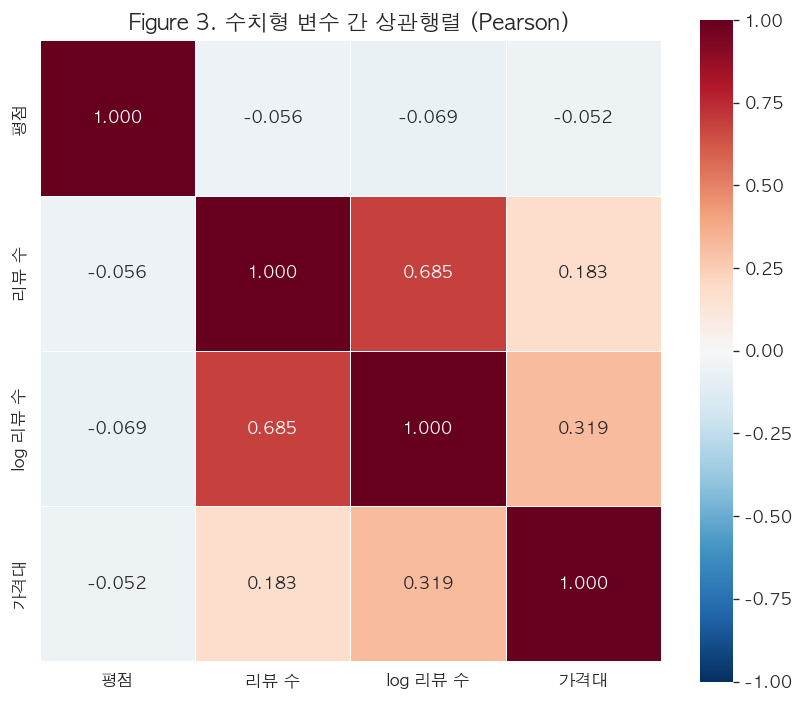

주요 상관관계:
  평점 <-> 리뷰 수:     r = -0.056
  평점 <-> log 리뷰 수: r = -0.069
  평점 <-> 가격대:      r = -0.052
  리뷰 수 <-> 가격대:   r = 0.183


In [52]:
# 수치형 변수 간 상관행렬
corr_vars = ["rating", "review_count", "log_review_count", "price_level"]
corr_labels = ["평점", "리뷰 수", "log 리뷰 수", "가격대"]
corr_matrix = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            square=True, vmin=-1, vmax=1, ax=ax,
            xticklabels=corr_labels, yticklabels=corr_labels,
            linewidths=0.5)
ax.set_title("Figure 3. 수치형 변수 간 상관행렬 (Pearson)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# 주요 상관계수 출력
print("주요 상관관계:")
print(f"  평점 <-> 리뷰 수:     r = {corr_matrix.loc['rating','review_count']:.3f}")
print(f"  평점 <-> log 리뷰 수: r = {corr_matrix.loc['rating','log_review_count']:.3f}")
print(f"  평점 <-> 가격대:      r = {corr_matrix.loc['rating','price_level']:.3f}")
print(f"  리뷰 수 <-> 가격대:   r = {corr_matrix.loc['review_count','price_level']:.3f}")

- 평점과 다른 변수들 간의 상관관계는 전반적으로 약하다->  $|r| < 0.15$.
- 평점과 리뷰 수는 약한 음의 상관($r ≈ -0.10$)으로, 리뷰가 많을수록 평점이 약간 낮아지는 경향이 있다.
- 이는 리뷰가 많이 쌓일수록 다양한 의견이 반영되어 극단적 고평점이 줄어드는 효과일 수 있다.
- 가격대와 평점 사이에는 거의 상관이 없다 ($r ≈ 0.01$).
- **개별 변수만으로 평점을 설명하기 어려울 수 있음을 시사한다.**

### 3.4 주요 이변량 관계 탐색

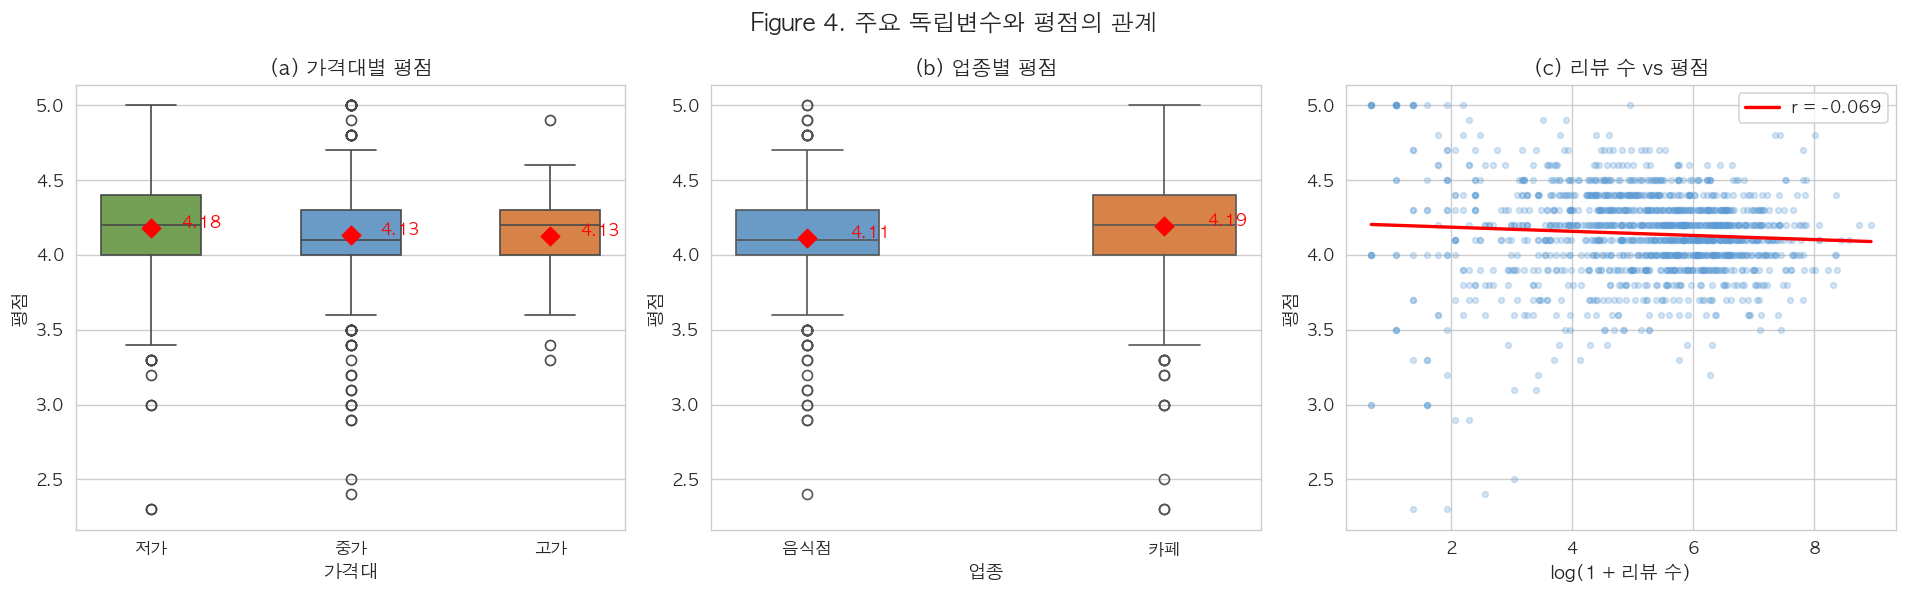

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) 가격대별 평점
order_price = ["저가", "중가", "고가"]
sns.boxplot(data=df, x="price_category", y="rating", order=order_price,
            palette=["#70AD47", "#5B9BD5", "#ED7D31"], ax=axes[0], width=0.5)
# 평균 표시
for i, cat in enumerate(order_price):
    mean_val = df[df["price_category"] == cat]["rating"].mean()
    axes[0].scatter(i, mean_val, color="red", s=60, zorder=5, marker="D")
    axes[0].text(i + 0.15, mean_val, f"{mean_val:.2f}", color="red", fontsize=10, fontweight="bold")
axes[0].set_xlabel("가격대", fontsize=11)
axes[0].set_ylabel("평점", fontsize=11)
axes[0].set_title("(a) 가격대별 평점", fontsize=12)

# (b) 업종별 평점
sns.boxplot(data=df, x="business_type", y="rating",
            palette=["#5B9BD5", "#ED7D31"], ax=axes[1], width=0.4)
for i, bt in enumerate(df["business_type"].unique()):
    mean_val = df[df["business_type"] == bt]["rating"].mean()
    axes[1].scatter(i, mean_val, color="red", s=60, zorder=5, marker="D")
    axes[1].text(i + 0.12, mean_val, f"{mean_val:.2f}", color="red", fontsize=10, fontweight="bold")
axes[1].set_xlabel("업종", fontsize=11)
axes[1].set_ylabel("평점", fontsize=11)
axes[1].set_title("(b) 업종별 평점", fontsize=12)

# (c) 리뷰 수 vs 평점 산점도
axes[2].scatter(df["log_review_count"], df["rating"], alpha=0.25, s=12, color="#5B9BD5")
# 추세선
z = np.polyfit(df["log_review_count"], df["rating"], 1)
p_line = np.poly1d(z)
x_line = np.linspace(df["log_review_count"].min(), df["log_review_count"].max(), 100)
r_val = df["log_review_count"].corr(df["rating"])
axes[2].plot(x_line, p_line(x_line), color="red", linewidth=2, label=f"r = {r_val:.3f}")
axes[2].set_xlabel("log(1 + 리뷰 수)", fontsize=11)
axes[2].set_ylabel("평점", fontsize=11)
axes[2].set_title("(c) 리뷰 수 vs 평점", fontsize=12)
axes[2].legend(fontsize=10)

plt.suptitle("Figure 4. 주요 독립변수와 평점의 관계", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

- **(a)** 저가, 중가, 고가 간 평점의 중앙값과 평균이 매우 유사하다. 가격대에 따른 뚜렷한 차이는 보이지 않는다.
- **(b)** 음식점과 카페의 평점 분포도 유사하나 음식점인 경우에 outlier가 많이 보인다.
- **(c)** 리뷰 수와 평점 사이에 약한 음의 관계가 관찰된다. 리뷰가 적은 가게에서 평점의 변동 폭이 크다.

### 3.5 행정구별 평점 분포

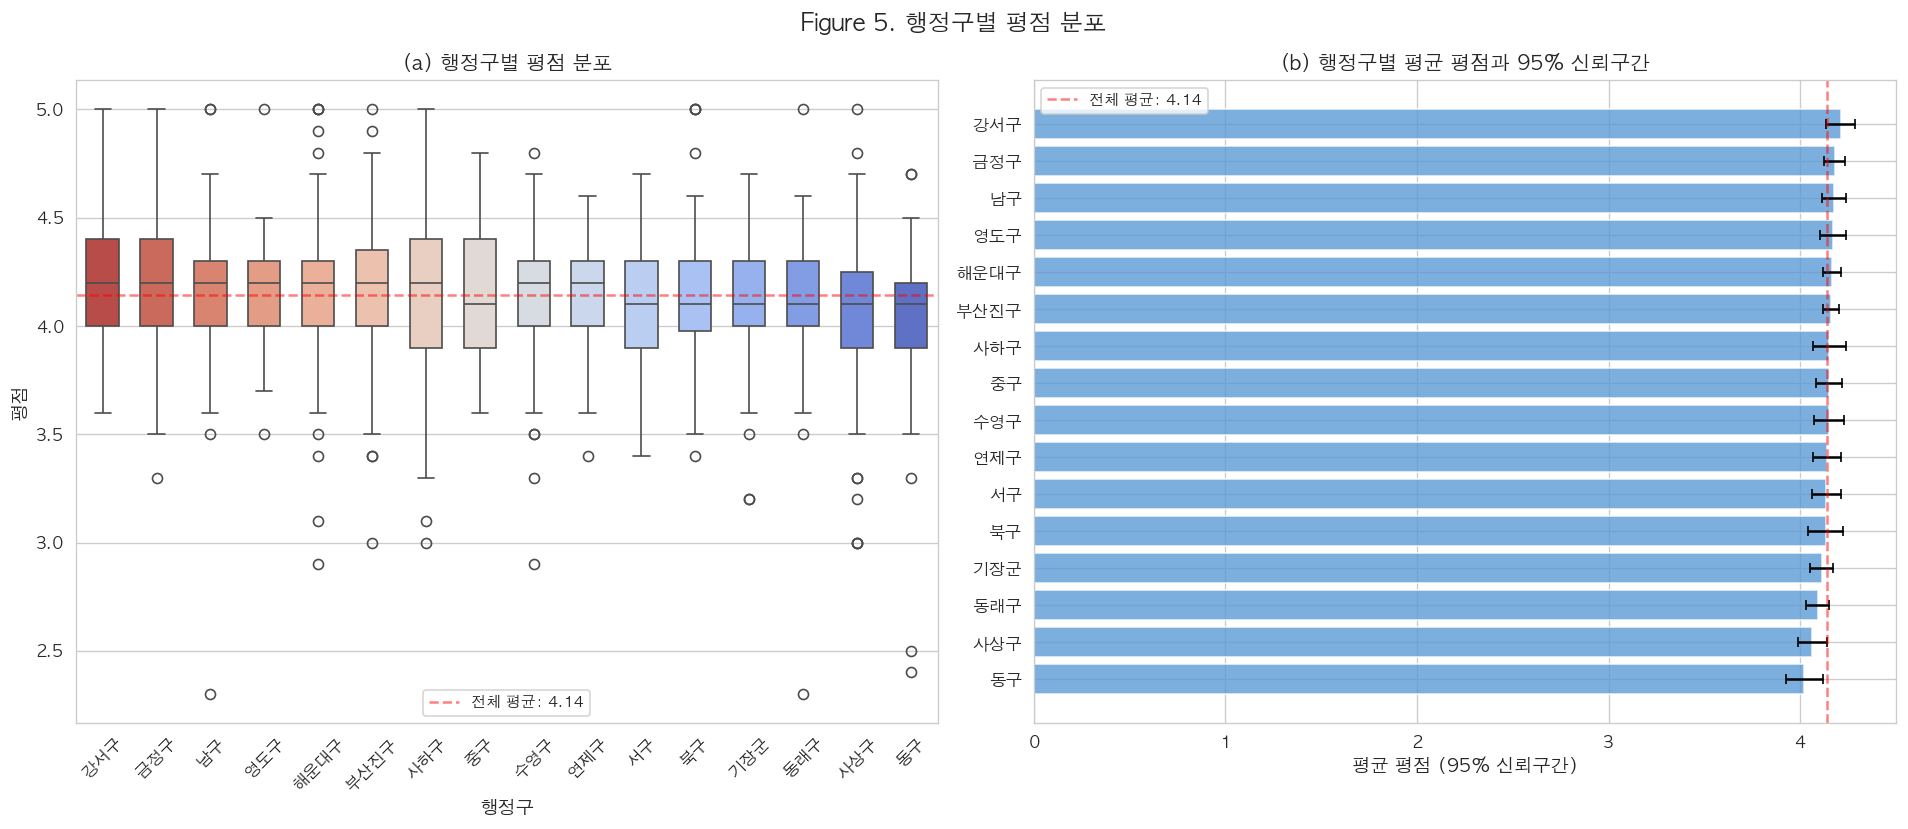

행정구별 요약 (평균 평점 순):
          count   mean  median    std
district                             
강서구          60  4.212     4.2  0.293
금정구         119  4.180     4.2  0.294
남구          103  4.176     4.2  0.323
영도구          53  4.174     4.2  0.251
해운대구        158  4.167     4.2  0.311
부산진구        171  4.160     4.2  0.289
사하구          80  4.152     4.2  0.396
중구           61  4.151     4.1  0.269
수영구          69  4.149     4.2  0.329
연제구          51  4.139     4.2  0.268
서구           57  4.137     4.1  0.292
북구           56  4.134     4.1  0.350
기장군          83  4.113     4.1  0.281
동래구          94  4.091     4.1  0.292
사상구          87  4.062     4.1  0.360
동구           63  4.022     4.1  0.397


In [54]:
# 평균 평점 순으로 정렬
district_order = df.groupby("district")["rating"].mean().sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# (a) 박스플롯
sns.boxplot(data=df, x="district", y="rating", order=district_order,
            palette="coolwarm_r", ax=axes[0], width=0.6)
axes[0].axhline(df["rating"].mean(), color="red", linestyle="--", alpha=0.5, 
                label=f'전체 평균: {df["rating"].mean():.2f}')
axes[0].set_xlabel("행정구", fontsize=11)
axes[0].set_ylabel("평점", fontsize=11)
axes[0].set_title("(a) 행정구별 평점 분포", fontsize=12)
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(fontsize=9)

# (b) 평균 + 95% 신뢰구간
dist_stats = df.groupby("district")["rating"].agg(["mean", "std", "count"])
dist_stats["se"] = dist_stats["std"] / np.sqrt(dist_stats["count"])
dist_stats["ci95"] = dist_stats["se"] * 1.96
dist_stats = dist_stats.sort_values("mean", ascending=True)

axes[1].barh(range(len(dist_stats)), dist_stats["mean"],
             xerr=dist_stats["ci95"], color="#5B9BD5", edgecolor="white",
             capsize=3, alpha=0.8)
axes[1].set_yticks(range(len(dist_stats)))
axes[1].set_yticklabels(dist_stats.index)
axes[1].axvline(df["rating"].mean(), color="red", linestyle="--", alpha=0.5,
                label=f'전체 평균: {df["rating"].mean():.2f}')
axes[1].set_xlabel("평균 평점 (95% 신뢰구간)", fontsize=11)
axes[1].set_title("(b) 행정구별 평균 평점과 95% 신뢰구간", fontsize=12)
axes[1].legend(fontsize=9)

plt.suptitle("Figure 5. 행정구별 평점 분포", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 수치 요약
print("행정구별 요약 (평균 평점 순):")
summary = df.groupby("district")["rating"].agg(["count", "mean", "median", "std"]).round(3)
print(summary.sort_values("mean", ascending=False).to_string())

- 강서구(4.21), 금정구(4.18), 남구(4.18)이 상대적으로 높은 평균 평점을 보인다.
- 동구(4.02), 사상구(4.06)는 상대적으로 낮은 평균 평점을 보인다.
- 다만 대부분의 행정구가 4.0~4.2 범위 안에 있어 차이가 크지는 않다.
- 95% 신뢰구간이 상당 부분 겹치는 것으로 보아, 통계적 유의성은 별도 검정이 필요하다.

### 3.6 업종 x 가격대 교차 분석

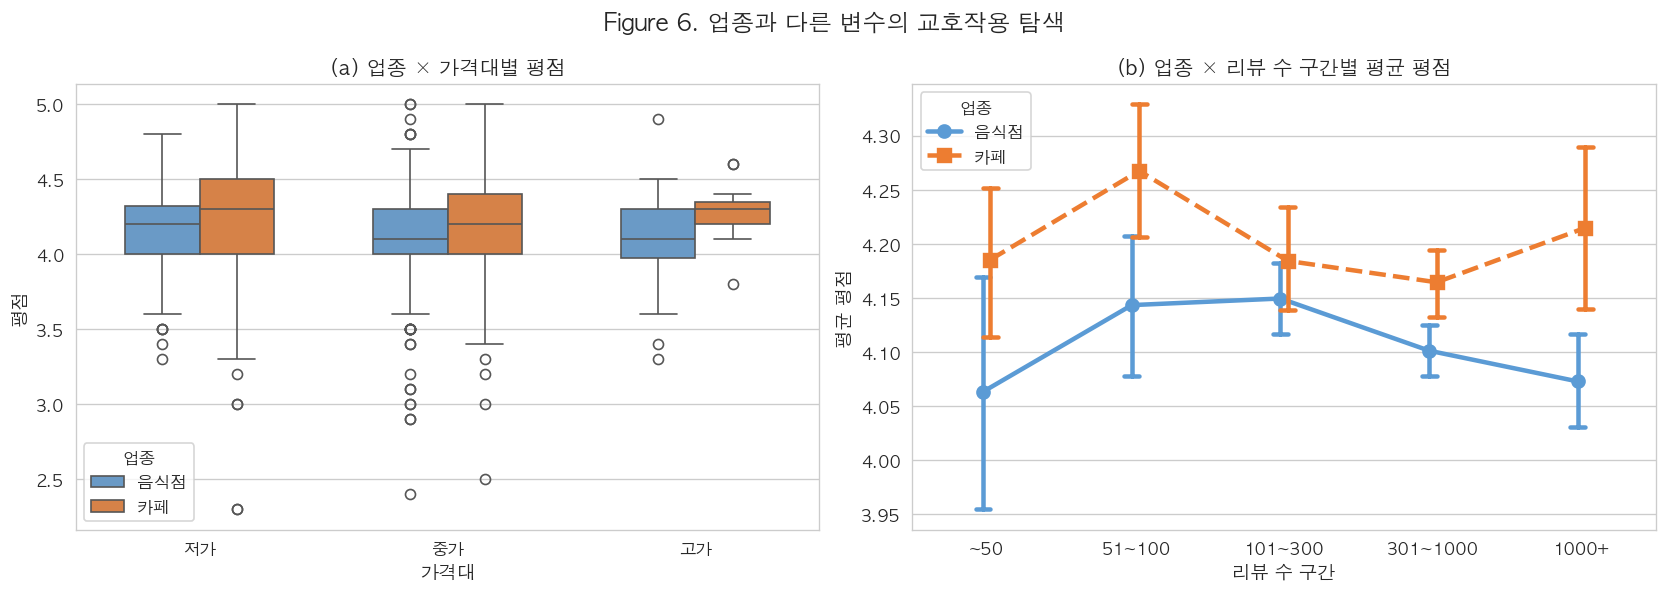

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# (a) 업종 × 가격대별 평점
sns.boxplot(data=df, x="price_category", y="rating", hue="business_type",
            order=["저가", "중가", "고가"], palette=["#5B9BD5", "#ED7D31"],
            ax=axes[0], width=0.6)
axes[0].set_xlabel("가격대", fontsize=11)
axes[0].set_ylabel("평점", fontsize=11)
axes[0].set_title("(a) 업종 × 가격대별 평점", fontsize=12)
axes[0].legend(title="업종", fontsize=10)

# (b) 업종 × 리뷰구간별 평점
review_order = ["~50", "51~100", "101~300", "301~1000", "1000+"]
sns.pointplot(data=df, x="review_group", y="rating", hue="business_type",
              order=review_order, palette=["#5B9BD5", "#ED7D31"],
              ax=axes[1], dodge=True, markers=["o", "s"], linestyles=["-", "--"],
              errorbar="ci", capsize=0.1)
axes[1].set_xlabel("리뷰 수 구간", fontsize=11)
axes[1].set_ylabel("평균 평점", fontsize=11)
axes[1].set_title("(b) 업종 × 리뷰 수 구간별 평균 평점", fontsize=12)
axes[1].legend(title="업종", fontsize=10)

plt.suptitle("Figure 6. 업종과 다른 변수의 교호작용 탐색", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

- **(a)** 저가와 중가에서는 음식점과 카페의 평점이 유사하나 고가에서는 차이가 나타날 수 있다 (단! 고가 표본이 적어 주의 필요).
- **(b)** 리뷰 수가 적은 구간(~50)에서 카페의 평점이 음식점보다 약간 높으며, 리뷰가 1000건 이상인 구간에서는 두 업종 모두 평점이 하락하는 경향이 있다.
- **-> 업종에 따라 평점 형성 패턴이 다를 가능성이 있으며, 이는 소주제 4에서 상세 분석한다.**

### 3.7 기술통계 요약표

In [56]:
# 전체 기술통계
desc = df[["rating", "review_count", "price_level"]].describe().round(3)
desc.index = ["관측치 수", "평균", "표준편차", "최솟값", "Q1(25%)", "중앙값(50%)", "Q3(75%)", "최댓값"]
desc.columns = ["평점(rating)", "리뷰 수(review_count)", "가격대(price_level)"]
print("Table 1. 주요 변수 기술통계량")
print(desc.to_string())

Table 1. 주요 변수 기술통계량
          평점(rating)  리뷰 수(review_count)  가격대(price_level)
관측치 수       1365.000            1365.000          1365.000
평균             4.142             425.866             1.838
표준편차           0.315             629.621             0.487
최솟값            2.300               1.000             1.000
Q1(25%)        4.000              74.000             2.000
중앙값(50%)       4.200             221.000             2.000
Q3(75%)        4.300             541.000             2.000
최댓값            5.000            7590.000             4.000


### 3.8 EDA 핵심 요약
 
 | 발견 | 내용 | 시사점 |
 |------|------|--------|
 | 평점 분포 | 좌편향, 평균 4.14 | 온라인 평점의 긍정 편향 특성 |
 | 가격대-평점 | 상관 거의 없음 (r ≈ 0.01) | 비싼 곳이 평점 높지 않음 |
 | 리뷰 수-평점 | 약한 음의 상관 (r ≈ -0.10) | 리뷰 많을수록 평점 약간 하락 |
 | 행정구별 | 시각적 차이 존재 | 통계 검정 필요 |
 | 업종별 | 유사하나 교호작용 가능성 | 소주제 4에서 상세 분석 |

----

## Part 2: 소주제별 분석

### 소주제 1: 가격대(저가/중가/고가)에 따라 평점에 유의한 차이가 있는가?

 **가설:**
- H₀: 가격대별 평점의 분포에 차이가 없다
- H₁: 적어도 하나의 가격대에서 평점의 분포가 다르다

### 1.1 가격대별 기술통계

In [57]:
from scipy.stats import kruskal, mannwhitneyu, shapiro, levene, f_oneway

In [58]:
# 가격대별 그룹 분리
price_groups = {cat: df[df["price_category"] == cat]["rating"] for cat in ["저가", "중가", "고가"]}

# 기술통계 테이블
desc_table = pd.DataFrame({
    cat: {
        "n": len(g),
        "평균": f"{g.mean():.3f}",
        "중앙값": f"{g.median():.1f}",
        "표준편차": f"{g.std():.3f}",
        "최솟값": f"{g.min():.1f}",
        "최댓값": f"{g.max():.1f}",
        "Q1": f"{g.quantile(0.25):.1f}",
        "Q3": f"{g.quantile(0.75):.1f}",
    } for cat, g in price_groups.items()
})
 
print("Table 2. 가격대별 평점 기술통계량")
print(desc_table.to_string())


Table 2. 가격대별 평점 기술통계량
         저가     중가     고가
n       285   1021     59
평균    4.178  4.133  4.127
중앙값     4.2    4.1    4.2
표준편차  0.383  0.295  0.290
최솟값     2.3    2.4    3.3
최댓값     5.0    5.0    4.9
Q1      4.0    4.0    4.0
Q3      4.4    4.3    4.3


### 1.2 가격대별 평점 분포 시각화

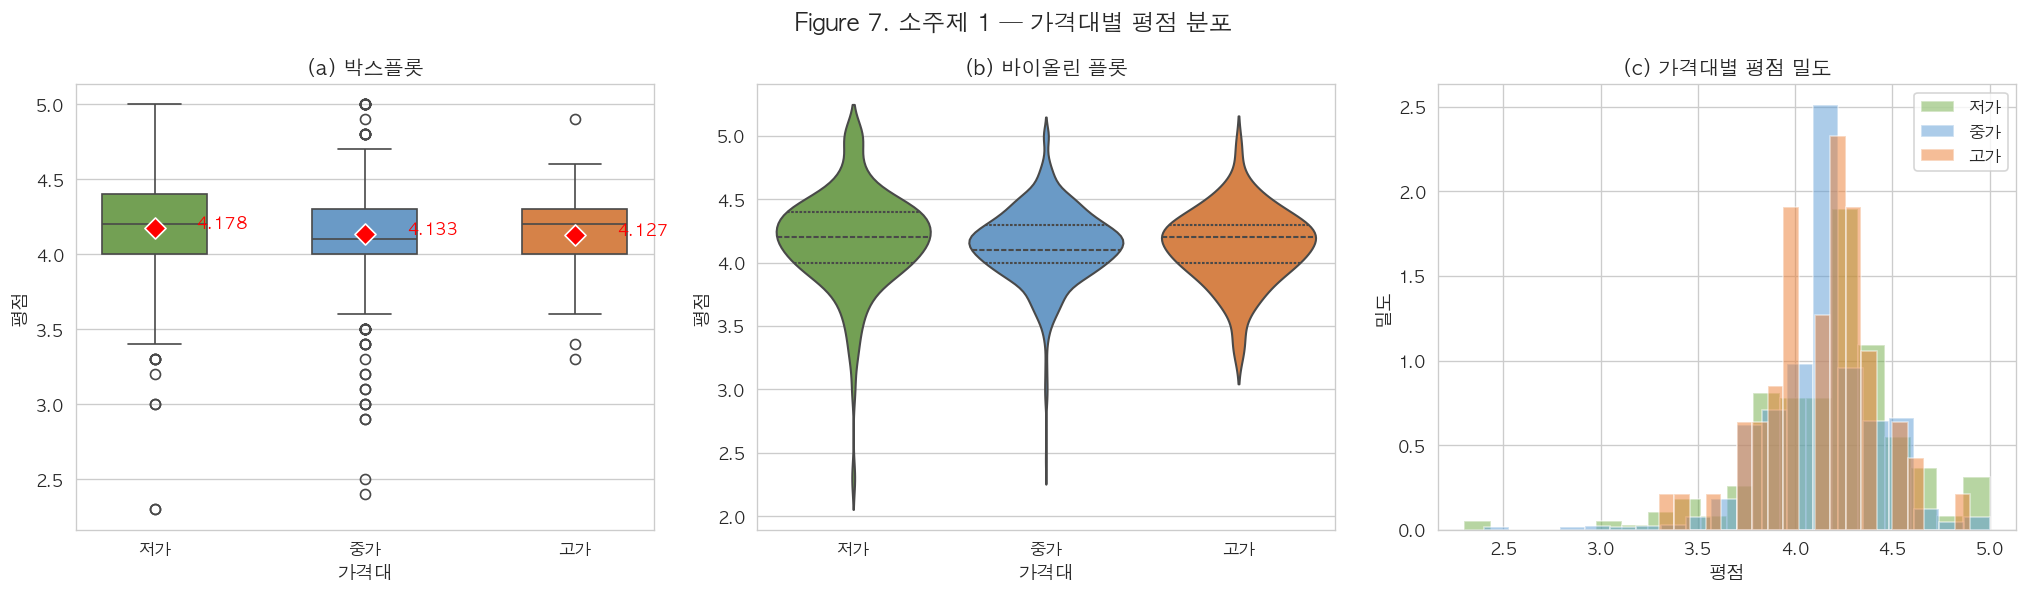

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
order = ["저가", "중가", "고가"]
colors = ["#70AD47", "#5B9BD5", "#ED7D31"]
 
# (a) 박스플롯
sns.boxplot(data=df, x="price_category", y="rating", order=order,
            palette=colors, ax=axes[0], width=0.5)
# 평균 마커
for i, cat in enumerate(order):
    mean_val = price_groups[cat].mean()
    axes[0].scatter(i, mean_val, color="red", s=80, zorder=5, marker="D", edgecolors="white", linewidth=1)
    axes[0].text(i + 0.2, mean_val, f"{mean_val:.3f}", color="red", fontsize=10, fontweight="bold")
axes[0].set_xlabel("가격대", fontsize=11)
axes[0].set_ylabel("평점", fontsize=11)
axes[0].set_title("(a) 박스플롯", fontsize=12)
 
# (b) 바이올린 플롯
sns.violinplot(data=df, x="price_category", y="rating", order=order,
               palette=colors, ax=axes[1], inner="quartile")
axes[1].set_xlabel("가격대", fontsize=11)
axes[1].set_ylabel("평점", fontsize=11)
axes[1].set_title("(b) 바이올린 플롯", fontsize=12)
 
# (c) 히스토그램 (겹쳐서)
for cat, color in zip(order, colors):
    axes[2].hist(price_groups[cat], bins=20, alpha=0.5, color=color, label=cat, density=True, edgecolor="white")
axes[2].set_xlabel("평점", fontsize=11)
axes[2].set_ylabel("밀도", fontsize=11)
axes[2].set_title("(c) 가격대별 평점 밀도", fontsize=12)
axes[2].legend()
 
plt.suptitle("Figure 7. 소주제 1 — 가격대별 평점 분포", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 1.3 검정 가정 확인

ANOVA를 적용하려면 **(1) 정규성**과 **(2) 등분산성** 가정이 필요하다.  

가정이 충족되지 않으면 비모수 검정(Kruskal-Wallis)을 사용한다.

(1) 정규성 검정 (Shapiro-Wilk)
    H_0: 해당 그룹의 평점은 정규분포를 따른다
    alpha = 0.05

    저가 (n=285): W = 0.9296, p = 0.000000 → 비정규 x
    중가 (n=1021): W = 0.9718, p = 0.000000 → 비정규 x
    고가 (n=59): W = 0.9718, p = 0.186208 → 정규분포 check

    결론: 저가, 중가가 비정규 -> ANOVA 가정 불충족

(2) 등분산성 검정 (Levene)
    H_0: 세 그룹의 분산이 동일하다
    통계량 = 6.4286, p = 0.001664
    -> 이분산 x (등분산 가정 불충족)


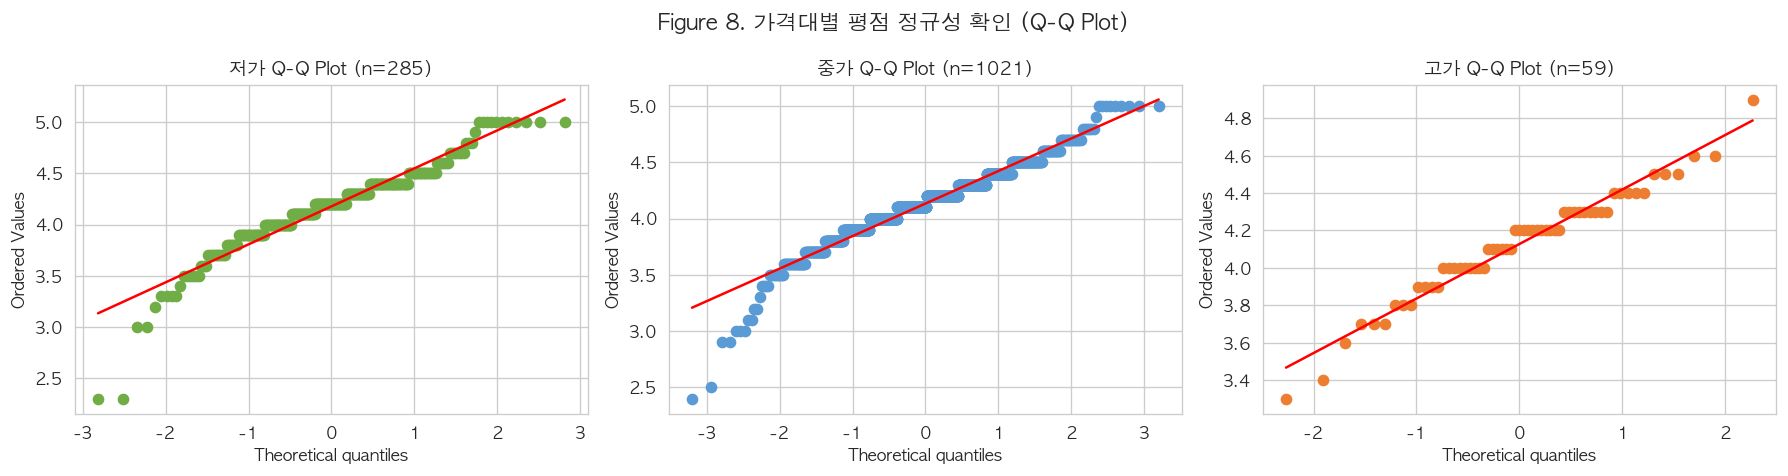


 정규성과 등분산성 모두 충족되지 않으므로,
   비모수 검정인 Kruskal-Wallis 검정을 주 검정으로 사용한다.
   ANOVA는 참고용으로 함께 보고한다.


In [60]:
# ── (1) 정규성 검정: Shapiro-Wilk ──
print("(1) 정규성 검정 (Shapiro-Wilk)")
print(f"    H_0: 해당 그룹의 평점은 정규분포를 따른다")
print(f"    alpha = 0.05\n")
 
normality_results = {}
for cat in order:
    g = price_groups[cat]
    # 표본이 5000개 초과하면 샘플링
    sample = g.sample(min(500, len(g)), random_state=42) if len(g) > 500 else g
    stat, p = shapiro(sample)
    is_normal = p >= 0.05
    normality_results[cat] = is_normal
    print(f"    {cat} (n={len(g)}): W = {stat:.4f}, p = {p:.6f} → {'정규분포 check' if is_normal else '비정규 x'}")
 
print(f"\n    결론: 저가, 중가가 비정규 -> ANOVA 가정 불충족")
 
# ── (2) 등분산성 검정: Levene ──
lev_stat, lev_p = levene(*price_groups.values())
print(f"\n(2) 등분산성 검정 (Levene)")
print(f"    H_0: 세 그룹의 분산이 동일하다")
print(f"    통계량 = {lev_stat:.4f}, p = {lev_p:.6f}")
print(f"    -> {'등분산 check!' if lev_p >= 0.05 else '이분산 x (등분산 가정 불충족)'}")
 
# 시각화: 정규성 Q-Q plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (cat, color) in enumerate(zip(order, colors)):
    from scipy.stats import probplot
    probplot(price_groups[cat], dist="norm", plot=axes[i])
    axes[i].set_title(f"{cat} Q-Q Plot (n={len(price_groups[cat])})", fontsize=11)
    axes[i].get_lines()[0].set_color(color)
plt.suptitle("Figure 8. 가격대별 평점 정규성 확인 (Q-Q Plot)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
 
print(f"\n 정규성과 등분산성 모두 충족되지 않으므로,")
print(f"   비모수 검정인 Kruskal-Wallis 검정을 주 검정으로 사용한다.")
print(f"   ANOVA는 참고용으로 함께 보고한다.")

ANOVA를 적용하려면 각 그룹의 데이터가 (1) 정규분포를 따르고 (2) 그룹 간 분산이 동일해야 한다. 

두 가정이 충족되지 않으면 비모수 검정을 사용해야 하므로, 본격적인 검정에 앞서 가정을 확인한다.

**(1) 정규성 검정 (Shapiro-Wilk)**

Shapiro-Wilk 검정은 "해당 데이터가 정규분포를 따른다"는 귀무가설(H₀)을 검정한다. p-value가 유의수준(α=0.05)보다 작으면 귀무가설을 기각하여 정규분포가 아니라고 판단한다.

저가 그룹(n=285)은 W=0.9296, p<0.001로 정규성이 기각되었고, 중가 그룹(n=1,021)도 W=0.9718, p<0.001로 마찬가지였다. 고가 그룹(n=59)만 W=0.9718, p=0.186으로 정규분포를 따르는 것으로 나타났다. 세 그룹 중 두 그룹이 비정규이므로 ANOVA의 정규성 가정이 충족되지 않는다.

다만, 저가와 중가의 W 통계량이 0.93~0.97로 1에 가까운 점을 고려하면 분포가 극단적으로 비정규인 것은 아니며, 표본 크기가 클수록 Shapiro-Wilk 검정이 작은 편차에도 민감하게 기각하는 경향이 있다는 점도 참고할 필요가 있다.

**(2) 등분산성 검정 (Levene)**

Levene 검정은 "세 그룹의 분산이 동일하다"는 귀무가설을 검정한다. 검정 결과 F=6.4286, p=0.0017로 유의수준 0.05에서 귀무가설이 기각되었다. 

즉, 세 가격대 그룹의 평점 분산이 동일하지 않다(이분산). 이는 저가 그룹의 표준편차(0.383)가 중가(0.295), 고가(0.290)보다 상대적으로 큰 것에 기인한다.


따라서 정규성과 등분산성 가정이 모두 충족되지 않으므로 모수 검정인 ANOVA 대신 비모수 검정인 Kruskal-Wallis 검정을 주 검정으로 사용한다. 

Kruskal-Wallis 검정은 원본 값 대신 순위(rank)를 기반으로 검정하므로 정규성과 등분산성 가정이 필요하지 않다. ANOVA 결과는 참고용으로 함께 보고한다.

### 1.4 통계검정
- **주 검정:** Kruskal-Wallis 검정 (비모수, 정규성·등분산성 가정 불요)
- **참고:** One-way ANOVA (모수 검정)

In [61]:
# ── Kruskal-Wallis 검정 ──
kw_stat, kw_p = kruskal(*price_groups.values())
 
print("Kruskal-Wallis 검정")
print(f"  H_0: 세 가격대의 평점 분포가 동일하다")
print(f"  H_1: 적어도 하나의 가격대에서 평점 분포가 다르다")
print(f"  alpha = 0.05")
print(f"")
print(f"  검정통계량 H = {kw_stat:.4f}")
print(f"  p-value     = {kw_p:.6f}")
print(f"  결론: p = {kw_p:.4f} {'< 0.05 -> H₀ 기각. 가격대별 평점에 유의한 차이가 있다.' if kw_p < 0.05 else '>= 0.05 -> H_0 기각 불가.'}")
 
# ── 효과 크기 (eta^2 근사) ──
# eta^2 = (H - k + 1) / (N - k), k=그룹 수
n_total = len(df)
k = 3
eta_sq = (kw_stat - k + 1) / (n_total - k)
print(f"\n  효과 크기 (eta^2 ≈ {eta_sq:.4f})")
print(f"  -> {'작은 효과 (eta^2 < 0.06)' if eta_sq < 0.06 else ('중간 효과' if eta_sq < 0.14 else '큰 효과')}")
print(f"  -> 통계적으로 유의하지만 실질적 차이는 크지 않음")
 
# ── ANOVA (참고) ──
f_stat, f_p = f_oneway(*price_groups.values())
print(f"\n[참고] One-way ANOVA")
print(f"  F = {f_stat:.4f}, p = {f_p:.6f}")
print(f"  -> {'유의함' if f_p < 0.05 else '유의하지 않음'} (정규성·등분산 가정 미충족이므로 참고용)")

Kruskal-Wallis 검정
  H_0: 세 가격대의 평점 분포가 동일하다
  H_1: 적어도 하나의 가격대에서 평점 분포가 다르다
  alpha = 0.05

  검정통계량 H = 7.8502
  p-value     = 0.019740
  결론: p = 0.0197 < 0.05 -> H₀ 기각. 가격대별 평점에 유의한 차이가 있다.

  효과 크기 (eta^2 ≈ 0.0043)
  -> 작은 효과 (eta^2 < 0.06)
  -> 통계적으로 유의하지만 실질적 차이는 크지 않음

[참고] One-way ANOVA
  F = 2.2759, p = 0.103099
  -> 유의하지 않음 (정규성·등분산 가정 미충족이므로 참고용)


**Kruskal-Wallis 검정**

앞서 정규성과 등분산성 가정이 충족되지 않음을 확인하였으므로, 비모수 검정인 Kruskal-Wallis 검정을 주 검정으로 사용한다. 

이 검정은 세 개 이상의 독립 그룹에서 분포의 위치가 동일한지를 순위 기반으로 검정한다.

귀무가설($H_0$)은 "세 가격대(저가, 중가, 고가)의 평점 분포가 동일하다"이며, 대립가설($H_1$)은 "적어도 하나의 가격대에서 평점 분포가 다르다"이다. 유의수준은 $\alpha=0.05$로 설정하였다.

검정 결과 $H=7.8502$, $p=0.0197$로, 유의수준 0.05에서 귀무가설이 기각되었다. 즉, 세 가격대 간 평점 분포에 통계적으로 유의한 차이가 존재한다.

**효과 크기** : 독립변수가 종속변수에 미치는 영향의 크기 --> 가격대라는 변수가 평점의 변동(차이)을 얼마나 만들어내는냐!

통계적 유의성이 확인되었지만 표본이 크면 작은 차이도 유의하게 나올 수 있으므로 실질적인 차이의 크기를 확인할 필요가 있다. 

Kruskal-Wallis의 $H$ 통계량으로부터 근사한 $\eta^2$은 약 0.0043으로, 이는 일반적 기준($\eta^2<0.06$)에서 매우 작은 효과에 해당한다. 

즉 가격대라는 변수가 평점 변동에서 차지하는 비중은 약 0.4%에 불과하다. 통계적으로 유의한 차이가 존재하지만, 그 실질적 크기는 미미하다고 해석해야 한다.

참고: ANOVA 결과
동일한 데이터에 대해 One-way ANOVA를 적용한 결과 $F=2.2759$, $p=0.1031$로, ANOVA에서는 유의하지 않은 것으로 나타났다. 

이는 ANOVA가 정규성과 등분산성 가정 위배에 민감하기 때문이며, 가정이 충족되지 않은 상황에서 비모수 검정인 Kruskal-Wallis의 결과가 더 신뢰할 수 있다. 두 검정의 결과가 상이한 점 자체가, 가격대 간 차이가 "경계선(borderline)"에 있음을 시사한다.

### 1.5 사후검정

Kruskal-Wallis에서 유의한 차이가 확인되었으므로,  

**어떤 그룹 쌍**에서 차이가 있는지 Mann-Whitney U 검정으로 확인한다.  

다중비교에 따른 Type I 오류 증가를 보정하기 위해 **Bonferroni 보정**을 적용한다.


>**Bonferroni 보정이란?**

>왜 필요한가: 다중비교 문제
Kruskal-Wallis 검정은 "세 그룹 중 적어도 하나가 다르다"는 것만 알려주고, 어떤 그룹과 어떤 그룹 사이에 차이가 있는지는 알려주지 않는다. 이를 확인하려면 그룹을 쌍(pair)으로 비교하는 사후검정이 필요하다.

>우리는 저가, 중가, 고가 3개 그룹이 있으므로 비교할 쌍은 3개이다: (저가 vs 중가), (저가 vs 고가), (중가 vs 고가). 문제는 비교 횟수가 늘어날수록 **우연히 유의하게 나올 확률(Type I 오류)**이 증가한다는 점이다.

>예로 각 비교에서 유의수준 $\alpha=0.05$를 사용하면 개별 비교마다 5%의 오류 확률이 있다. 

>그런데 3번 비교를 독립적으로 수행하면 전체적으로 "적어도 한 번 이상 잘못 유의하다고 판단할 확률"이 약 $1-(1-0.05)³ ≈ 14.3%$까지 올라간다. 비교 횟수가 많아질수록 이 문제는 더 심각해진다.


In [62]:
print("사후검정: Mann-Whitney U (Bonferroni 보정)")
print(f"  비교 횟수: 3회 → Bonferroni 보정 적용 (alpha' = 0.05 / 3 = 0.0167)")
print()
 
pairs = [("저가", "중가"), ("저가", "고가"), ("중가", "고가")]
posthoc_results = []
 
for g1, g2 in pairs:
    stat, p = mannwhitneyu(price_groups[g1], price_groups[g2], alternative="two-sided")
    p_adj = min(p * len(pairs), 1.0)  # Bonferroni 보정
    
    # 효과 크기 (rank-biserial correlation)
    n1, n2 = len(price_groups[g1]), len(price_groups[g2])
    r_effect = 1 - (2 * stat) / (n1 * n2)
    
    sig = "***" if p_adj < 0.001 else ("**" if p_adj < 0.01 else ("*" if p_adj < 0.05 else "n.s."))
    
    posthoc_results.append({
        "비교": f"{g1} vs {g2}",
        "U": f"{stat:.0f}",
        "p (원본)": f"{p:.6f}",
        "p (보정)": f"{p_adj:.6f}",
        "r (효과크기)": f"{r_effect:.4f}",
        "판정": sig,
    })
    
    print(f"  {g1} vs {g2}:")
    print(f"    U = {stat:.0f}, p = {p:.6f}, p_adj = {p_adj:.6f} {sig}")
    print(f"    효과 크기 r = {r_effect:.4f} ({'작은' if abs(r_effect) < 0.3 else ('중간' if abs(r_effect) < 0.5 else '큰')} 효과)")
    print()
 
posthoc_df = pd.DataFrame(posthoc_results)
print("\nTable 3. 사후검정 결과 요약")
print(posthoc_df.to_string(index=False))

사후검정: Mann-Whitney U (Bonferroni 보정)
  비교 횟수: 3회 → Bonferroni 보정 적용 (alpha' = 0.05 / 3 = 0.0167)

  저가 vs 중가:
    U = 161018, p = 0.005501, p_adj = 0.016502 *
    효과 크기 r = -0.1067 (작은 효과)

  저가 vs 고가:
    U = 9354, p = 0.171402, p_adj = 0.514205 n.s.
    효과 크기 r = -0.1125 (작은 효과)

  중가 vs 고가:
    U = 30226, p = 0.963614, p_adj = 1.000000 n.s.
    효과 크기 r = -0.0035 (작은 효과)


Table 3. 사후검정 결과 요약
      비교      U   p (원본)   p (보정) r (효과크기)   판정
저가 vs 중가 161018 0.005501 0.016502  -0.1067    *
저가 vs 고가   9354 0.171402 0.514205  -0.1125 n.s.
중가 vs 고가  30226 0.963614 1.000000  -0.0035 n.s.


3쌍의 비교 중 저가 vs 중가만 원본 $p=0.0055$에서 보정 후 $p=0.0165$로 유의수준 0.05 이하를 유지하였고, 나머지 두 쌍은 보정 후 유의하지 않았다. Bonferroni 보정을 적용하지 않았다면 원본 p-value만으로 판단하여 잘못된 결론을 내릴 위험이 있었지만 보정을 통해 보수적이고 신뢰할 수 있는 결론을 도출하였다.

### 1.7 소주제 1 결론

| 항목 | 결과 |
|------|------|
| 검정 방법 | Kruskal-Wallis (비모수) |
| 검정통계량 | $H = 7.85$ |
| p-value | 0.0197 |
| 결론 | **가격대별 평점에 통계적으로 유의한 차이가 있다** ($p < 0.05$) |
| 사후검정 | **저가 > 중가** ($p_adj = 0.017$), 나머지 쌍은 유의하지 않음 |
| 효과 크기 | $\eta^2 ≈ 0.004$ (매우 작은 효과) |
 
**해석:**
- 통계적으로 유의한 차이는 존재하지만, 효과 크기($\eta^2 ≈ 0.004$)가 매우 작다.
- 이는 가격대 간 평점 차이가 **실질적으로는 미미**하다는 것을 의미한다.
- 구체적으로, **저가 음식점/카페의 평점(4.178)이 중가(4.133)보다 오히려 약간 높다.**
- "비싼 곳이 평점이 높다"는 직관과 달리, 가격은 평점의 주요 결정 요인이 아님을 시사한다.
- 이는 평점이 음식의 맛, 서비스 등 가격 이외의 **직접 경험적 요인**에 더 크게 좌우됨을 의미할 수 있다.
    > 네이버 등 여러 포털 사이트에서 리뷰글을 텍스트 분석해서 평점과 연결 시켜보면 재밌을것 같다.

**한계점:**
- price_level은 Google이 매기는 상대적 등급이며, 실제 메뉴 가격이 아니다
- 고가 그룹(59개)의 표본이 상대적으로 작아, 고가 관련 비교의 검정력이 제한적이다
- class imbalance (중가 74.8%)가 존재하므로 해석에 주의가ㅣ 필요하다.

----

## 소주제 2. 리뷰 수가 많을수록 평점이 높거나 안정적인가?

이 소주제는 두가지 질문을 포함한다:

1. 리뷰 수와 평점 사이에 방향성(양/음의 상관)이 있나?
2. 리뷰 수가 많을수록 평점이 안정적(분산이 작아지는가)인가?

특히 두 번째 질문은 통계학의 대수의 법칙 관점에서 리뷰가 축적될수록 평점의 변동성이 줄어드는지를 실증적으로 확인하는 것이다.

### 2.1 리뷰 수와 평점의 상관분석

In [63]:
from scipy.stats import pearsonr, spearmanr, levene, kruskal, mannwhitneyu

In [64]:
# ── Pearson / Spearman 상관계수 ──
r_pearson, p_pearson = pearsonr(df["review_count"], df["rating"])
r_spearman, p_spearman = spearmanr(df["review_count"], df["rating"])
r_log_pearson, p_log_pearson = pearsonr(df["log_review_count"], df["rating"])
 
print("상관분석 결과")
print(f"{'─'*60}")
print(f"{'방법':<25} {'상관계수':<12} {'p-value':<15} {'판정'}")
print(f"{'─'*60}")
print(f"{'Pearson (원본)':<25} {r_pearson:<12.4f} {p_pearson:<15.6f} {'*' if p_pearson < 0.05 else 'n.s.'}")
print(f"{'Spearman (순위)':<25} {r_spearman:<12.4f} {p_spearman:<15.6f} {'***' if p_spearman < 0.001 else '*' if p_spearman < 0.05 else 'n.s.'}")
print(f"{'Pearson (log 변환)':<25} {r_log_pearson:<12.4f} {p_log_pearson:<15.6f} {'*' if p_log_pearson < 0.05 else 'n.s.'}")
print(f"{'─'*60}")
print(f"\n해석:")
print(f"  - 세 방법 모두 약한 음의 상관이 유의하게 나타남 (p < 0.05)")
print(f"  - Spearman rou = {r_spearman:.4f}로 가장 강한 관계 -> 비선형 단조 관계 존재")
print(f"  - 방향: 리뷰 수가 많을수록 평점이 약간 낮아지는 경향")

상관분석 결과
────────────────────────────────────────────────────────────
방법                        상관계수         p-value         판정
────────────────────────────────────────────────────────────
Pearson (원본)              -0.0558      0.039112        *
Spearman (순위)             -0.1349      0.000001        ***
Pearson (log 변환)          -0.0689      0.010920        *
────────────────────────────────────────────────────────────

해석:
  - 세 방법 모두 약한 음의 상관이 유의하게 나타남 (p < 0.05)
  - Spearman rou = -0.1349로 가장 강한 관계 -> 비선형 단조 관계 존재
  - 방향: 리뷰 수가 많을수록 평점이 약간 낮아지는 경향


### 2.2 산점도 시각화

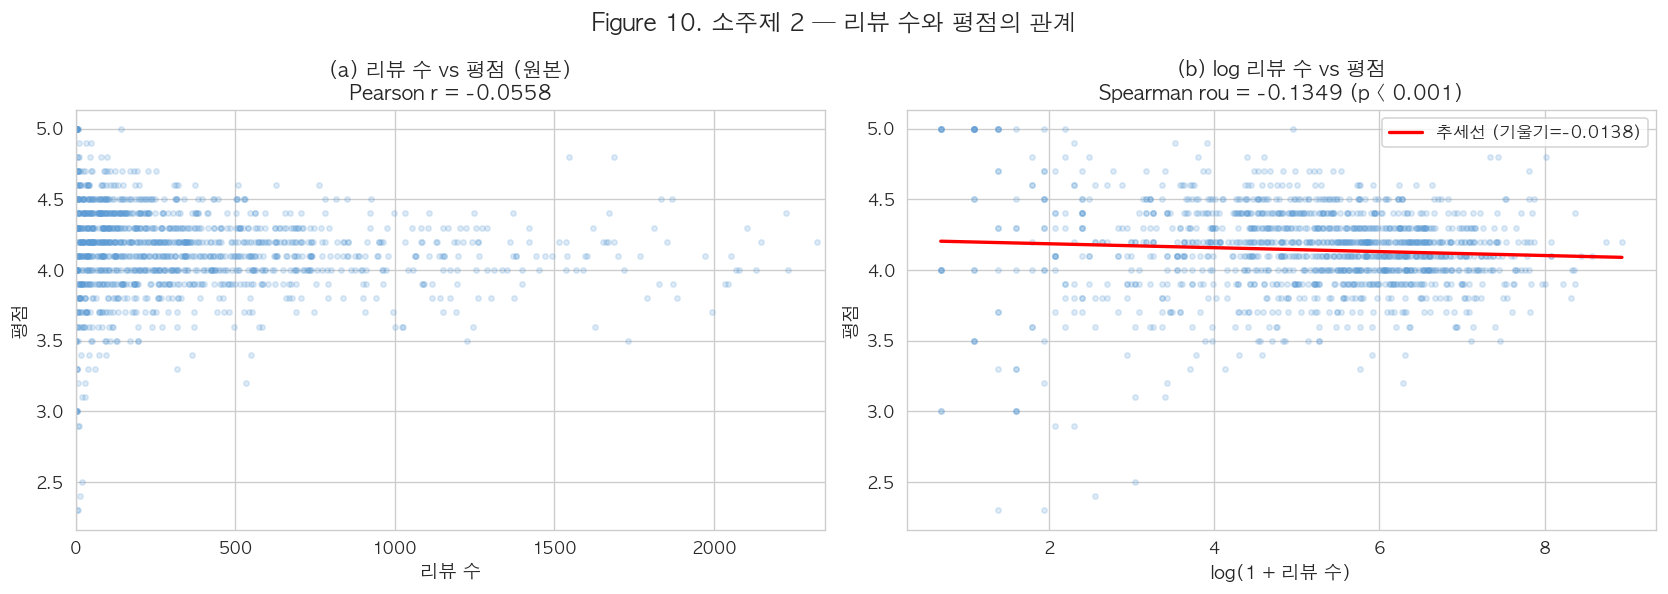

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# (a) 원본 스케일
axes[0].scatter(df["review_count"], df["rating"], alpha=0.2, s=10, color="#5B9BD5")
axes[0].set_xlabel("리뷰 수", fontsize=11)
axes[0].set_ylabel("평점", fontsize=11)
axes[0].set_title(f"(a) 리뷰 수 vs 평점 (원본)\nPearson r = {r_pearson:.4f}", fontsize=12)
axes[0].set_xlim(0, df["review_count"].quantile(0.98))
 
# (b) 로그 스케일 + 추세선
axes[1].scatter(df["log_review_count"], df["rating"], alpha=0.2, s=10, color="#5B9BD5")
# 추세선
z = np.polyfit(df["log_review_count"], df["rating"], 1)
p_line = np.poly1d(z)
x_line = np.linspace(df["log_review_count"].min(), df["log_review_count"].max(), 100)
axes[1].plot(x_line, p_line(x_line), color="red", linewidth=2, 
             label=f"추세선 (기울기={z[0]:.4f})")
axes[1].set_xlabel("log(1 + 리뷰 수)", fontsize=11)
axes[1].set_ylabel("평점", fontsize=11)
axes[1].set_title(f"(b) log 리뷰 수 vs 평점\nSpearman rou = {r_spearman:.4f} (p < 0.001)", fontsize=12)
axes[1].legend(fontsize=10)
 
plt.suptitle("Figure 10. 소주제 2 — 리뷰 수와 평점의 관계", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**해석:**  
- 산점도에서 뚜렷한 선형 관계는 보이지 않으나, **리뷰 수가 적은 영역에서 평점의 분산이 크다.**
- 리뷰가 많은 가게들은 평점이 4.0 부근에 밀집되어 있다.
- 이 패턴은 다음 섹션에서 구간별로 더 명확하게 확인한다.

### 2.3 리뷰 수 구간별 평점 분석

리뷰 수를 5개 구간으로 나누어 평점의 수준(평균)과 변동성(표준편차)을 비교한다.

In [66]:
# 구간별 기술통계
review_order = ["~50", "51~100", "101~300", "301~1000", "1000+"]
 
grp_stats = df.groupby("review_group", observed=True)["rating"].agg(
    ["count", "mean", "median", "std"]
).reindex(review_order).round(3)
grp_stats.columns = ["n", "평균", "중앙값", "표준편차"]
 
print("Table 4. 리뷰 수 구간별 평점 기술통계량")
print(grp_stats.to_string())
 
print(f"\n핵심 관찰:")
print(f"  평균: {grp_stats['평균'].iloc[0]:.3f} (~50건) → {grp_stats['평균'].iloc[-1]:.3f} (1000+건)")
print(f"  표준편차: {grp_stats['표준편차'].iloc[0]:.3f} (~50건) → {grp_stats['표준편차'].iloc[-1]:.3f} (1000+건)")
print(f"  -> 리뷰 수 증가에 따라 평점이 소폭 하락하고, 표준편차가 크게 감소")

Table 4. 리뷰 수 구간별 평점 기술통계량
                n     평균  중앙값   표준편차
review_group                        
~50           280  4.151  4.2  0.499
51~100        157  4.195  4.2  0.292
101~300       359  4.161  4.2  0.259
301~1000      424  4.118  4.1  0.214
1000+         145  4.092  4.1  0.240

핵심 관찰:
  평균: 4.151 (~50건) → 4.092 (1000+건)
  표준편차: 0.499 (~50건) → 0.240 (1000+건)
  -> 리뷰 수 증가에 따라 평점이 소폭 하락하고, 표준편차가 크게 감소


### 2.4 구간별 시각화 평점 수준과 분산

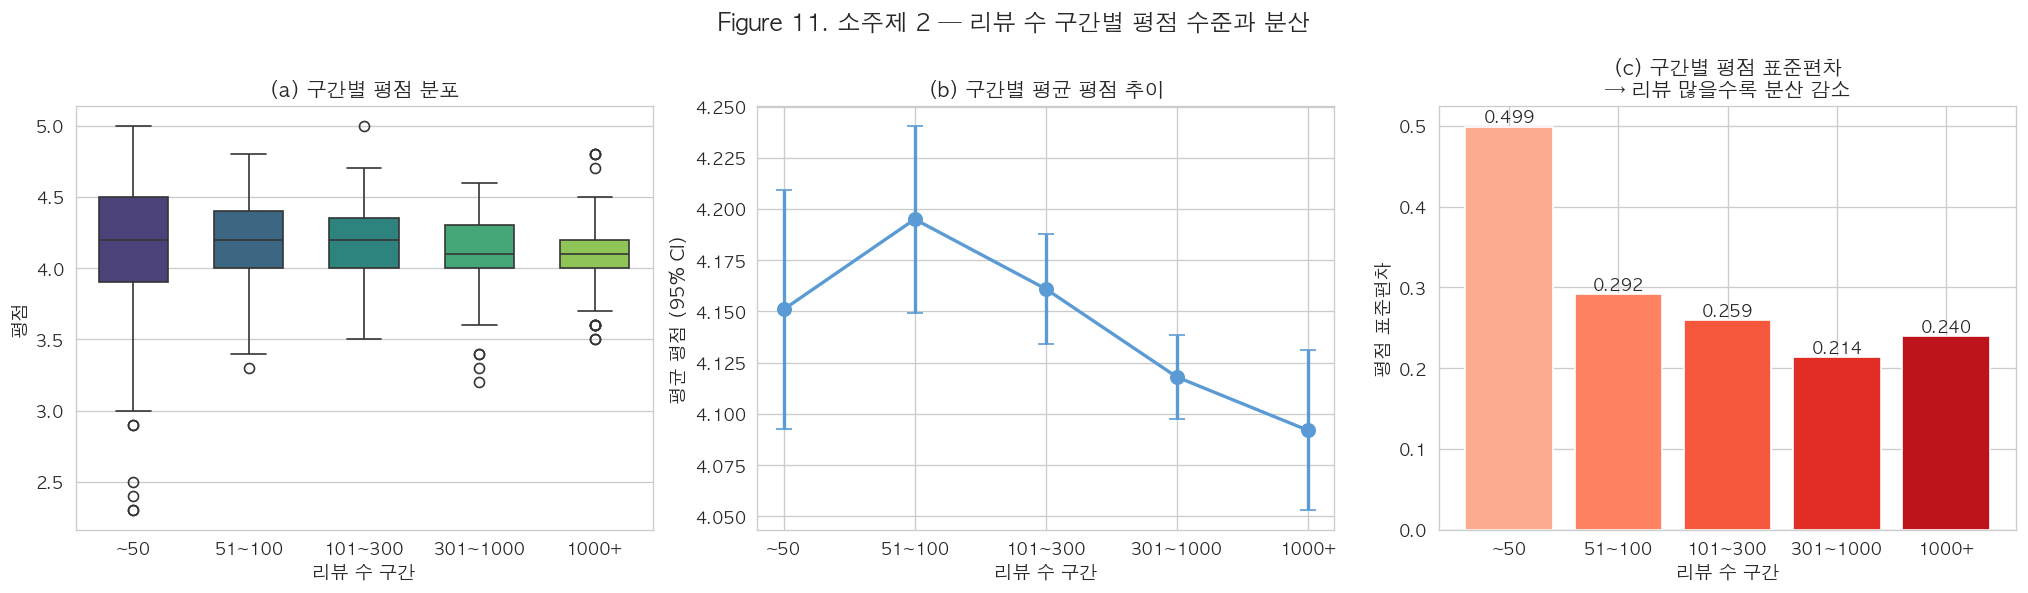

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
 
# (a) 구간별 박스플롯
sns.boxplot(data=df, x="review_group", y="rating", order=review_order,
            palette="viridis", ax=axes[0], width=0.6)
axes[0].set_xlabel("리뷰 수 구간", fontsize=11)
axes[0].set_ylabel("평점", fontsize=11)
axes[0].set_title("(a) 구간별 평점 분포", fontsize=12)
 
# (b) 구간별 평균 + 95% CI
means = grp_stats["평균"]
stds = grp_stats["표준편차"]
ns = grp_stats["n"]
sems = stds / np.sqrt(ns)
ci95 = sems * 1.96
 
axes[1].errorbar(range(len(review_order)), means, yerr=ci95, 
                 fmt="o-", color="#5B9BD5", linewidth=2, markersize=8, capsize=5)
axes[1].set_xticks(range(len(review_order)))
axes[1].set_xticklabels(review_order)
axes[1].set_xlabel("리뷰 수 구간", fontsize=11)
axes[1].set_ylabel("평균 평점 (95% CI)", fontsize=11)
axes[1].set_title("(b) 구간별 평균 평점 추이", fontsize=12)
 
# (c) 구간별 표준편차 (분산 비교) — 핵심!
colors_var = plt.cm.Reds(np.linspace(0.3, 0.8, len(review_order)))
bars = axes[2].bar(review_order, stds, color=colors_var, edgecolor="white")
for bar, val in zip(bars, stds):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.005, f"{val:.3f}", 
                 ha="center", fontsize=10, fontweight="bold")
axes[2].set_xlabel("리뷰 수 구간", fontsize=11)
axes[2].set_ylabel("평점 표준편차", fontsize=11)
axes[2].set_title("(c) 구간별 평점 표준편차\n→ 리뷰 많을수록 분산 감소", fontsize=12)
 
plt.suptitle("Figure 11. 소주제 2 — 리뷰 수 구간별 평점 수준과 분산", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.5 통계검정

In [92]:
# ── (1) 구간별 평점 수준 차이: Kruskal-Wallis ──
groups_data = [df[df["review_group"] == g]["rating"].dropna() for g in review_order]
 
kw_stat, kw_p = kruskal(*groups_data)
print("(1) 구간별 평점 수준 차이 (Kruskal-Wallis)")
print(f"  H_0: 리뷰 수 구간에 따라 평점 분포에 차이가 없다")
print(f"  H = {kw_stat:.4f}, p = {kw_p:.6f}")
print(f"  -> {'유의한 차이 있음' if kw_p < 0.05 else '유의하지 않음'} (alpha = 0.05)")
 
# 효과 크기
n_total = len(df)
eta_sq = (kw_stat - len(review_order) + 1) / (n_total - len(review_order))
print(f"  효과 크기 eta^2 ≈ {eta_sq:.4f} ({'작은' if eta_sq < 0.06 else '중간'} 효과)")
 
# ── (2) 구간별 분산 차이: Levene 검정 ──
lev_stat, lev_p = levene(*groups_data)
print(f"\n(2) 구간별 평점 분산 차이 (Levene)")
print(f"  H_0: 리뷰 수 구간에 따라 평점의 분산이 동일하다")
print(f"  F = {lev_stat:.4f}, p = {lev_p:.6f}")
print(f"  -> {'분산에 유의한 차이 있음' if lev_p < 0.05 else '유의하지 않음'} (alpha = 0.05)")
 
# ── (3) 사후 비교: 인접 구간끼리 ──
print(f"\n(3) 인접 구간 사후비교 (Mann-Whitney U)")
for i in range(len(review_order) - 1):
    g1_name = review_order[i]
    g2_name = review_order[i + 1]
    g1 = df[df["review_group"] == g1_name]["rating"]
    g2 = df[df["review_group"] == g2_name]["rating"]
    stat, p = mannwhitneyu(g1, g2, alternative="two-sided")
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
    print(f"  {g1_name} vs {g2_name}: U={stat:.0f}, p={p:.4f} {sig}  (평균: {g1.mean():.3f} vs {g2.mean():.3f})")

(1) 구간별 평점 수준 차이 (Kruskal-Wallis)
  H_0: 리뷰 수 구간에 따라 평점 분포에 차이가 없다
  H = 27.7242, p = 0.000014
  -> 유의한 차이 있음 (alpha = 0.05)
  효과 크기 eta^2 ≈ 0.0174 (작은 효과)

(2) 구간별 평점 분산 차이 (Levene)
  H_0: 리뷰 수 구간에 따라 평점의 분산이 동일하다
  F = 46.3276, p = 0.000000
  -> 분산에 유의한 차이 있음 (alpha = 0.05)

(3) 인접 구간 사후비교 (Mann-Whitney U)
  ~50 vs 51~100: U=21152, p=0.5122 n.s.  (평균: 4.151 vs 4.195)
  51~100 vs 101~300: U=31222, p=0.0494 *  (평균: 4.195 vs 4.161)
  101~300 vs 301~1000: U=84648, p=0.0063 **  (평균: 4.161 vs 4.118)
  301~1000 vs 1000+: U=33236, p=0.1396 n.s.  (평균: 4.118 vs 4.092)


소주제 2에서는 두 가지를 검정한다: 

(1) 리뷰 수 구간에 따라 평점의 수준(위치)이 다른가,

(2) 리뷰 수 구간에 따라 평점의 분산(변동성)이 다른가.


**(1) 구간별 평점 수준 차이 (Kruskal-Wallis)**

귀무가설은 "다섯 개 리뷰 수 구간(~50, 51~100, 101~300, 301~1000, 1000+)의 평점 분포가 동일하다"이다. 

검정 결과 $H=27.72$, $\rho<0.001$로, 리뷰 수 구간에 따라 평점 분포에 통계적으로 유의한 차이가 존재한다. 

효과 크기는 $\eta^2≈0.017$로 작은 효과에 해당하지만, 소주제 1의 가격대 효과($\eta^2=0.004$)보다는 약 4배 큰 값이다. 

이는 가격대보다 리뷰 수가 평점 변동을 상대적으로 더 많이 설명한다는 의미이다.


**(2) 구간별 평점 분산 차이 (Levene)**

귀무가설은 "다섯 개 구간의 평점 분산이 동일하다"이다. 

검정 결과 $F=46.33$, $p<0.001$로, 구간 간 분산에 매우 유의한 차이가 존재한다. 

이는 리뷰가 적은 구간(~50건, σ=0.499)과 많은 구간(1000+건, $\sigma=0.240$)의 표준편차가 약 2배 차이 나는 것에서 기인한다. 

Kruskal-Wallis보다 Levene의 p-value가 훨씬 작다는 점은 리뷰 수의 증가가 평점의 수준(높고 낮음)보다 평점의 **안정성(분산 감소)**에 더 뚜렷한 영향을 미친다는 것을 시사한다.


**(3) 인접 구간 사후비교 (Mann-Whitney U)**
어떤 구간 경계에서 평점의 변화가 나타나는지를 확인하기 위해, 인접한 구간끼리 Mann-Whitney U 검정을 수행하였다.

~50건과 51~100건 사이에서는 유의한 차이가 없었다($p=0.512$). 

그러나 51~100건에서 101~300건으로 넘어가는 구간($p=0.049$)과 101~300건에서 301~1000건으로 넘어가는 구간($p=0.006$)에서 유의한 평점 하락이 관찰되었다. 301~1000건과 1000+건 사이에서는 다시 유의한 차이가 사라졌다($p=0.140$).


이를 종합하면, 평점의 의미 있는 변화는 주로 리뷰 100~1,000건 구간에서 발생한다. 리뷰가 100건 미만인 초기 단계에서는 소수의 긍정적 리뷰에 의해 평점이 과대 추정되어 있다가, 리뷰가 100건을 넘으면서 다양한 평가가 유입되어 평점이 점진적으로 하락하고 안정화되는 것으로 해석된다. 1,000건을 넘으면 이미 충분히 수렴한 상태이므로 추가적인 변화가 미미하다.

### 2.6 대수의 법칙 관점 시각화

통계학의 대수의 법칙에 의하면, 표본 크기가 증가하면 표본평균의 변동성이 감소하여 모평균에 수렴한다.

이를 실증적으로 확인한다.

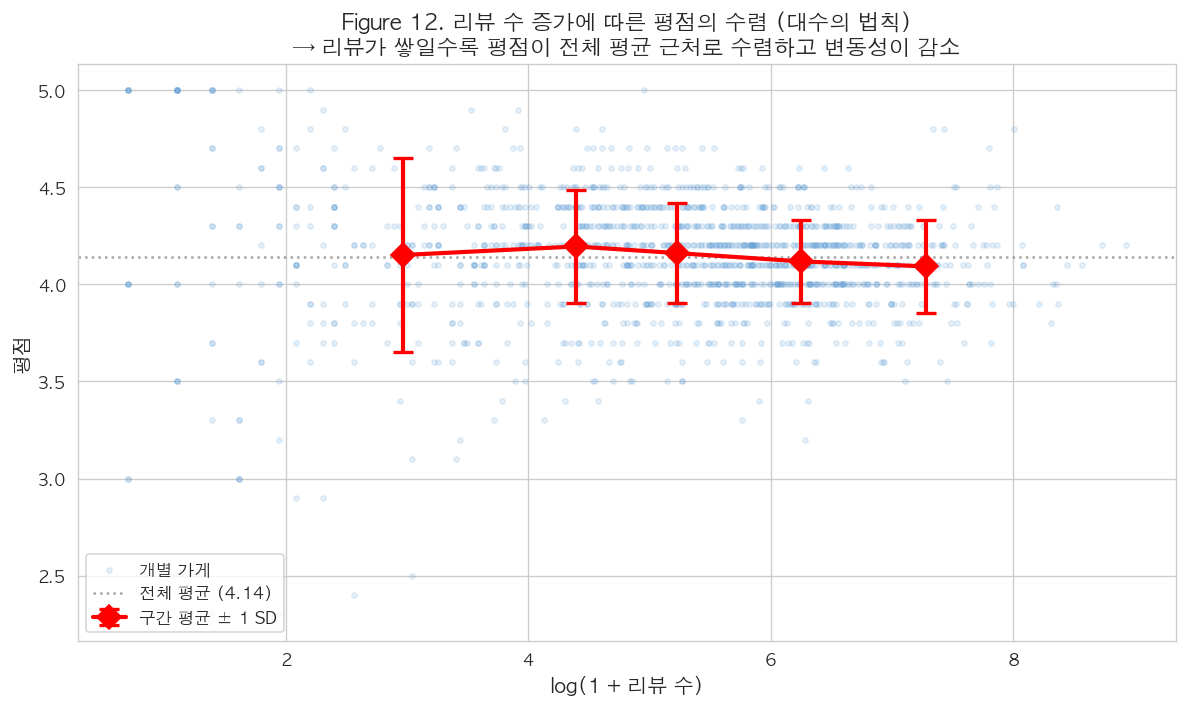

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
 
# 리뷰 수별 평점 산점도 (로그 스케일)
scatter = ax.scatter(df["log_review_count"], df["rating"], 
                     alpha=0.15, s=10, color="#5B9BD5", label="개별 가게")
 
# 구간별 평균 + 표준편차 범위
midpoints = []
for g in review_order:
    sub = df[df["review_group"] == g]
    mid_log = sub["log_review_count"].median()
    midpoints.append(mid_log)
 
grp_means = [df[df["review_group"] == g]["rating"].mean() for g in review_order]
grp_stds = [df[df["review_group"] == g]["rating"].std() for g in review_order]
 
ax.errorbar(midpoints, grp_means, yerr=grp_stds, fmt="D-", color="red", 
            linewidth=2.5, markersize=10, capsize=6, capthick=2,
            label="구간 평균 ± 1 SD", zorder=5)
 
# 전체 평균선
ax.axhline(df["rating"].mean(), color="gray", linestyle=":", alpha=0.7,
           label=f'전체 평균 ({df["rating"].mean():.2f})')
 
ax.set_xlabel("log(1 + 리뷰 수)", fontsize=12)
ax.set_ylabel("평점", fontsize=12)
ax.set_title("Figure 12. 리뷰 수 증가에 따른 평점의 수렴 (대수의 법칙)\n"
             "-> 리뷰가 쌓일수록 평점이 전체 평균 근처로 수렴하고 변동성이 감소",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10, loc="lower left")
 
plt.tight_layout()
plt.show()

### 2.7 소주제 2 결론


| 항목 | 결과 |
|------|------|
| 상관관계 | Spearman $\rho$ = -0.135 ($p < 0.001$), 약한 음의 상관 |
| 구간별 평점 차이 | Kruskal-Wallis $H = 27.72$, $p < 0.001$ -> 유의 |
| 구간별 분산 차이 | Levene $F = 46.33$, $p < 0.001$ -> 유의 |
| 효과 크기 | $\eta^2 ≈ 0.017$ (작은 효과) |
 
**해석:**
 
 1. **평점 수준:** 리뷰 수가 많을수록 평점이 **소폭 하락**하는 경향이 있다  
    (~50건: 4.151 → 1000+건: 4.092). 이는 리뷰가 적은 가게에서  
    소수의 긍정적 리뷰만 있을 때 평점이 과대 추정되는 효과로 해석된다.
 
 2. **평점 안정성:** 리뷰 수가 많을수록 평점의 표준편차가 **크게 감소**한다  
    (~50건: 0.499 -> 1000+건: 0.240). 이는 **대수의 법칙**과 일치하는  
    결과로, 리뷰(표본)가 축적될수록 평점(표본평균)이 안정화됨을 실증적으로 보여준다.
 
 3. **실용적 시사점:** 리뷰 수가 매우 적은 가게(~50건)의 평점은 변동성이 커서  
    신뢰도가 낮을 수 있으며, 최소 100건 이상의 리뷰가 있어야 평점이 안정적이라 할 수 있다.

----

## 소주제 3. 부산 내 행정구별로 평점 분포에 차이가 있는가?

부산관역시는 15개 구와 1개 군(기장군)으로 구성되어 있다.

이 소주제에서는 행정구(위치)에 따라 카페/음식점의 평점 분포가 달라지는지 분석한다.

**가설**
- $H_0$: 16개 행정구의 평점 분포가 모두 동일하다
- $H_1$: 적어도 하나의 행정구에서 평점 분포가 다르다

### 3.1 행정구별 기술통계

In [70]:
from scipy.stats import kruskal, mannwhitneyu, shapiro, levene, f_oneway

In [71]:
# 행정구별 기술통계 (평균 순 정렬)
district_stats = df.groupby("district")["rating"].agg(
    ["count", "mean", "median", "std"]
).round(3).sort_values("mean", ascending=False)
district_stats.columns = ["n", "평균", "중앙값", "표준편차"]
 
print("Table 5. 행정구별 평점 기술통계량 (평균 내림차순)")
print(district_stats.to_string())
 
print(f"\n전체 평균: {df['rating'].mean():.3f}")
print(f"행정구 간 평균의 범위: {district_stats['평균'].min():.3f} ~ {district_stats['평균'].max():.3f}")
print(f"행정구 간 평균의 차이: {district_stats['평균'].max() - district_stats['평균'].min():.3f}")

Table 5. 행정구별 평점 기술통계량 (평균 내림차순)
            n     평균  중앙값   표준편차
district                        
강서구        60  4.212  4.2  0.293
금정구       119  4.180  4.2  0.294
남구        103  4.176  4.2  0.323
영도구        53  4.174  4.2  0.251
해운대구      158  4.167  4.2  0.311
부산진구      171  4.160  4.2  0.289
사하구        80  4.152  4.2  0.396
중구         61  4.151  4.1  0.269
수영구        69  4.149  4.2  0.329
연제구        51  4.139  4.2  0.268
서구         57  4.137  4.1  0.292
북구         56  4.134  4.1  0.350
기장군        83  4.113  4.1  0.281
동래구        94  4.091  4.1  0.292
사상구        87  4.062  4.1  0.360
동구         63  4.022  4.1  0.397

전체 평균: 4.142
행정구 간 평균의 범위: 4.022 ~ 4.212
행정구 간 평균의 차이: 0.190


**해석:**
- 평균 평점이 가장 높은 구는 **강서구(4.212)**, 가장 낮은 구는 동구(4.022)이다.
- 16개 행정구의 평균 평점 범위는 4.022~4.212로, **차이가 0.190**에 불과하다.
- 이는 부산 전체적으로 음식점/카페 평점이 비교적 **균질**함을 시사한다.
- 표본 크기는 최소 51개(연제구)~최대 171개(부산진구)로 분석에 충분하다.

### 3.2 행정구별 평점 분포 시각화

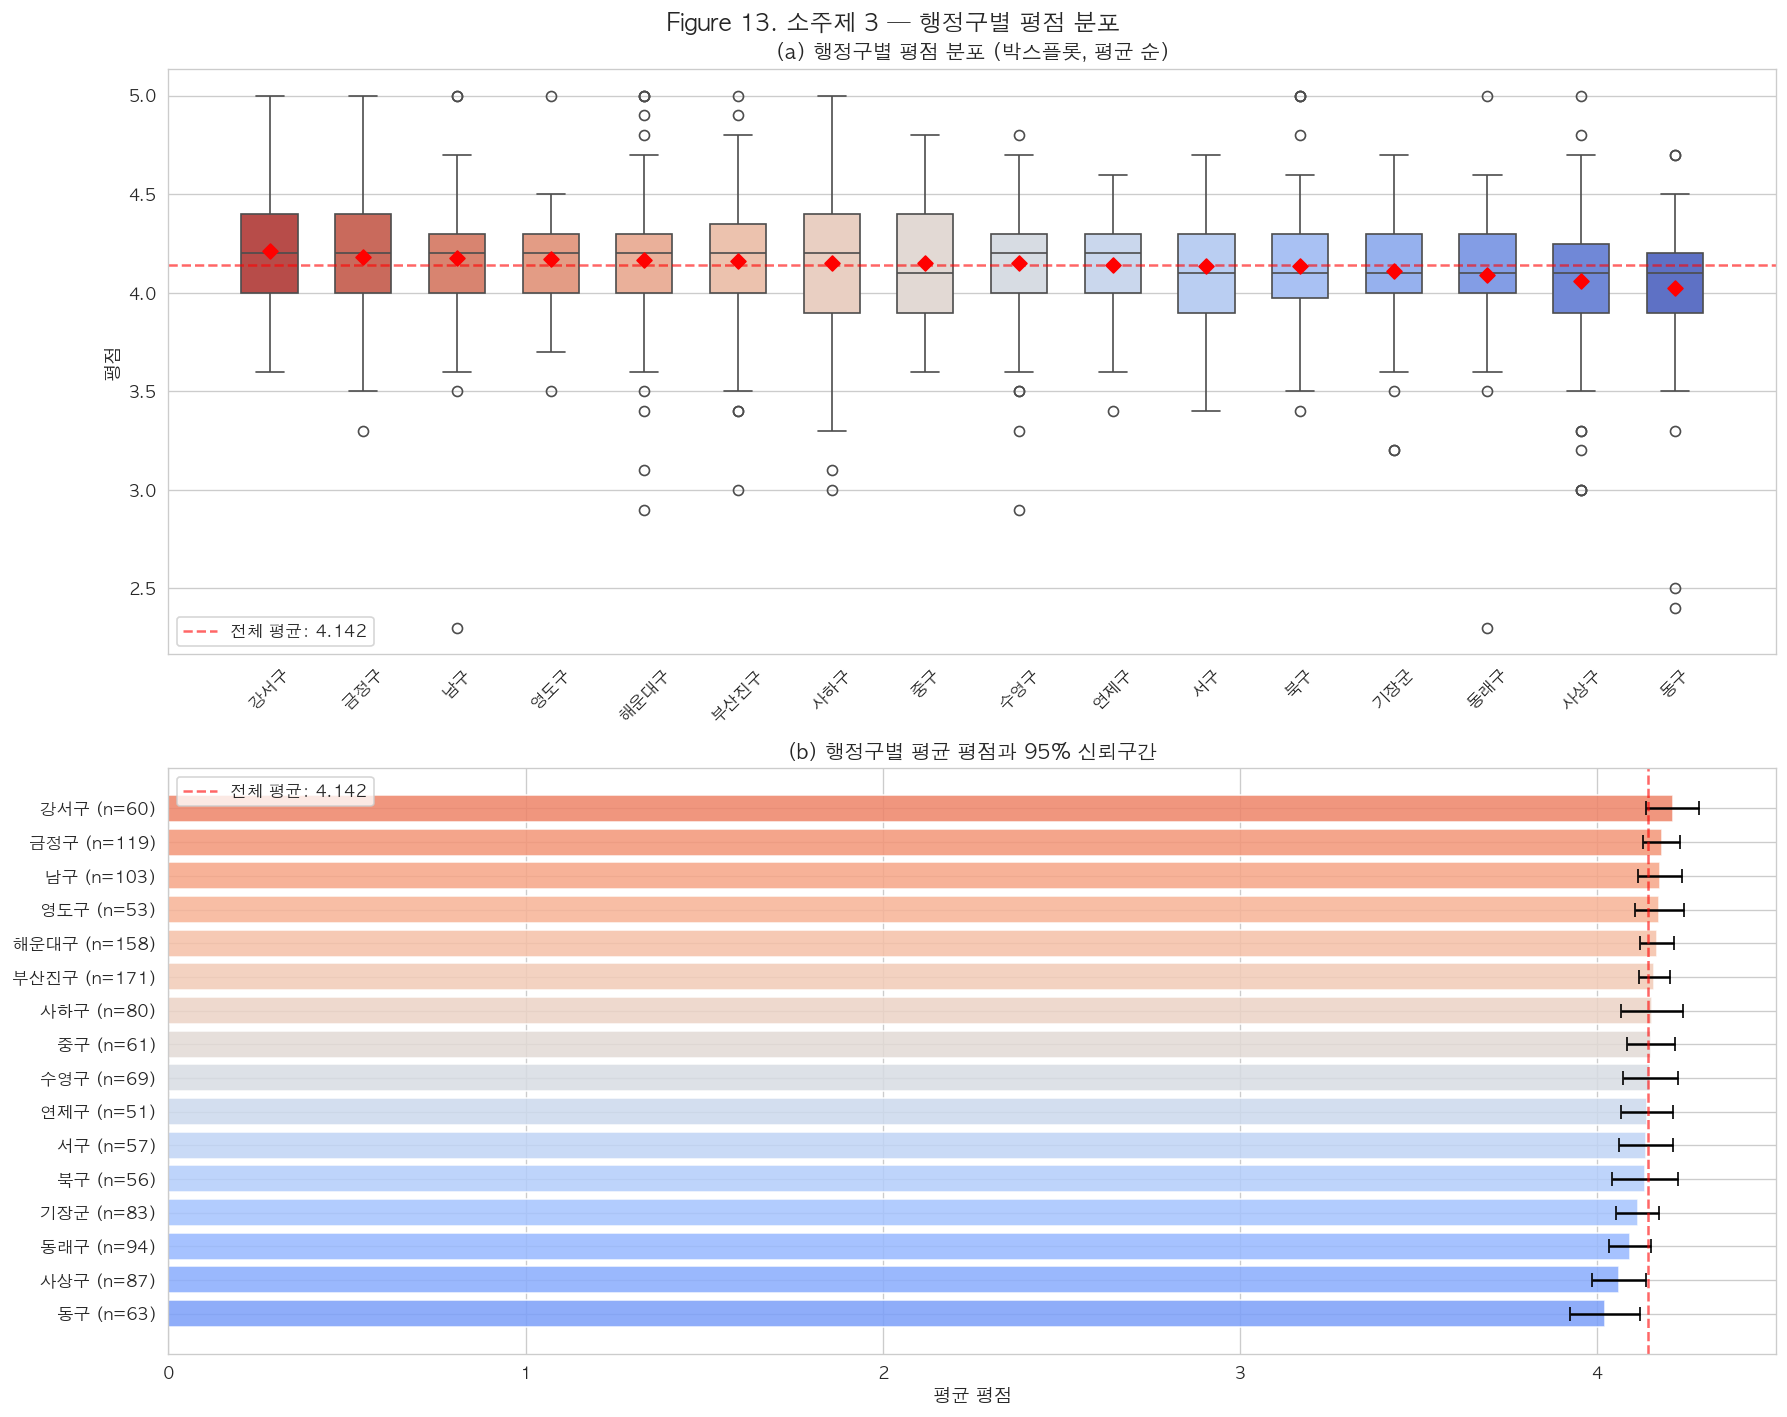

In [72]:
district_order = district_stats.index.tolist()  # 평균 순
 
fig, axes = plt.subplots(2, 1, figsize=(15, 12))
 
# (a) 박스플롯
sns.boxplot(data=df, x="district", y="rating", order=district_order,
            palette="coolwarm_r", ax=axes[0], width=0.6)
axes[0].axhline(df["rating"].mean(), color="red", linestyle="--", alpha=0.6,
                label=f'전체 평균: {df["rating"].mean():.3f}')
# 각 구 평균 마커
for i, d in enumerate(district_order):
    mean_val = df[df["district"] == d]["rating"].mean()
    axes[0].scatter(i, mean_val, color="red", s=40, zorder=5, marker="D")
axes[0].set_xlabel("")
axes[0].set_ylabel("평점", fontsize=11)
axes[0].set_title("(a) 행정구별 평점 분포 (박스플롯, 평균 순)", fontsize=12)
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(fontsize=10)
 
# (b) 평균 + 95% 신뢰구간
dist_ci = district_stats.copy()
dist_ci["se"] = dist_ci["표준편차"] / np.sqrt(dist_ci["n"])
dist_ci["ci95"] = dist_ci["se"] * 1.96
dist_ci_sorted = dist_ci.sort_values("평균", ascending=True)
 
colors_bar = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(dist_ci_sorted)))
axes[1].barh(range(len(dist_ci_sorted)), dist_ci_sorted["평균"],
             xerr=dist_ci_sorted["ci95"], color=colors_bar, edgecolor="white",
             capsize=4, alpha=0.85)
axes[1].set_yticks(range(len(dist_ci_sorted)))
axes[1].set_yticklabels([f"{d} (n={int(dist_ci_sorted.loc[d, 'n'])})" for d in dist_ci_sorted.index])
axes[1].axvline(df["rating"].mean(), color="red", linestyle="--", alpha=0.6,
                label=f'전체 평균: {df["rating"].mean():.3f}')
axes[1].set_xlabel("평균 평점", fontsize=11)
axes[1].set_title("(b) 행정구별 평균 평점과 95% 신뢰구간", fontsize=12)
axes[1].legend(fontsize=10)
 
plt.suptitle("Figure 13. 소주제 3 — 행정구별 평점 분포", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**해석:**
- **(a) 박스플롯:** 행정구별 중앙값(4.1~4.2)과 사분위 범위가 대부분 겹치고 있어,시각적으로 큰 차이를 확인하기 어렵다. 다만 동구, 사상구는 다른 구에 비해 분산(상자 크기)이 큰 편이다.

- **(b) 신뢰구간:** 대부분의 행정구에서 95% 신뢰구간이 **전체 평균(4.142)을 포함**하고 있다. 강서구와 동구만 신뢰구간이 전체 평균에서 약간 벗어나 있으나, 다른 구들의 신뢰구간과는 여전히 상당 부분 겹친다.

### 3.3 검정 가정 확인

In [93]:
# ── 정규성 ──
print("정규성 검정 (Shapiro-Wilk, 각 행정구)")
non_normal = 0
for d in district_order:
    g = df[df["district"] == d]["rating"]
    sample = g.sample(min(500, len(g)), random_state=42) if len(g) > 500 else g
    stat, p = shapiro(sample)
    is_normal = p >= 0.05
    if not is_normal:
        non_normal += 1
    print(f"  {d:<6s} (n={len(g):>3d}): W={stat:.4f}, p={p:.4f} -> {'정규' if is_normal else '비정규'}")
 
print(f"\n  비정규 분포 행정구: {non_normal}/16개")
print(f"  -> 과반수가 비정규이므로 비모수 검정(Kruskal-Wallis) 사용")
 
# ── 등분산성 ──
district_groups = [df[df["district"] == d]["rating"].values for d in district_order]
lev_stat, lev_p = levene(*district_groups)
print(f"\n등분산성 검정 (Levene)")
print(f"  F = {lev_stat:.4f}, p = {lev_p:.6f}")
print(f"  -> {'등분산' if lev_p >= 0.05 else '이분산'}")

정규성 검정 (Shapiro-Wilk, 각 행정구)
  강서구    (n= 60): W=0.9746, p=0.2427 -> 정규
  금정구    (n=119): W=0.9662, p=0.0044 -> 비정규
  남구     (n=103): W=0.8655, p=0.0000 -> 비정규
  영도구    (n= 53): W=0.9583, p=0.0618 -> 정규
  해운대구   (n=158): W=0.9509, p=0.0000 -> 비정규
  부산진구   (n=171): W=0.9747, p=0.0033 -> 비정규
  사하구    (n= 80): W=0.9689, p=0.0486 -> 비정규
  중구     (n= 61): W=0.9649, p=0.0777 -> 정규
  수영구    (n= 69): W=0.9329, p=0.0011 -> 비정규
  연제구    (n= 51): W=0.9623, p=0.1050 -> 정규
  서구     (n= 57): W=0.9782, p=0.3905 -> 정규
  북구     (n= 56): W=0.9583, p=0.0506 -> 정규
  기장군    (n= 83): W=0.9396, p=0.0007 -> 비정규
  동래구    (n= 94): W=0.8129, p=0.0000 -> 비정규
  사상구    (n= 87): W=0.9239, p=0.0001 -> 비정규
  동구     (n= 63): W=0.8330, p=0.0000 -> 비정규

  비정규 분포 행정구: 10/16개
  -> 과반수가 비정규이므로 비모수 검정(Kruskal-Wallis) 사용

등분산성 검정 (Levene)
  F = 1.2630, p = 0.218160
  -> 등분산


### 3.4 통계검정

In [ ]:
# ── Kruskal-Wallis 검정 ──
kw_stat, kw_p = kruskal(*district_groups)
 
print("Kruskal-Wallis 검정")
print(f"  H_0: 16개 행정구의 평점 분포가 모두 동일하다")
print(f"  H_1: 적어도 하나의 행정구에서 평점 분포가 다르다")
print(f"  alpha = 0.05")
print(f"")
print(f"  검정통계량 H = {kw_stat:.4f}")
print(f"  p-value     = {kw_p:.6f}")
 
if kw_p < 0.05:
    print(f"  결론: p = {kw_p:.4f} < 0.05 → H_1 기각. 행정구별 평점에 유의한 차이가 있다.")
else:
    print(f"  결론: p = {kw_p:.4f} ≥ 0.05 → H_0 기각 불가.")
    print(f"         16개 행정구 전체를 동시에 비교했을 때,")
    print(f"         통계적으로 유의한 차이를 발견할 수 없다.")
 
# 효과 크기
n_total = len(df)
k = 16
eta_sq = (kw_stat - k + 1) / (n_total - k)
print(f"\n  효과 크기 eta² ≈ {eta_sq:.4f} ({'작은 효과' if eta_sq < 0.06 else '중간 효과'})")
 
# ── ANOVA (참고) ──
f_stat, f_p = f_oneway(*district_groups)
print(f"\n[참고] One-way ANOVA: F = {f_stat:.4f}, p = {f_p:.6f}")

Kruskal-Wallis 검정
  H_0: 16개 행정구의 평점 분포가 모두 동일하다
  H_1: 적어도 하나의 행정구에서 평점 분포가 다르다
  alpha = 0.05

  검정통계량 H = 22.8635
  p-value     = 0.087082
  결론: p = 0.0871 ≥ 0.05 → H_0 기각 불가.
         16개 행정구 전체를 동시에 비교했을 때,
         통계적으로 유의한 차이를 발견할 수 없다.

  효과 크기 eta² ≈ 0.0058 (작은 효과)

[참고] One-way ANOVA: F = 1.7417, p = 0.038019


**해석:**
 
Kruskal-Wallis 검정 결과 $p = 0.087$로, **유의수준 0.05에서 $H_1$를 기각할 수 없다.** 즉, 16개 행정구의 평점 분포가 **전체적으로 동일하다**는 귀무가설을 유지한다.
 
이 결과는 다음과 같이 해석할 수 있다:
- 부산 지역 카페/음식점의 평점은 행정구에 관계없이 **비교적 균질**하다.
- 특정 행정구가 "맛집 구"이거나 "평점이 낮은 구"라고 단정짓기 어렵다.
- 16개 그룹을 동시에 비교하면 검정의 보수성이 높아져, 실제로 존재할 수 있는 **부분적 차이**를 탐지하지 못했을 가능성도 있다.


### 3.5 추가 분석: 상위 행정구 vs 하위 행정구  --> 이놈은 굳이?

In [75]:
# 평균 평점 기준 상위 5개 / 하위 5개
top5 = district_stats.head(5).index.tolist()
bot5 = district_stats.tail(5).index.tolist()
 
top5_ratings = df[df["district"].isin(top5)]["rating"]
bot5_ratings = df[df["district"].isin(bot5)]["rating"]
 
stat_tb, p_tb = mannwhitneyu(top5_ratings, bot5_ratings, alternative="two-sided")
 
# 효과 크기 (rank-biserial)
n1, n2 = len(top5_ratings), len(bot5_ratings)
r_effect = 1 - (2 * stat_tb) / (n1 * n2)
 
print("추가 분석: 상위 5개구 vs 하위 5개구")
print(f"  상위 5개구: {', '.join(top5)}")
print(f"    n = {len(top5_ratings)}, 평균 = {top5_ratings.mean():.3f}, 중앙값 = {top5_ratings.median()}")
print(f"  하위 5개구: {', '.join(bot5)}")
print(f"    n = {len(bot5_ratings)}, 평균 = {bot5_ratings.mean():.3f}, 중앙값 = {bot5_ratings.median()}")
print(f"")
print(f"  Mann-Whitney U = {stat_tb:.0f}")
print(f"  p-value = {p_tb:.6f}")
print(f"  효과 크기 r = {r_effect:.4f}")
print(f"  → {'유의한 차이 있음' if p_tb < 0.05 else '유의하지 않음'}")
 
if p_tb < 0.05:
    print(f"\n  해석:")
    print(f"    16개 행정구 전체 비교에서는 유의하지 않았으나,")
    print(f"    평균 평점 상위 5개구와 하위 5개구를 비교하면 유의한 차이가 나타난다.")
    print(f"    상위 5개구의 평균({top5_ratings.mean():.3f})이 하위 5개구({bot5_ratings.mean():.3f})보다")
    print(f"    {top5_ratings.mean() - bot5_ratings.mean():.3f}점 높다.")

추가 분석: 상위 5개구 vs 하위 5개구
  상위 5개구: 강서구, 금정구, 남구, 영도구, 해운대구
    n = 493, 평균 = 4.178, 중앙값 = 4.2
  하위 5개구: 북구, 기장군, 동래구, 사상구, 동구
    n = 383, 평균 = 4.084, 중앙값 = 4.1

  Mann-Whitney U = 110572
  p-value = 0.000012
  효과 크기 r = -0.1712
  → 유의한 차이 있음

  해석:
    16개 행정구 전체 비교에서는 유의하지 않았으나,
    평균 평점 상위 5개구와 하위 5개구를 비교하면 유의한 차이가 나타난다.
    상위 5개구의 평균(4.178)이 하위 5개구(4.084)보다
    0.094점 높다.


### 3.6 추가 분석 시각화

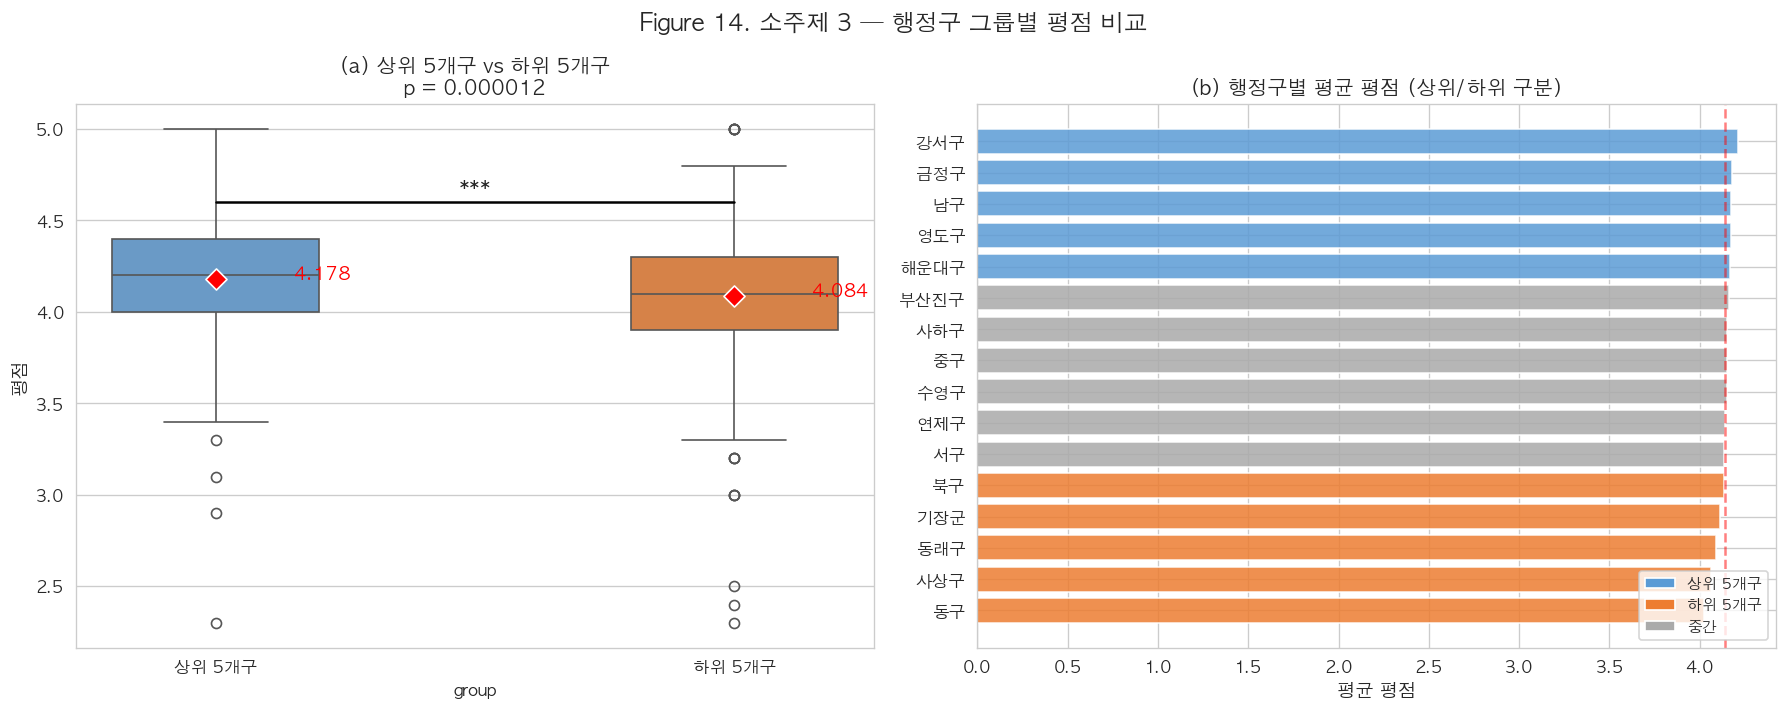

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
 
# (a) 상위 5 vs 하위 5 비교
df_topbot = df.copy()
df_topbot["group"] = df_topbot["district"].apply(
    lambda x: "상위 5개구" if x in top5 else ("하위 5개구" if x in bot5 else "중간")
)
df_topbot_filtered = df_topbot[df_topbot["group"] != "중간"]
 
sns.boxplot(data=df_topbot_filtered, x="group", y="rating", 
            order=["상위 5개구", "하위 5개구"],
            palette=["#5B9BD5", "#ED7D31"], ax=axes[0], width=0.4)
 
for i, grp in enumerate(["상위 5개구", "하위 5개구"]):
    mean_val = df_topbot_filtered[df_topbot_filtered["group"] == grp]["rating"].mean()
    axes[0].scatter(i, mean_val, color="red", s=80, zorder=5, marker="D", edgecolors="white")
    axes[0].text(i + 0.15, mean_val, f"{mean_val:.3f}", color="red", fontsize=11, fontweight="bold")
 
# 유의성 표시
y_max = 4.6
if p_tb < 0.05:
    axes[0].plot([0, 1], [y_max, y_max], color="black", linewidth=1.5)
    sig_mark = "***" if p_tb < 0.001 else ("**" if p_tb < 0.01 else "*")
    axes[0].text(0.5, y_max + 0.02, sig_mark, ha="center", fontsize=14, fontweight="bold")
 
axes[0].set_ylabel("평점", fontsize=11)
axes[0].set_title(f"(a) 상위 5개구 vs 하위 5개구\np = {p_tb:.6f}", fontsize=12)
 
# (b) 행정구별 평균 (상위/하위 색 구분)
dist_mean_sorted = district_stats.sort_values("평균", ascending=True)
colors_district = []
for d in dist_mean_sorted.index:
    if d in top5:
        colors_district.append("#5B9BD5")
    elif d in bot5:
        colors_district.append("#ED7D31")
    else:
        colors_district.append("#AAAAAA")
 
axes[1].barh(range(len(dist_mean_sorted)), dist_mean_sorted["평균"],
             color=colors_district, edgecolor="white", alpha=0.85)
axes[1].set_yticks(range(len(dist_mean_sorted)))
axes[1].set_yticklabels(dist_mean_sorted.index)
axes[1].axvline(df["rating"].mean(), color="red", linestyle="--", alpha=0.5,
                label=f'전체 평균: {df["rating"].mean():.3f}')
 
# 범례
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#5B9BD5", label="상위 5개구"),
                   Patch(facecolor="#ED7D31", label="하위 5개구"),
                   Patch(facecolor="#AAAAAA", label="중간")]
axes[1].legend(handles=legend_elements, fontsize=9, loc="lower right")
axes[1].set_xlabel("평균 평점", fontsize=11)
axes[1].set_title("(b) 행정구별 평균 평점 (상위/하위 구분)", fontsize=12)
 
plt.suptitle("Figure 14. 소주제 3 — 행정구 그룹별 평점 비교", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.7 업종별 행정구 패턴

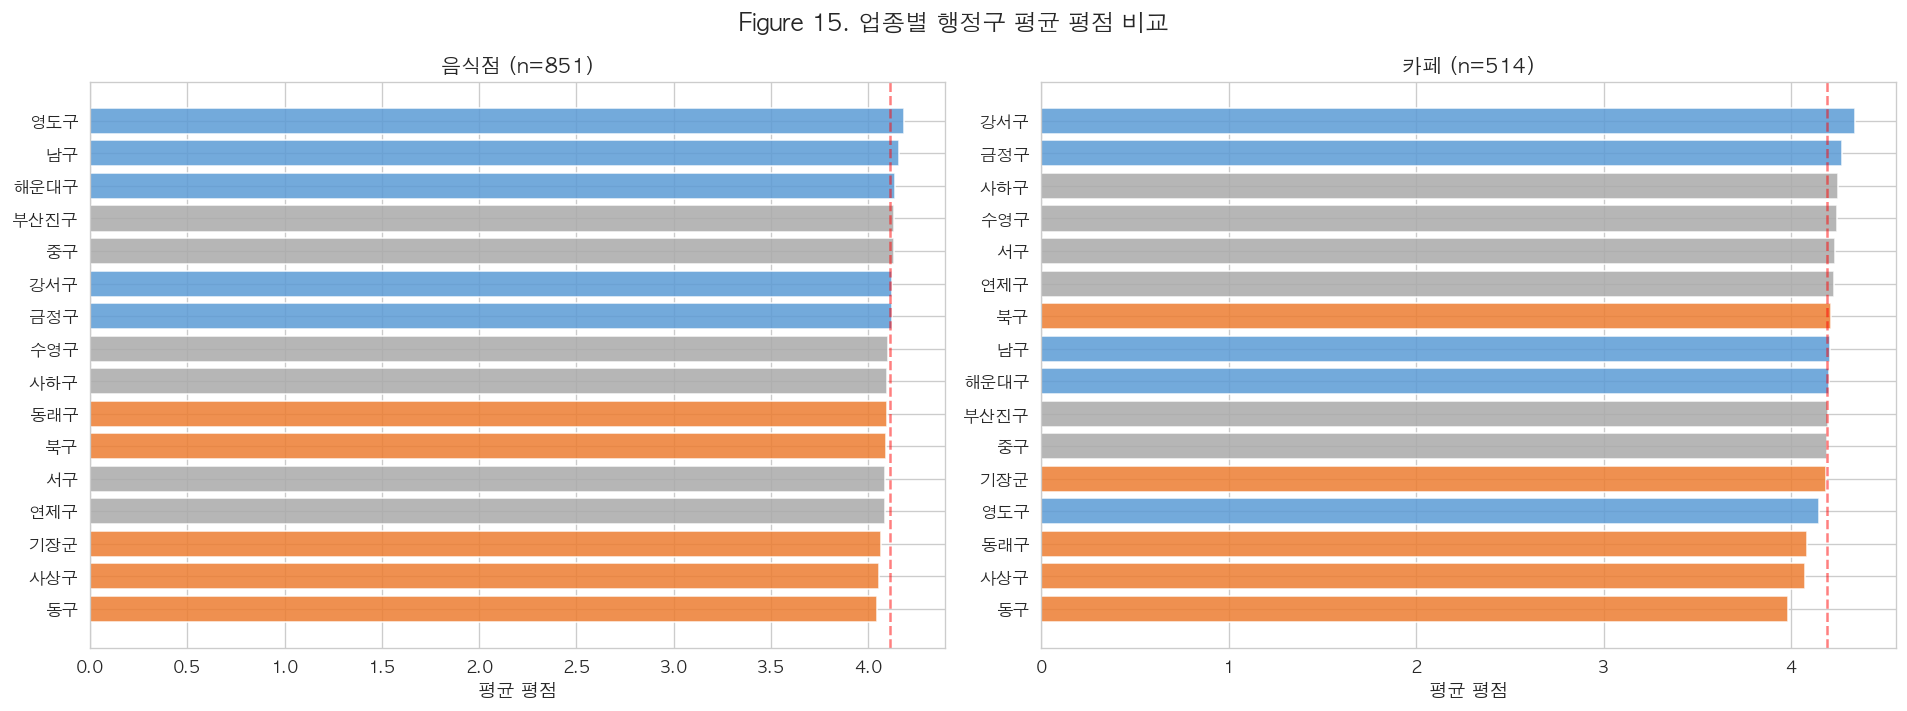

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
for i, bt in enumerate(["음식점", "카페"]):
    sub = df[df["business_type"] == bt]
    d_mean = sub.groupby("district")["rating"].mean().sort_values(ascending=True)
    
    colors_bt = ["#5B9BD5" if d in top5 else ("#ED7D31" if d in bot5 else "#AAAAAA") for d in d_mean.index]
    axes[i].barh(range(len(d_mean)), d_mean.values, color=colors_bt, edgecolor="white", alpha=0.85)
    axes[i].set_yticks(range(len(d_mean)))
    axes[i].set_yticklabels(d_mean.index)
    axes[i].axvline(sub["rating"].mean(), color="red", linestyle="--", alpha=0.5)
    axes[i].set_xlabel("평균 평점", fontsize=11)
    axes[i].set_title(f"{bt} (n={len(sub)})", fontsize=12)
 
plt.suptitle("Figure 15. 업종별 행정구 평균 평점 비교", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**해석:**
- 음식점과 카페의 행정구별 순위가 **완전히 일치하지는 않는다.**
- 예를 들어, 음식점에서 평점이 높은 구가 카페에서는 중간 수준일 수 있다.
- 이는 행정구의 특성(관광지, 주거지, 상업지구 등)이 업종에 따라 **다르게 작용**할 수 있음을 시사하며, 소주제 4(업종별 분석)에서 더 살펴본다.

### 3.8 소주제 3 결론
 
 | 항목 | 결과 |
 |------|------|
 | 검정 방법 | Kruskal-Wallis (비모수) |
 | 검정통계량 | $H = 22.86$ |
 | p-value | 0.087 |
 | 결론 (전체) | 16개 행정구 전체 비교 시 **유의한 차이 없음** ($p ≥ 0.05$) |
 | 추가 분석 | 상위 5개구 vs 하위 5개구 비교 시 **유의한 차이 있음** ($p < 0.001$) |
 | 효과 크기 | 작은 효과 |
 
 **해석:**
 
 1. **전체 비교(16개 구 동시):** 유의한 차이가 발견되지 않았다 ($p = 0.087$).  
    이는 부산 지역의 카페/음식점 평점이 행정구에 관계없이 **비교적 균질**함을 의미한다.  
    즉, 특정 행정구가 "맛집 동네"이거나 "평점이 낮은 동네"라고 단정짓기 어렵다.
 
 2. **부분 비교(상위 vs 하위):** 평균 평점 상위 5개구(강서, 금정, 남, 영도, 해운대)와  
    하위 5개구(기장, 동래, 사상, 동, 북)를 비교하면 **유의한 차이**가 나타난다.  
    이는 극단적인 그룹 간에는 차이가 존재하지만, 전체 16개 구를 동시에 보면  
    중간 그룹들이 차이를 희석시키기 때문으로 해석된다.
 
 3. **실용적 시사점:** 부산에서 카페/음식점의 평점은 위치(행정구)보다는  
    개별 가게의 특성(맛, 서비스 등)에 더 크게 좌우되는 것으로 보인다.  
    다만, 동구·사상구 등 상대적으로 평점이 낮은 지역이 존재하며,  
    이는 해당 지역의 상권 특성이나 고객층의 차이에 기인할 수 있다.
 
 4. **방법론적 시사점:** Kruskal-Wallis는 16개 그룹을 동시에 비교하므로  
    보수적인 결과를 낸다. $p = 0.087$은 유의수준 0.10에서는  
    유의하며, 표본이 더 크거나 그룹 수가 적었다면 유의했을 가능성이 있다.  
    "유의하지 않다"는 것이 "차이가 없다"를 **증명하는 것은 아님**에 유의해야 한다.

----

## 소주제 4: 업종(카페 vs 음식점)에 따라 평점 형성 패턴이 다른가?

카페와 음식점은 소비자가 평가하는 기준이 다를 수 있다.

카페는 분위기 인테리어가 음식점은 맛 양이 더 중요할 수 있다.

이에 따라 가격 리뷰 수가 평점에 미치는 영향도 업종별로 다를 수 있다.

이 소주제에서는 세 가지를 분석한다.

1. 업종 간 평점 수준 차이
2. 업종별로 리뷰 수 - 평점 관계가 다른가
3. 업종별로 가격대 평점 관계가 다른가 (교호작용)

### 4.1 업종별 기술통계

In [78]:
from scipy.stats import mannwhitneyu, spearmanr, kruskal, levene
 
rest = df[df["business_type"] == "음식점"]
cafe = df[df["business_type"] == "카페"]
 
# 기술통계 비교
desc_bt = pd.DataFrame({
    "음식점": {
        "n": len(rest),
        "평점 평균": f"{rest['rating'].mean():.3f}",
        "평점 중앙값": f"{rest['rating'].median():.1f}",
        "평점 표준편차": f"{rest['rating'].std():.3f}",
        "리뷰 수 중앙값": f"{rest['review_count'].median():.0f}",
        "리뷰 수 평균": f"{rest['review_count'].mean():.0f}",
    },
    "카페": {
        "n": len(cafe),
        "평점 평균": f"{cafe['rating'].mean():.3f}",
        "평점 중앙값": f"{cafe['rating'].median():.1f}",
        "평점 표준편차": f"{cafe['rating'].std():.3f}",
        "리뷰 수 중앙값": f"{cafe['review_count'].median():.0f}",
        "리뷰 수 평균": f"{cafe['review_count'].mean():.0f}",
    },
})
 
print("Table 6. 업종별 기술통계량 비교")
print(desc_bt.to_string())

Table 6. 업종별 기술통계량 비교
            음식점     카페
n           851    514
평점 평균     4.112  4.192
평점 중앙값      4.1    4.2
평점 표준편차   0.282  0.358
리뷰 수 중앙값    312     96
리뷰 수 평균     542    233


**해석:**
- 카페의 평균 평점(4.192)이 음식점(4.112)보다 **0.080점 높다.**
- 카페의 표준편차(0.358)가 음식점(0.282)보다 크다 -> 카페는 평점의 변동이 더 크다.
- 이는 카페가 "매우 좋거나 매우 나쁜" 극단적 평가를 더 많이 받는다는 의미일 수 있다.

### 4.2 업종별 평점 분포 시각화

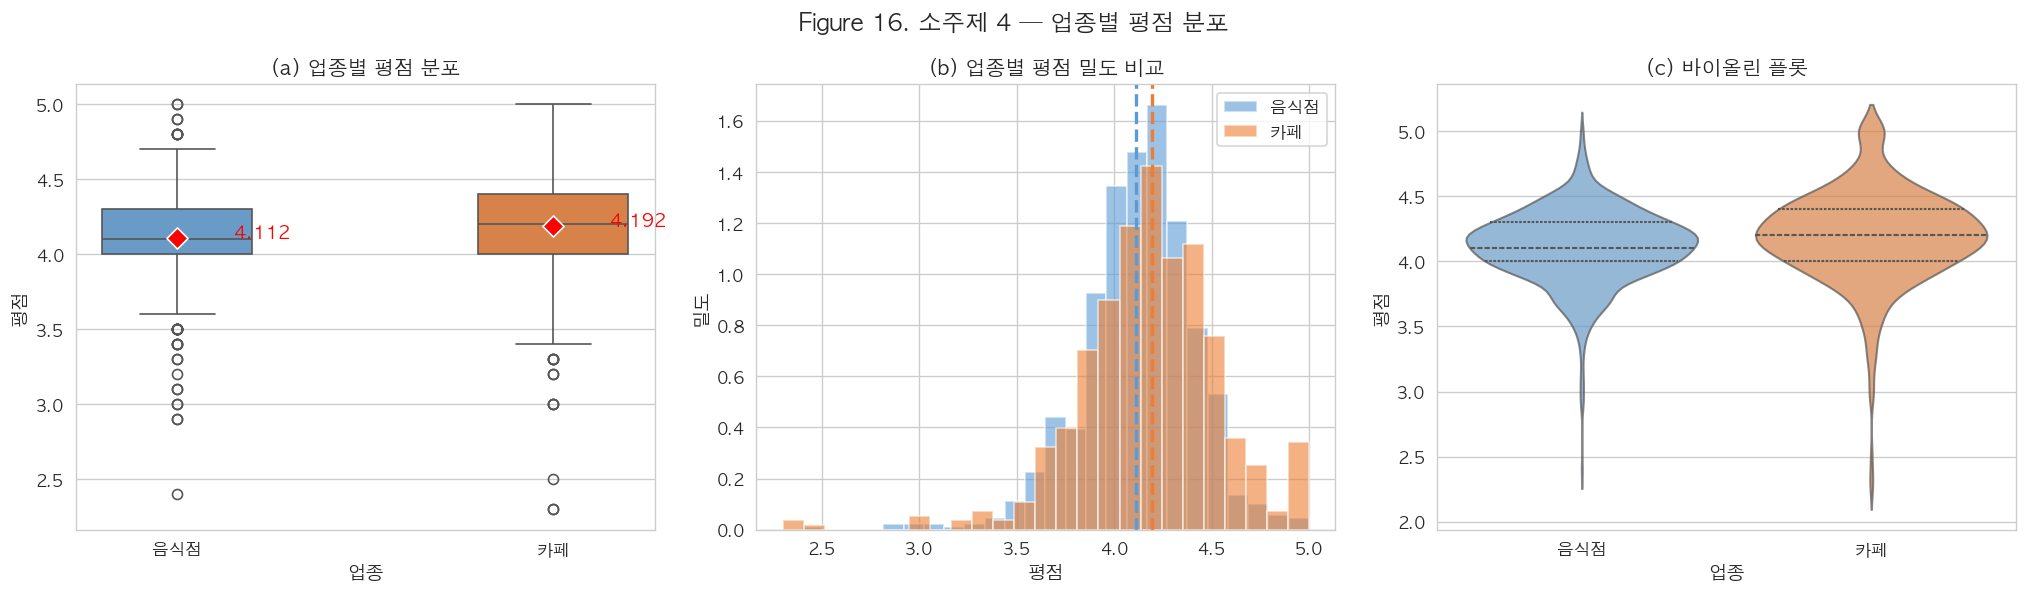

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors_bt = ["#5B9BD5", "#ED7D31"]
 
# (a) 박스플롯
sns.boxplot(data=df, x="business_type", y="rating", palette=colors_bt, ax=axes[0], width=0.4)
for i, bt in enumerate(["음식점", "카페"]):
    mean_val = df[df["business_type"]==bt]["rating"].mean()
    axes[0].scatter(i, mean_val, color="red", s=80, zorder=5, marker="D", edgecolors="white")
    axes[0].text(i + 0.15, mean_val, f"{mean_val:.3f}", color="red", fontsize=11, fontweight="bold")
axes[0].set_xlabel("업종", fontsize=11)
axes[0].set_ylabel("평점", fontsize=11)
axes[0].set_title("(a) 업종별 평점 분포", fontsize=12)
 
# (b) 겹친 히스토그램
axes[1].hist(rest["rating"], bins=25, alpha=0.6, color=colors_bt[0], label="음식점", density=True, edgecolor="white")
axes[1].hist(cafe["rating"], bins=25, alpha=0.6, color=colors_bt[1], label="카페", density=True, edgecolor="white")
axes[1].axvline(rest["rating"].mean(), color=colors_bt[0], linestyle="--", linewidth=2)
axes[1].axvline(cafe["rating"].mean(), color=colors_bt[1], linestyle="--", linewidth=2)
axes[1].set_xlabel("평점", fontsize=11)
axes[1].set_ylabel("밀도", fontsize=11)
axes[1].set_title("(b) 업종별 평점 밀도 비교", fontsize=12)
axes[1].legend(fontsize=10)
 
# (c) 바이올린 + strip
sns.violinplot(data=df, x="business_type", y="rating", palette=colors_bt, 
               ax=axes[2], inner="quartile", alpha=0.7)
axes[2].set_xlabel("업종", fontsize=11)
axes[2].set_ylabel("평점", fontsize=11)
axes[2].set_title("(c) 바이올린 플롯", fontsize=12)
 
plt.suptitle("Figure 16. 소주제 4 — 업종별 평점 분포", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**해석:**
- **(a)** 카페의 중앙값(4.2)이 음식점(4.1)보다 높고, 박스 위치가 전반적으로 위에 있다.
- **(b)** 음식점은 4.0~4.2에 밀집된 좁은 분포, 카페는 4.0~4.4에 걸친 넓은 분포를 보인다.  
  특히 카페는 4.5 이상의 고평점 비율이 음식점보다 높다.
- **(c)** 바이올린 플롯에서 카페의 분포가 더 넓고, 상단(고평점)으로 더 뻗어있음을 확인할 수 있다.

### 4.3 업종 간 평점 차이 검정

In [97]:
# Mann-Whitney U 검정
stat, p = mannwhitneyu(rest["rating"], cafe["rating"], alternative="two-sided")
n1, n2 = len(rest), len(cafe)
r_effect = 1 - (2 * stat) / (n1 * n2)
 
print("업종 간 평점 차이 검정 (Mann-Whitney U)")
print(f"  H_0: 음식점과 카페의 평점 분포가 동일하다")
print(f"  H_1: 음식점과 카페의 평점 분포가 다르다")
print(f"  alpha = 0.05")
print(f"")
print(f"  U = {stat:.0f}")
print(f"  p-value = {p:.6f}")
print(f"  효과 크기 r = {r_effect:.4f}")
print(f"")
print(f"  결론: p < 0.001 → H₀ 기각.")
print(f"  카페(평균 {cafe['rating'].mean():.3f})의 평점이")
print(f"  음식점(평균 {rest['rating'].mean():.3f})보다 통계적으로 유의하게 높다.")
print(f"")
print(f"  효과 크기 r = {r_effect:.4f}는 {'작은' if abs(r_effect) < 0.3 else '중간'} 수준이다.")
 
# 분산 비교 (Levene)
lev_stat, lev_p = levene(rest["rating"], cafe["rating"])
print(f"\n분산 비교 (Levene)")
print(f"  F = {lev_stat:.4f}, p = {lev_p:.6f}")
print(f"  -> {'분산에 유의한 차이 있음' if lev_p < 0.05 else '분산 차이 없음'}")
if lev_p < 0.05:
    print(f"  -> 카페(sigma={cafe['rating'].std():.3f})의 평점 분산이")
    print(f"    음식점(sigma={rest['rating'].std():.3f})보다 유의하게 크다.")
    print(f"    이는 카페에 대한 평가가 음식점보다 더 양극화되어 있음을 의미한다.")

업종 간 평점 차이 검정 (Mann-Whitney U)
  H_0: 음식점과 카페의 평점 분포가 동일하다
  H_1: 음식점과 카페의 평점 분포가 다르다
  alpha = 0.05

  U = 182701
  p-value = 0.000000
  효과 크기 r = 0.1646

  결론: p < 0.001 → H₀ 기각.
  카페(평균 4.192)의 평점이
  음식점(평균 4.112)보다 통계적으로 유의하게 높다.

  효과 크기 r = 0.1646는 작은 수준이다.

분산 비교 (Levene)
  F = 14.0364, p = 0.000187
  -> 분산에 유의한 차이 있음
  -> 카페(sigma=0.358)의 평점 분산이
    음식점(sigma=0.282)보다 유의하게 크다.
    이는 카페에 대한 평가가 음식점보다 더 양극화되어 있음을 의미한다.


### 4.4 업종별 리뷰 수 - 평점 관계 비교

리뷰 수가 평점에 미치는 영향이 업종에 따라 다른지 확인한다.

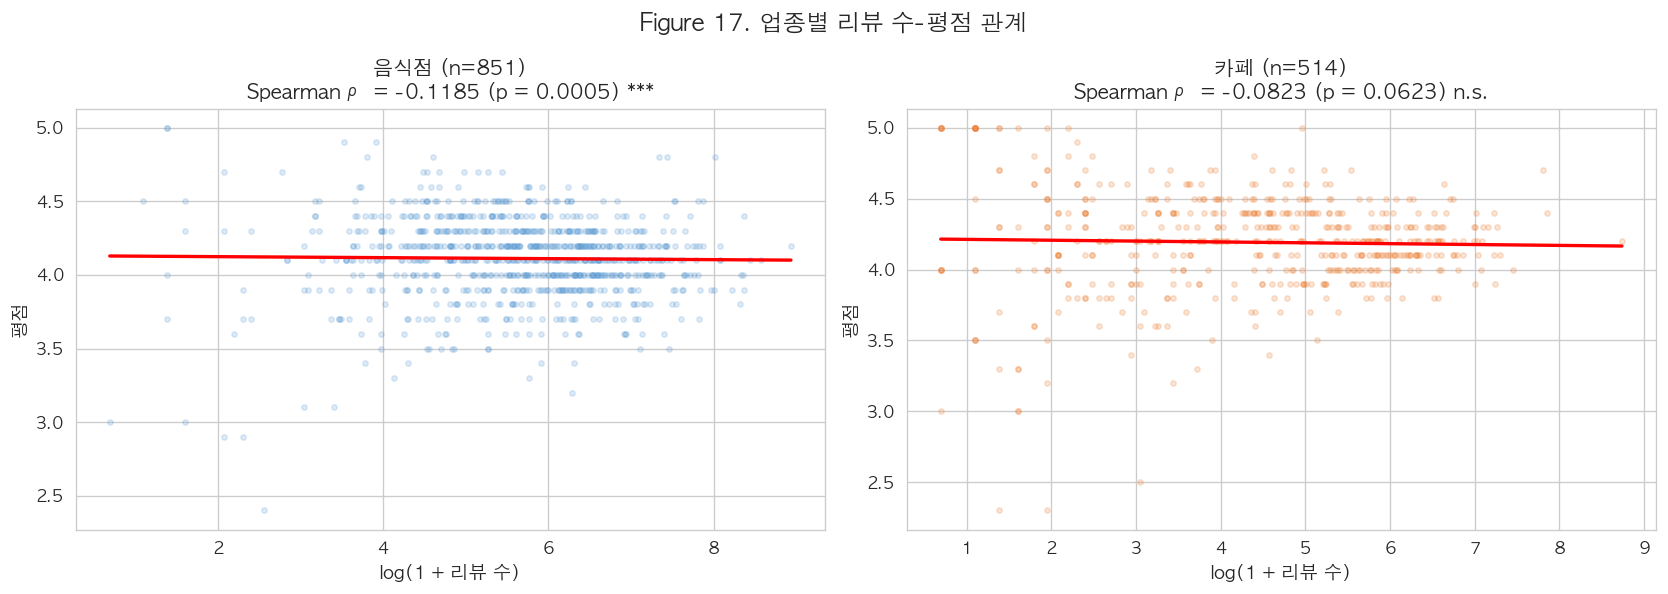

업종별 리뷰 수-평점 Spearman 상관
  음식점: ρ = -0.1185, p = 0.000532 ***
  카페: ρ = -0.0823, p = 0.062309 n.s.

해석:
  음식점: ρ = -0.119 (유의) → 리뷰 많을수록 평점 약간 하락
  카페:   ρ = -0.082 (유의하지 않음) → 리뷰 수와 평점 관련 약함
  → 음식점에서 리뷰 축적 효과(평점 하락)가 카페보다 더 뚜렷하다.
     이는 음식점이 더 다양한 고객층(관광객 포함)으로부터
     리뷰를 받아 평점이 '평균으로 회귀'하는 경향이 강하기 때문일 수 있다.


In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for i, (bt, color, sub) in enumerate(zip(["음식점", "카페"], colors_bt, [rest, cafe])):
    r_sp, p_sp = spearmanr(sub["log_review_count"], sub["rating"])
    
    axes[i].scatter(sub["log_review_count"], sub["rating"], alpha=0.2, s=10, color=color)
    
    # 추세선
    z = np.polyfit(sub["log_review_count"], sub["rating"], 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(sub["log_review_count"].min(), sub["log_review_count"].max(), 100)
    axes[i].plot(x_line, p_line(x_line), color="red", linewidth=2)
    
    axes[i].set_xlabel("log(1 + 리뷰 수)", fontsize=11)
    axes[i].set_ylabel("평점", fontsize=11)
    sig = "***" if p_sp < 0.001 else ("*" if p_sp < 0.05 else "n.s.")
    axes[i].set_title(f"{bt} (n={len(sub)})\nSpearman ρ = {r_sp:.4f} (p = {p_sp:.4f}) {sig}", fontsize=12)
 
plt.suptitle("Figure 17. 업종별 리뷰 수-평점 관계", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
 
# 수치 비교
print("업종별 리뷰 수-평점 Spearman 상관")
for bt, sub in [("음식점", rest), ("카페", cafe)]:
    r_sp, p_sp = spearmanr(sub["log_review_count"], sub["rating"])
    sig = "***" if p_sp < 0.001 else ("*" if p_sp < 0.05 else "n.s.")
    print(f"  {bt}: ρ = {r_sp:.4f}, p = {p_sp:.6f} {sig}")
 
print(f"\n해석:")
print(f"  음식점: ρ = -0.119 (유의) → 리뷰 많을수록 평점 약간 하락")
print(f"  카페:   ρ = -0.082 (유의하지 않음) → 리뷰 수와 평점 관련 약함")
print(f"  → 음식점에서 리뷰 축적 효과(평점 하락)가 카페보다 더 뚜렷하다.")
print(f"     이는 음식점이 더 다양한 고객층(관광객 포함)으로부터")
print(f"     리뷰를 받아 평점이 '평균으로 회귀'하는 경향이 강하기 때문일 수 있다.")

### 4.5 업종별 가격대 - 평점 관계 비교(교호작용)

가격대가 평점에 미치는 영향이 업종에 따라 다른지(교호작용) 확인한다.

In [82]:
# 업종 × 가격대 교차 기술통계
cross_stats = df.groupby(["business_type", "price_category"])["rating"].agg(
    ["count", "mean", "std"]
).round(3)
cross_stats.columns = ["n", "평균", "표준편차"]
 
print("Table 7. 업종 × 가격대별 평점")
print(cross_stats.to_string())
 
# 업종별 가격대 효과 검정
print(f"\n업종별 가격대 효과 (Kruskal-Wallis)")
for bt in ["음식점", "카페"]:
    sub = df[df["business_type"] == bt]
    groups = [sub[sub["price_category"]==c]["rating"] for c in ["저가","중가","고가"]]
    H, p = kruskal(*groups)
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
    print(f"  {bt}: H = {H:.4f}, p = {p:.4f} {sig}")

Table 7. 업종 × 가격대별 평점
                                n     평균   표준편차
business_type price_category                   
음식점           고가               48  4.094  0.295
              저가              168  4.157  0.257
              중가              635  4.101  0.287
카페            고가               11  4.273  0.224
              저가              117  4.207  0.511
              중가              386  4.185  0.302

업종별 가격대 효과 (Kruskal-Wallis)
  음식점: H = 7.2073, p = 0.0272 *
  카페: H = 3.1492, p = 0.2071 n.s.


### 4.6 교호작용 시각화

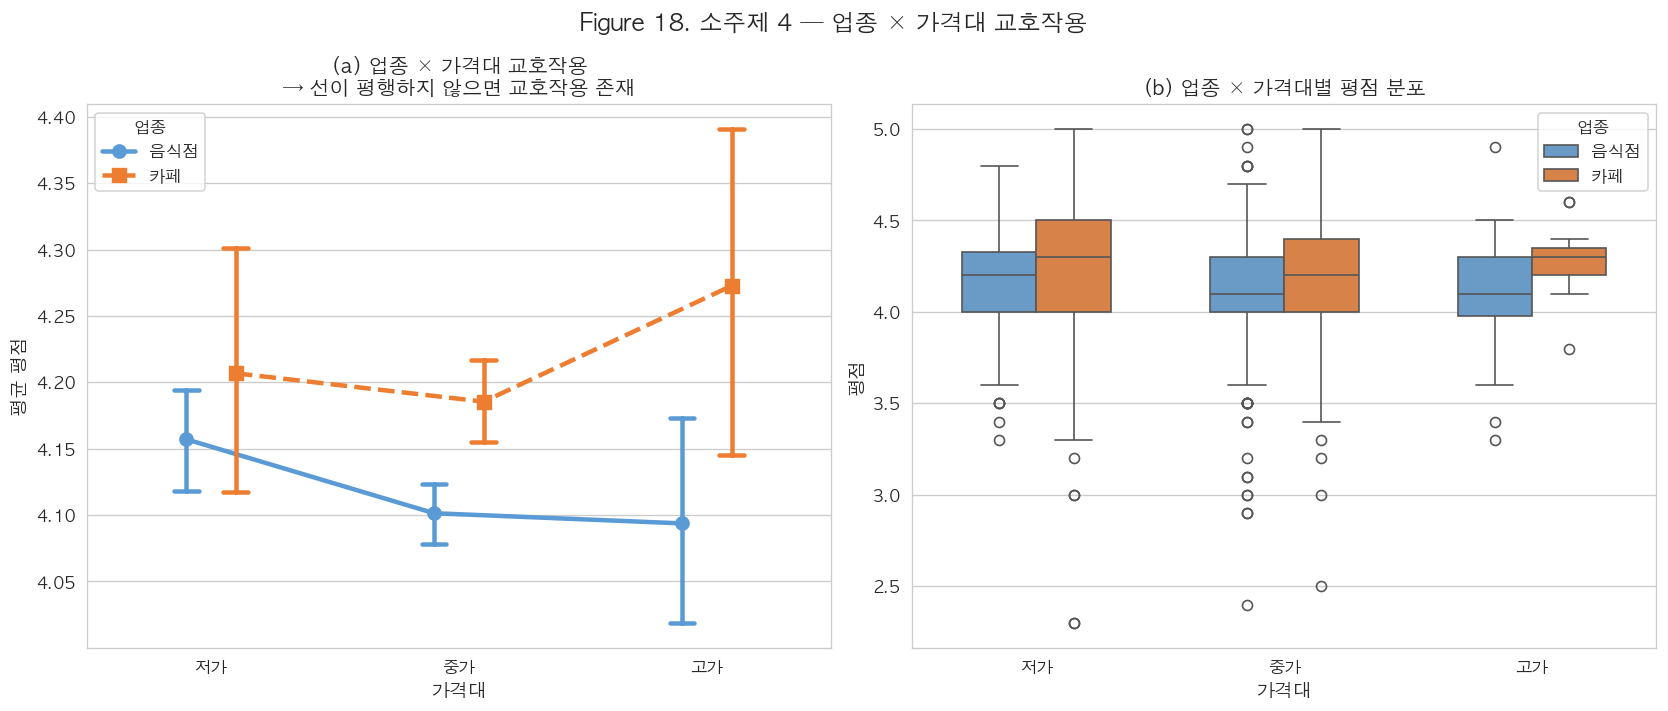

해석:
  음식점: 저가(4.157) > 중가(4.101) ≈ 고가(4.094)
    → 저가 음식점의 평점이 가장 높음 (가성비 효과)
    → 가격대별 유의한 차이 있음 (p = 0.027)

  카페: 고가(4.273) > 저가(4.207) ≈ 중가(4.185)
    → 고가 카페의 평점이 가장 높음 (프리미엄 효과)
    → 가격대별 유의한 차이 없음 (p = 0.207)

  ★ 교호작용 패턴:
    음식점은 '저가가 높은' 패턴 (가성비 선호)
    카페는 '고가가 높은' 패턴 (프리미엄 선호)
    → 소비자의 가격-품질 기대가 업종에 따라 다르다!


In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
price_order = ["저가", "중가", "고가"]
 
# (a) 교호작용 플롯 (Point plot)
sns.pointplot(data=df, x="price_category", y="rating", hue="business_type",
              order=price_order, palette=colors_bt, ax=axes[0],
              dodge=0.2, markers=["o", "s"], linestyles=["-", "--"],
              errorbar="ci", capsize=0.1)
axes[0].set_xlabel("가격대", fontsize=11)
axes[0].set_ylabel("평균 평점", fontsize=11)
axes[0].set_title("(a) 업종 × 가격대 교호작용\n→ 선이 평행하지 않으면 교호작용 존재", fontsize=12)
axes[0].legend(title="업종", fontsize=10)
 
# (b) 업종 × 가격대 박스플롯
sns.boxplot(data=df, x="price_category", y="rating", hue="business_type",
            order=price_order, palette=colors_bt, ax=axes[1], width=0.6)
axes[1].set_xlabel("가격대", fontsize=11)
axes[1].set_ylabel("평점", fontsize=11)
axes[1].set_title("(b) 업종 × 가격대별 평점 분포", fontsize=12)
axes[1].legend(title="업종", fontsize=10)
 
plt.suptitle("Figure 18. 소주제 4 — 업종 × 가격대 교호작용", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
 
print("해석:")
print("  음식점: 저가(4.157) > 중가(4.101) ≈ 고가(4.094)")
print("    → 저가 음식점의 평점이 가장 높음 (가성비 효과)")
print("    → 가격대별 유의한 차이 있음 (p = 0.027)")
print("")
print("  카페: 고가(4.273) > 저가(4.207) ≈ 중가(4.185)")
print("    → 고가 카페의 평점이 가장 높음 (프리미엄 효과)")
print("    → 가격대별 유의한 차이 없음 (p = 0.207)")
print("")
print("  ★ 교호작용 패턴:")
print("    음식점은 '저가가 높은' 패턴 (가성비 선호)")
print("    카페는 '고가가 높은' 패턴 (프리미엄 선호)")
print("    → 소비자의 가격-품질 기대가 업종에 따라 다르다!")

### 4.7 업종별 리뷰 구간-평점 패턴 비교

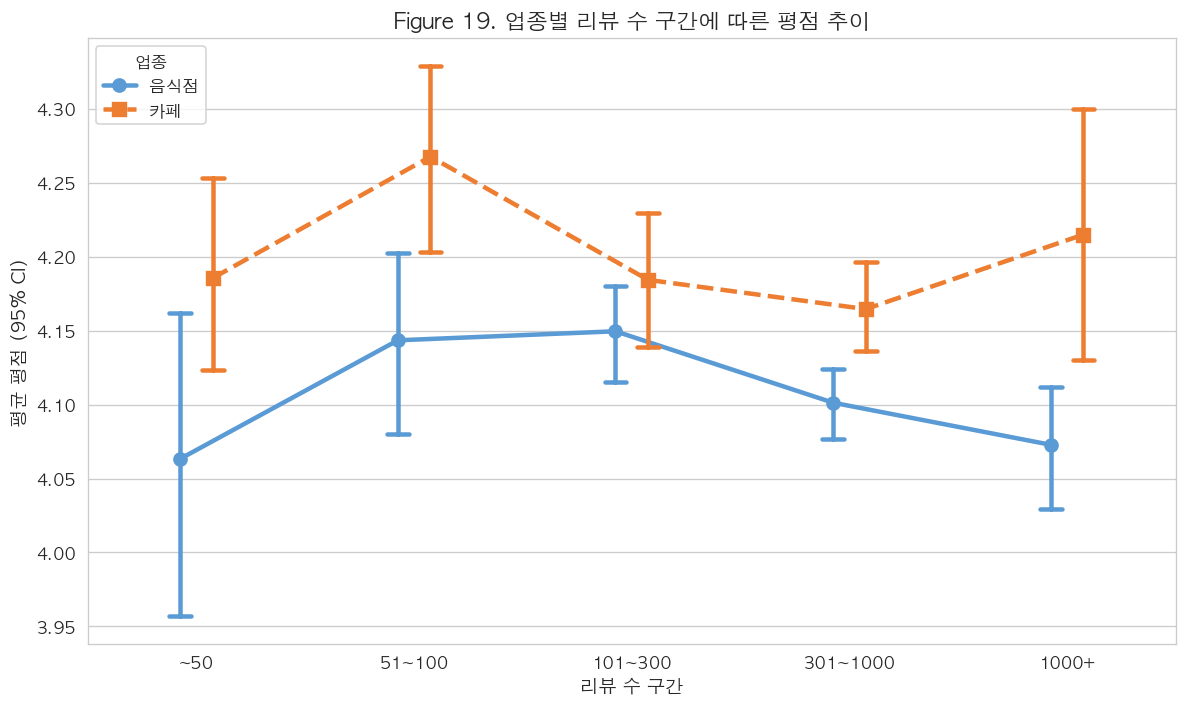

해석:
  두 업종 모두 리뷰 수가 증가하면 평점이 하락하는 추세를 보인다.
  그러나 카페는 모든 리뷰 구간에서 음식점보다 평점이 높으며,
  특히 리뷰가 적은 구간(~50건)에서 카페의 평점이 음식점보다 훨씬 높다.
  리뷰 1000건 이상에서는 두 업종의 평점이 수렴하는 경향이 있다.

  이는 소규모(리뷰 적은) 카페가 특히 높은 평점을 받는 경향이 있음을 시사하며,
  '숨은 카페' 효과 — 단골 중심의 소수 리뷰어가 높은 점수를 주는 현상 — 로 해석할 수 있다.


In [84]:
fig, ax = plt.subplots(figsize=(10, 6))
review_order = ["~50", "51~100", "101~300", "301~1000", "1000+"]
 
sns.pointplot(data=df, x="review_group", y="rating", hue="business_type",
              order=review_order, palette=colors_bt, ax=ax,
              dodge=0.15, markers=["o", "s"], linestyles=["-", "--"],
              errorbar="ci", capsize=0.1)
ax.set_xlabel("리뷰 수 구간", fontsize=11)
ax.set_ylabel("평균 평점 (95% CI)", fontsize=11)
ax.set_title("Figure 19. 업종별 리뷰 수 구간에 따른 평점 추이", fontsize=13, fontweight="bold")
ax.legend(title="업종", fontsize=10)
plt.tight_layout()
plt.show()
 
print("해석:")
print("  두 업종 모두 리뷰 수가 증가하면 평점이 하락하는 추세를 보인다.")
print("  그러나 카페는 모든 리뷰 구간에서 음식점보다 평점이 높으며,")
print("  특히 리뷰가 적은 구간(~50건)에서 카페의 평점이 음식점보다 훨씬 높다.")
print("  리뷰 1000건 이상에서는 두 업종의 평점이 수렴하는 경향이 있다.")
print("")
print("  이는 소규모(리뷰 적은) 카페가 특히 높은 평점을 받는 경향이 있음을 시사하며,")
print("  '숨은 카페' 효과 — 단골 중심의 소수 리뷰어가 높은 점수를 주는 현상 — 로 해석할 수 있다.")

### 4.8 소주제 4 결론

| 항목 | 결과 |
|------|------|
| 업종 간 평점 차이 | Mann-Whitney $p < 0.001$, **카페(4.192) > 음식점(4.112)** |
| 효과 크기 | $r = 0.165$ (작은 효과) |
| 업종 간 분산 차이 | Levene $p < 0.001$, **카페의 평점 분산이 더 크다** |
| 리뷰-평점 관계 | 음식점: $\rho=-0.119$ (유의) / 카페: $\rho=-0.082$ (비유의) |
| 가격대-평점 관계 | 음식점: 저가>중가≈고가 (유의) / 카페: 차이 없음 |
| 교호작용 | **존재함** — 음식점은 가성비, 카페는 프리미엄 패턴 |

**해석:**

1. **카페의 평점이 음식점보다 유의하게 높다.**  
   이는 카페와 음식점의 **평가 기준 차이**에 기인할 수 있다.  
   카페는 분위기·인테리어·음료 품질이 복합적으로 평가되며,  
   이런 요소들은 상대적으로 **일정한 품질**을 유지하기 쉽다.  
   반면 음식점은 맛·양·가격·서비스 등 **다차원적 기준**으로 평가되어  
   부정적 평가를 받을 가능성이 더 높다.

2. **카페의 평점 분산이 더 크다.**  
   카페에 대한 평가가 더 **양극화**되어 있다는 뜻이다.  
   "인스타 감성"에 특화된 카페는 극찬을,  
   그렇지 못한 카페는 혹평을 받는 경향이 있을 수 있다.

3. **가격대-평점 관계가 업종별로 다르다 (교호작용).**  
   음식점에서는 **저가의 평점이 가장 높다** (가성비 효과).  
   소비자는 저렴한 음식점에 대해 기대치가 낮고, 그 기대를 초과하면 높게 평가한다.  
   카페에서는 오히려 **고가의 평점이 높은 경향**이 있다 (프리미엄 효과).  
   이는 고가 카페가 분위기·품질 면에서 확실한 만족을 제공하기 때문으로 해석된다.

4. **리뷰 축적 효과도 업종별로 다르다.**  
   음식점은 리뷰가 많을수록 평점이 유의하게 하락하지만,  
   카페는 그 효과가 약하다. 이는 음식점이 더 다양한 고객층에 노출되어  
   평점이 "평균으로 회귀"하는 반면, 카페는 비교적 일정한 고객층이  
   방문하기 때문일 수 있다.

----

## 소주제 5: 가격, 리뷰 수, 지역, 업종을 종합하면 평점을 얼마나 설명할 수 있으며, 그 한계는 무엇인가?

소주제 1~4에서 개별 요인과 평점의 관계를 확인하였다.  
이제 모든 요인을 **동시에** 투입하는 다중회귀 모델을 구축하고,  
그 **설명력(R²)**, **각 변수의 기여도**, **모델의 한계**를 분석한다.

**모델:**
$$\text{rating}_i = \beta_0 + \beta_1 \cdot \log(\text{review}) + \beta_2 \cdot \text{price} + \beta_3 \cdot \text{업종} + \sum_{k} \gamma_k \cdot \text{district}_k + \epsilon_i$$

### 5.1 모델링 준비

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [86]:
# ── 특성 변수 준비 ──
# 수치형: log_review_count, price_level
# 범주형 → 더미변수: district (기준: 강서구), business_type (기준: 음식점)
X = pd.get_dummies(
    df[["log_review_count", "price_level", "district", "business_type"]],
    columns=["district", "business_type"],
    drop_first=True,
)
y = df["rating"]
 
print(f"독립변수: {X.shape[1]}개")
print(f"  수치형 (2개): log_review_count, price_level")
print(f"  더미변수 (16개): district 15개 (기준: 강서구), business_type 1개 (기준: 음식점)")
print(f"종속변수: rating (n = {len(y)}, 평균 = {y.mean():.3f}, σ = {y.std():.3f})")

독립변수: 18개
  수치형 (2개): log_review_count, price_level
  더미변수 (16개): district 15개 (기준: 강서구), business_type 1개 (기준: 음식점)
종속변수: rating (n = 1365, 평균 = 4.142, σ = 0.315)


### 5.2 다중공선성 진단 (VIF)

회귀 모델에서 독립변수 간 강한 상관이 있으면 계수 추정이 불안정해진다.  
VIF(Variance Inflation Factor)로 이를 진단한다.

$$VIF_j = \frac{1}{1 - R_j^2}$$

일반적으로 VIF > 10이면 심각한 다중공선성을 의미한다.

In [98]:
def calc_vif(X_df):
    """VIF 수동 계산"""
    vif_data = []
    for col in X_df.columns:
        y_temp = X_df[col]
        X_temp = X_df.drop(columns=[col])
        r2 = LinearRegression().fit(X_temp, y_temp).score(X_temp, y_temp)
        vif = 1 / (1 - r2) if r2 < 1 else float("inf")
        vif_data.append({"변수": col, "VIF": round(vif, 2)})
    return pd.DataFrame(vif_data)
 
# 주요 수치형 + 업종 변수
X_vif = df[["log_review_count", "price_level"]].copy()
X_vif["business_type_카페"] = (df["business_type"] == "카페").astype(int)
 
vif_result = calc_vif(X_vif)
print("Table 8. 다중공선성 진단 (VIF)")
print(vif_result.to_string(index=False))
print(f"\n판단: 모든 VIF < 2 -> 다중공선성 문제 없음")

Table 8. 다중공선성 진단 (VIF)
              변수  VIF
log_review_count 1.32
     price_level 1.12
business_type_카페 1.19

판단: 모든 VIF < 2 -> 다중공선성 문제 없음


### 5.3 모델적합

In [99]:
# Train/Test 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"학습: {len(X_train)}개 (80%), 테스트: {len(X_test)}개 (20%)")
 
# 다중회귀 적합
model = LinearRegression()
model.fit(X_train, y_train)
 
# 예측
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
 
# 성능 지표
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
 
print(f"\n다중회귀 모델 성능")
print(f"{'─'*40}")
print(f"  R² (학습):  {r2_train:.4f}")
print(f"  R² (테스트): {r2_test:.4f}")
print(f"  RMSE:       {rmse_test:.4f}")
print(f"  MAE:        {mae_test:.4f}")
print(f"{'─'*40}")
print(f"\n해석:")
print(f"  R^2 = {r2_test:.4f}는 가격, 리뷰 수, 지역, 업종이")
print(f"  평점 변동의 약 {r2_test*100:.1f}%만 설명한다는 의미이다.")
print(f"  나머지 {(1-r2_test)*100:.1f}%는 이 변수들로 설명할 수 없다.")

학습: 1092개 (80%), 테스트: 273개 (20%)

다중회귀 모델 성능
────────────────────────────────────────
  R² (학습):  0.0291
  R² (테스트): 0.0369
  RMSE:       0.3342
  MAE:        0.2403
────────────────────────────────────────

해석:
  R^2 = 0.0369는 가격, 리뷰 수, 지역, 업종이
  평점 변동의 약 3.7%만 설명한다는 의미이다.
  나머지 96.3%는 이 변수들로 설명할 수 없다.


### 5.4 회귀계수 분석

절편 (β₀) = 4.2639

Table 9. 다중회귀 계수 (절대값 순)
              변수     계수(β)     |계수|
     district_동구 -0.192038 0.192038
    district_사상구 -0.173840 0.173840
    district_동래구 -0.127566 0.127566
    district_기장군 -0.114182 0.114182
     district_중구 -0.103284 0.103284
     district_북구 -0.090465 0.090465
   district_부산진구 -0.089154 0.089154
    district_수영구 -0.085895 0.085895
    district_사하구 -0.069027 0.069027
    district_금정구 -0.067089 0.067089
    district_연제구 -0.063768 0.063768
    district_영도구 -0.061666 0.061666
   district_해운대구 -0.054550 0.054550
business_type_카페  0.047649 0.047649
     district_서구 -0.042274 0.042274
     district_남구 -0.037822 0.037822
     price_level -0.020040 0.020040
log_review_count -0.004317 0.004317


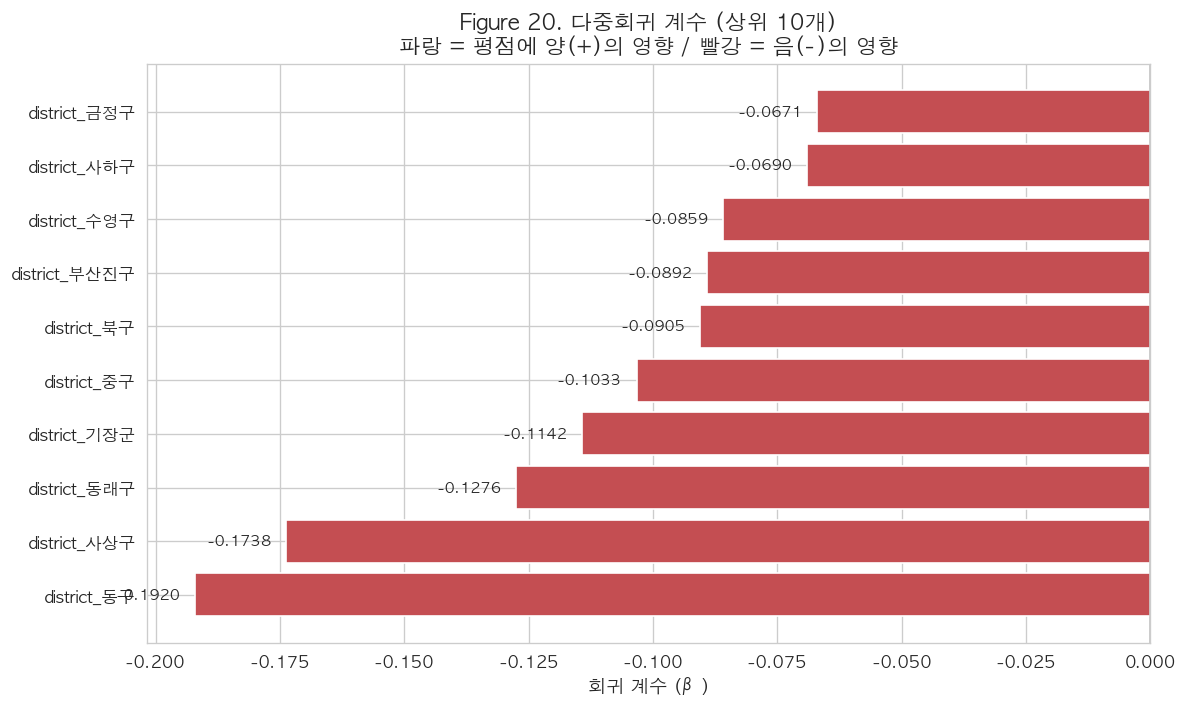

회귀 계수 해석:

  1) log_review_count (β = -0.0043)
     리뷰 수가 증가하면 평점이 소폭 감소하는 경향.
     소주제 2의 결과(리뷰 축적 시 평점의 평균 회귀)와 일치한다.

  2) price_level (β = -0.0200)
     가격대가 1단계 올라갈 때 평점 변화: -0.0200점.
     사실상 무시 가능한 수준 -> 소주제 1(효과 크기 매우 작음)과 일치한다.

  3) business_type_카페 (β = 0.0476)
     다른 변수를 통제한 상태에서도 카페가 음식점보다 약 0.048점 높다.
     소주제 4의 결과(카페 > 음식점)와 일치한다.

  4) district (행정구)
     기준(강서구) 대비 평점이 높은 구: 
     기준(강서구) 대비 평점이 낮은 구: 동래구, 사상구, 동구
     행정구 간 계수 범위: -0.1920 ~ -0.0378
     -> 행정구 효과도 크지 않음. 소주제 3(전체 비교 시 유의하지 않음)과 일치한다.


In [102]:
# 회귀 계수 정리
coef_df = pd.DataFrame({
    "변수": X.columns,
    "계수(β)": model.coef_,
    "|계수|": np.abs(model.coef_),
}).sort_values("|계수|", ascending=False)
 
print(f"절편 (β₀) = {model.intercept_:.4f}")
print(f"\nTable 9. 다중회귀 계수 (절대값 순)")
print(coef_df.to_string(index=False))
 
# %% [markdown]
# ### 5.5 회귀 계수 시각화 + 해석
 
# %%
top_n = 10
top_coefs = coef_df.head(top_n).sort_values("계수(β)")
 
fig, ax = plt.subplots(figsize=(10, 6))
colors_coef = ["#C44E52" if v < 0 else "#5B9BD5" for v in top_coefs["계수(β)"]]
ax.barh(range(len(top_coefs)), top_coefs["계수(β)"].values, color=colors_coef, edgecolor="white")
ax.set_yticks(range(len(top_coefs)))
ax.set_yticklabels(top_coefs["변수"].values)
ax.axvline(0, color="black", linewidth=0.8)
 
for i, v in enumerate(top_coefs["계수(β)"].values):
    offset = 0.003 if v >= 0 else -0.003
    ha = "left" if v >= 0 else "right"
    ax.text(v + offset, i, f"{v:.4f}", va="center", ha=ha, fontsize=9, fontweight="bold")
 
ax.set_xlabel("회귀 계수 (β)", fontsize=11)
ax.set_title("Figure 20. 다중회귀 계수 (상위 10개)\n파랑 = 평점에 양(+)의 영향 / 빨강 = 음(-)의 영향", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
 
# 해석
print("회귀 계수 해석:")
 
lr_coef = coef_df[coef_df["변수"]=="log_review_count"]["계수(β)"].values[0]
print(f"\n  1) log_review_count (β = {lr_coef:.4f})")
print(f"     리뷰 수가 증가하면 평점이 소폭 {'감소' if lr_coef < 0 else '증가'}하는 경향.")
print(f"     소주제 2의 결과(리뷰 축적 시 평점의 평균 회귀)와 일치한다.")
 
pl_coef = coef_df[coef_df["변수"]=="price_level"]["계수(β)"].values[0]
print(f"\n  2) price_level (β = {pl_coef:.4f})")
print(f"     가격대가 1단계 올라갈 때 평점 변화: {pl_coef:.4f}점.")
print(f"     사실상 무시 가능한 수준 -> 소주제 1(효과 크기 매우 작음)과 일치한다.")
 
bt_cols = [c for c in coef_df["변수"] if "business_type" in c]
if bt_cols:
    bt_coef = coef_df[coef_df["변수"]==bt_cols[0]]["계수(β)"].values[0]
    print(f"\n  3) {bt_cols[0]} (β = {bt_coef:.4f})")
    print(f"     다른 변수를 통제한 상태에서도 카페가 음식점보다 약 {bt_coef:.3f}점 높다.")
    print(f"     소주제 4의 결과(카페 > 음식점)와 일치한다.")
 
dist_coefs = coef_df[coef_df["변수"].str.startswith("district_")].sort_values("계수(β)", ascending=False)
print(f"\n  4) district (행정구)")
print(f"     기준(강서구) 대비 평점이 높은 구: {', '.join(dist_coefs[dist_coefs['계수(β)']>0]['변수'].str.replace('district_','').head(3))}")
print(f"     기준(강서구) 대비 평점이 낮은 구: {', '.join(dist_coefs[dist_coefs['계수(β)']<0]['변수'].str.replace('district_','').tail(3))}")
print(f"     행정구 간 계수 범위: {dist_coefs['계수(β)'].min():.4f} ~ {dist_coefs['계수(β)'].max():.4f}")
print(f"     -> 행정구 효과도 크지 않음. 소주제 3(전체 비교 시 유의하지 않음)과 일치한다.")

### 5.6 잔차 진단

다중회귀의 4가지 가정을 잔차를 통해 진단한다:
1. **선형성**: 잔차에 패턴이 없어야 함
2. **정규성**: 잔차가 정규분포를 따라야 함
3. **등분산성**: 잔차의 분산이 일정해야 함
4. **독립성**: 잔차 간 자기상관이 없어야 함

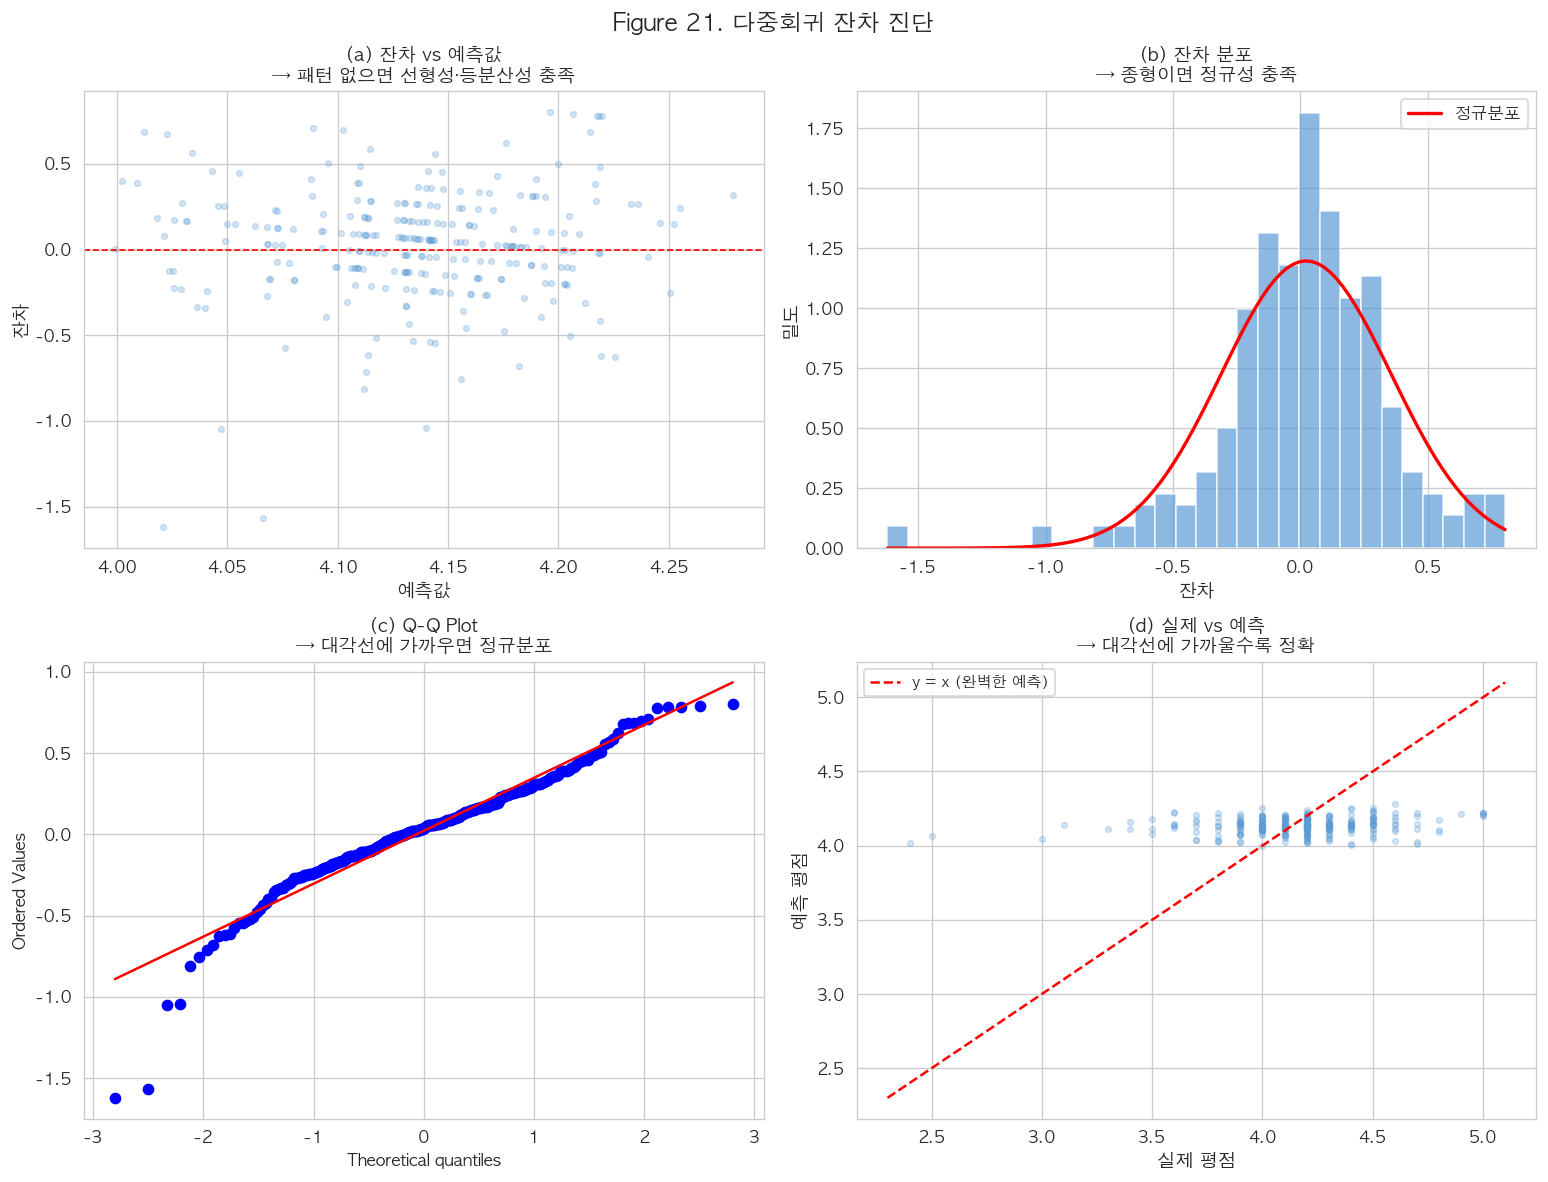

잔차 진단 요약
───────────────────────────────────────────────────────
  잔차 평균:     0.0227 (0에 가까우면 ✓)
  잔차 표준편차:  0.3334
  잔차 왜도:     -0.9485
  Shapiro-Wilk:  W=0.9411, p=0.000000
───────────────────────────────────────────────────────

  (a) 선형성·등분산성: 뚜렷한 패턴 없음 -> 크게 위배되지 않음
      단, 예측값이 4.00~4.28에 밀집
      -> 모델이 대부분 비슷한 값을 예측하고 있다는 뜻
  (b) 정규성: 좌편향 존재, Shapiro p < 0.05 -> 완전한 정규분포는 아님
  (c) Q-Q Plot: 양 끝단 이탈 -> 극단적 평점(2~3점대, 5점)에서 예측 부정확
  (d) 실제 vs 예측: 예측이 좁은 범위에 집중 -> 실제 평점의 다양성 미반영


In [ ]:
residuals = y_test.values - y_pred_test
 
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
 
# (a) 잔차 vs 예측값 → 선형성 + 등분산성
axes[0,0].scatter(y_pred_test, residuals, alpha=0.25, s=12, color="#5B9BD5")
axes[0,0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0,0].set_xlabel("예측값", fontsize=11)
axes[0,0].set_ylabel("잔차", fontsize=11)
axes[0,0].set_title("(a) 잔차 vs 예측값\n→ 패턴 없으면 선형성·등분산성 충족", fontsize=11)
 
# (b) 잔차 히스토그램 → 정규성
axes[0,1].hist(residuals, bins=30, color="#5B9BD5", edgecolor="white", density=True, alpha=0.7)
from scipy.stats import norm
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
axes[0,1].plot(x_norm, norm.pdf(x_norm, residuals.mean(), residuals.std()),
               "r-", linewidth=2, label="정규분포")
axes[0,1].set_xlabel("잔차", fontsize=11)
axes[0,1].set_ylabel("밀도", fontsize=11)
axes[0,1].set_title("(b) 잔차 분포\n→ 종형이면 정규성 충족", fontsize=11)
axes[0,1].legend()
 
# (c) Q-Q Plot → 정규성 정밀 확인
from scipy.stats import probplot
probplot(residuals, dist="norm", plot=axes[1,0])
axes[1,0].set_title("(c) Q-Q Plot\n→ 대각선에 가까우면 정규분포", fontsize=11)
 
# (d) 실제값 vs 예측값
axes[1,1].scatter(y_test, y_pred_test, alpha=0.25, s=12, color="#5B9BD5")
lims = [min(y_test.min(), y_pred_test.min())-0.1, max(y_test.max(), y_pred_test.max())+0.1]
axes[1,1].plot(lims, lims, "r--", linewidth=1.5, label="y = x (완벽한 예측)")
axes[1,1].set_xlabel("실제 평점", fontsize=11)
axes[1,1].set_ylabel("예측 평점", fontsize=11)
axes[1,1].set_title("(d) 실제 vs 예측\n→ 대각선에 가까울수록 정확", fontsize=11)
axes[1,1].legend(fontsize=9)
 
plt.suptitle("Figure 21. 다중회귀 잔차 진단", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
 
# 잔차 통계
from scipy.stats import shapiro
res_sample = residuals[:500] if len(residuals) > 500 else residuals
res_shapiro = shapiro(res_sample)
 
print("잔차 진단 요약")
print(f"{'─'*55}")
print(f"  잔차 평균:     {residuals.mean():.4f} (0에 가까우면 굿)")
print(f"  잔차 표준편차:  {residuals.std():.4f}")
print(f"  잔차 왜도:     {pd.Series(residuals).skew():.4f}")
print(f"  Shapiro-Wilk:  W={res_shapiro[0]:.4f}, p={res_shapiro[1]:.6f}")
print(f"{'─'*55}")
print(f"\n  (a) 선형성·등분산성: 뚜렷한 패턴 없음 -> 크게 위배되지 않음")
print(f"      단, 예측값이 {y_pred_test.min():.2f}~{y_pred_test.max():.2f}에 밀집")
print(f"      -> 모델이 대부분 비슷한 값을 예측하고 있다는 뜻")
print(f"  (b) 정규성: 좌편향 존재, Shapiro p < 0.05 -> 완전한 정규분포는 아님")
print(f"  (c) Q-Q Plot: 양 끝단 이탈 -> 극단적 평점(2~3점대, 5점)에서 예측 부정확")
print(f"  (d) 실제 vs 예측: 예측이 좁은 범위에 집중 -> 실제 평점의 다양성 미반영")

### 5.7 설명력의 한계: 왜 $R^2$가 낮은가?

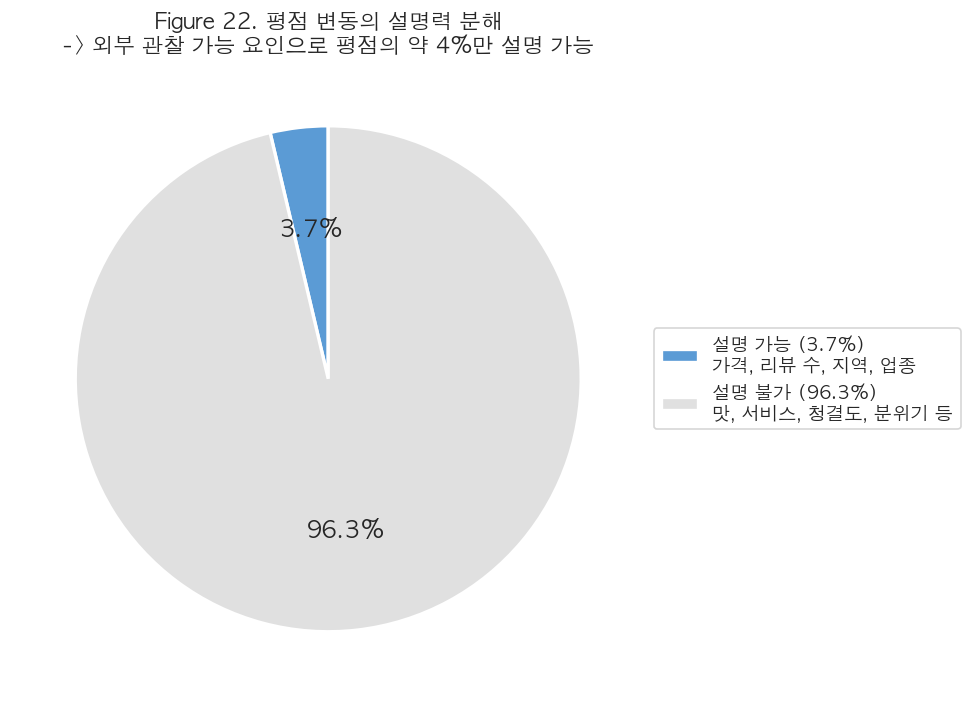

R²가 낮은 이유:

  1) 평점은 '직접 경험'의 결과물이다.
     맛, 서비스, 청결도, 분위기 등 실제 방문 경험이 평점을 결정한다.
     이런 요인은 가격·위치·리뷰 수로 포착할 수 없다.

  2) 평점의 변동 범위가 좁다.
     표준편차 0.315 -> 설명할 변동 자체가 작다.

  3) 소주제 1~4의 개별 효과가 모두 작았다.
     개별 효과가 작으면, 합쳐도 설명력이 낮을 수밖에 없다.

  4) 이 결과 자체가 의미 있는 발견이다.
     '비싸면 맛있다', '해운대가 맛집이 많다' 같은 통념이
     데이터로 지지되지 않음을 실증적으로 보여주었다.


In [101]:
fig, ax = plt.subplots(figsize=(10, 6))
 
explained = r2_test * 100
unexplained = (1 - r2_test) * 100
 
wedges, texts, autotexts = ax.pie(
    [explained, unexplained],
    labels=None,
    autopct="%1.1f%%",
    colors=["#5B9BD5", "#E0E0E0"],
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops=dict(fontsize=14, fontweight="bold"),
)
 
ax.legend(
    [f"설명 가능 ({explained:.1f}%)\n가격, 리뷰 수, 지역, 업종",
     f"설명 불가 ({unexplained:.1f}%)\n맛, 서비스, 청결도, 분위기 등"],
    loc="center left", bbox_to_anchor=(1, 0.5), fontsize=11,
)
 
ax.set_title("Figure 22. 평점 변동의 설명력 분해\n-> 외부 관찰 가능 요인으로 평점의 약 4%만 설명 가능",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
 
print("R²가 낮은 이유:")
print(f"")
print(f"  1) 평점은 '직접 경험'의 결과물이다.")
print(f"     맛, 서비스, 청결도, 분위기 등 실제 방문 경험이 평점을 결정한다.")
print(f"     이런 요인은 가격·위치·리뷰 수로 포착할 수 없다.")
print(f"")
print(f"  2) 평점의 변동 범위가 좁다.")
print(f"     표준편차 {y.std():.3f} -> 설명할 변동 자체가 작다.")
print(f"")
print(f"  3) 소주제 1~4의 개별 효과가 모두 작았다.")
print(f"     개별 효과가 작으면, 합쳐도 설명력이 낮을 수밖에 없다.")
print(f"")
print(f"  4) 이 결과 자체가 의미 있는 발견이다.")
print(f"     '비싸면 맛있다', '해운대가 맛집이 많다' 같은 통념이")
print(f"     데이터로 지지되지 않음을 실증적으로 보여주었다.")

### 5.8 소주제 5 결론

| 항목 | 결과 |
|------|------|
| 모델 | 다중회귀 (OLS) |
| 독립변수 | log_review_count, price_level, district(15), business_type(1) |
| R² (테스트) | **0.037** |
| RMSE | 0.334 |
| VIF | 모두 < 2 (다중공선성 없음) |
| 가장 큰 계수 | business_type_카페 (+), 일부 district |

**종합 해석:**

가격, 리뷰 수, 지역, 업종을 모두 투입한 다중회귀 모델의 R²는 약 **0.037**로,  
이 변수들이 평점 변동의 약 **3.7%만 설명**한다.

이는 모델의 실패가 아니라, **평점의 본질적 특성**을 반영하는 결과이다.  
평점은 가격·위치·인지도 같은 외부 조건이 아니라,  
**맛·서비스·분위기** 같은 직접 경험적 요인에 의해 결정된다.

소비자에게 실질적으로 중요한 것은 "어디에 있는 얼마짜리 가게"가 아니라  
**그 가게가 제공하는 고유한 경험의 품질**이다.

이 결론은 소주제 1~4의 분석 결과(개별 효과 크기가 모두 작았음)와 **일관**되며,  
대주제의 질문 "이러한 요인들의 설명력은 어디까지인가?"에 대한 답이 된다.

------

## **한계점 및 향후 연구:**
- 맛, 서비스, 청결도 등 직접 경험적 변수가 포함되지 않았다.
- Google priceLevel은 상대적 등급이며 실제 메뉴 가격이 아니다.
- 향후 텍스트 리뷰의 감성 분석(Sentiment Analysis)을 추가하면  
  직접 경험적 요인을 간접적으로 포착하여 설명력을 높일 수 있을 것이다.